# Practica B4-T2 - XAI aplicado a concesion de credito

**Notebook UNICO de entrega**, consolidado a partir de los notebooks de trabajo `01_EDA.ipynb` a
`08_otras_tecnicas.ipynb` del repositorio `TAREA_XAI`.

Se entrega junto con los dos ficheros de predicciones de produccion
(`results/predicciones/cs_produccion1.csv` y `cs_produccion2.csv`), tal y como exige el enunciado.

**Indice:**
1. Portada  ·  2. Objetivo y planteamiento  ·  3. Datos y EDA  ·  4. Preprocesado
5. Modelo (coste simetrico)  ·  6. Modelo (coste asimetrico)  ·  7. Tabla comparativa
8. Auditoria: subrogado  ·  9. Auditoria: contrafactuales  ·  10. Auditoria: SHAP (+ cotejo LIME)
11. Otras tecnicas  ·  12. Decisiones de diseno  ·  13. Reflexion final

## 1. Portada

**Master MIAX - Bloque 4 - Practica B4-T2. XAI**

**Componentes del grupo:**
- Oscar Romero Quincoces
- Fernando Dapena Tauste
- Daniel Garcia Lopez

**Fecha de entrega:** 20 de julio de 2026.

**Entregables:**
- Este notebook `99_ENTREGA.ipynb`.
- `results/predicciones/cs_produccion1.csv` -- escenario simetrico C_FP = C_FN = 1.
- `results/predicciones/cs_produccion2.csv` -- escenario asimetrico C_FN = 10*C_FP (conceder a un moroso cuesta 10x denegar a un buen cliente; erratum del enunciado confirmado por el profesor).

## 2. Objetivo y planteamiento del problema

El objetivo es **construir, auditar y optimizar un modelo de concesion de credito** bajo dos
condiciones de coste distintas:

- **Escenario 1 (simetrico):** un falso positivo (denegar a un buen cliente) y un falso negativo
  (conceder a un moroso que luego impaga) cuestan lo mismo: C_FP = C_FN = 1. Predicciones de
  produccion en `cs_produccion1.csv`.
- **Escenario 2 (asimetrico):** conceder a un moroso cuesta **10 veces** mas que denegar a un buen
  cliente: C_FP = 1, C_FN = 10 (erratum del enunciado confirmado por el profesor). Predicciones en
  `cs_produccion2.csv`.

Ademas se audita el modelo con: **modelo subrogado con reglas** (sec. 8), **contrafactuales**
(sec. 9), **SHAP global y local** (sec. 10) y **otras tecnicas** de explicabilidad (sec. 11). El
modelo elegido es **supervisado (XGBoost)**, tras compararlo contra un bandit contextual LinUCB.
La practica se evalua 50 % por resultados (coste medio en produccion) y 50 % por analisis y auditoria.

In [1]:
# === Setup: rutas, imports y helpers compartidos por todo el notebook ===
import os, sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import src.cost_utils as cu

FIG = ROOT / "results" / "figures"
TAB = ROOT / "results" / "tables"
PRED = ROOT / "results" / "predicciones"

def fig(nombre, w=780):
    """Muestra una figura PNG ya generada por los notebooks 01-08."""
    display(Image(filename=str(FIG / nombre), width=w))

def tabla(nombre, **kw):
    """Lee una tabla CSV de results/tables/."""
    return pd.read_csv(TAB / nombre, **kw)

def md(txt):
    display(Markdown(txt))

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 160)
print("setup OK  |  ROOT =", ROOT)

setup OK  |  ROOT = C:\Users\oscar\Downloads\TAREA_XAI


In [2]:
# Matrices de coste de referencia (usadas en las secciones 5-7). Fuente: src/cost_utils.py
C1_FP, C1_FN = cu.COSTES_ESCENARIO_1     # (1, 1)  simetrico
C2_FP, C2_FN = cu.COSTES_ESCENARIO_2     # (1, 10) asimetrico (erratum del enunciado confirmado por el profesor)

print(f"Escenario 1 (simetrico)  C_FP={C1_FP:.0f} C_FN={C1_FN:.0f}  "
      f"umbral analitico C_FP/(C_FP+C_FN) = {cu.umbral_analitico(C1_FP, C1_FN):.4f}")
print(f"Escenario 2 (asimetrico) C_FP={C2_FP:.0f} C_FN={C2_FN:.0f}  "
      f"umbral analitico C_FP/(C_FP+C_FN) = {cu.umbral_analitico(C2_FP, C2_FN):.4f}")
print("\nM[real, pred] escenario 1 (simetrico):\n", cu.matriz_coste(C1_FP, C1_FN))
print("\nM[real, pred] escenario 2 (asimetrico):\n", cu.matriz_coste(C2_FP, C2_FN))

Escenario 1 (simetrico)  C_FP=1 C_FN=1  umbral analitico C_FP/(C_FP+C_FN) = 0.5000
Escenario 2 (asimetrico) C_FP=1 C_FN=10  umbral analitico C_FP/(C_FP+C_FN) = 0.0909

M[real, pred] escenario 1 (simetrico):
 [[0. 1.]
 [1. 0.]]

M[real, pred] escenario 2 (asimetrico):
 [[ 0.  1.]
 [10.  0.]]


## 3. Datos y EDA

Se cargaron y validaron cs_construccion.csv (105000x11, train, con target, 8.81 MB) y cs_produccion.csv (45000x11, sin target, 3.78 MB) contra el diccionario de datos, comparando shapes, dtypes y porcentajes de nulos columna a columna entre ambos conjuntos. Sobre el train se caracterizo el desbalance del target, se detectaron valores centinela de codificacion (96/98 simultaneos en las 3 columnas PastDue) y outliers univariantes y multivariantes (Isolation Forest), se calcularon matrices de correlacion (Pearson y Spearman) y el Factor de Inflacion de Varianza (VIF) por variable, y se cruzo la nulidad de MonthlyIncome y NumberOfDependents con el target, con DebtRatio y con la edad para diagnosticar el mecanismo de ausencia (MNAR) y proponer una estrategia de imputacion. Un analisis de robustez recalculo PCA, t-SNE y KernelPCA excluyendo las filas centinela y los outliers extremos para confirmar si distorsionaban la estructura de los datos.

**Validacion train vs produccion:** mismo esquema en 10 de las 11 columnas (la unica que difiere en dtype es el target, vacio y por tanto float en produccion, lo esperado). Los nulos son muy similares pero NO identicos: MonthlyIncome 19.8048% en train vs 19.8578% en produccion; NumberOfDependents 2.6076% en train vs 2.6356% en produccion.

In [3]:
# === Codigo real de la Seccion 03 (fuente: notebooks/01_EDA.ipynb; ninguno (EDA directo sobre data/cs_construccion.csv)) ===
# Reproduce la SUSTANCIA de las figuras/tablas que la seccion ya muestra, SIN redibujarlas:
#   figuras : 02_balance_target, 05_heatmap_correlacion_pearson, 05_vif_barras,
#             08_tasa_target_por_nulo_monthlyincome, 08_debtratio_boxplot_nulo_monthlyincome
#   tablas  : 03_resumen_centinelas_outliers, 05_vif_multicolinealidad,
#             08_debtratio_por_nulo_monthlyincome, 08_test_estadistico_missingness
# Se recalculan e imprimen los numeros clave; las figuras canonicas ya se muestran via fig(...).

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

RANDOM_STATE = 42
TARGET = "SeriousDlqin2yrs"

# --- Carga del raw de construccion (train con target); mismo fichero que usa el 01_EDA ---
df_train = pd.read_csv(ROOT/"data"/"cs_construccion.csv")
n = len(df_train)
print(f"df_train (cs_construccion.csv): {df_train.shape[0]} filas x {df_train.shape[1]} columnas")

# === (1) Balance del target -> fig 02_balance_target ===
target_counts = df_train[TARGET].value_counts().sort_index()
balance = pd.DataFrame({
    "clase": target_counts.index,
    "n": target_counts.values,
    "pct": (target_counts.values / n * 100).round(4),
})
print("\n[1] Balance del target")
print(balance.to_string(index=False))
print(f"Desbalance severo: clase 0 = {balance.loc[0,'pct']:.4f}%  vs  clase 1 = {balance.loc[1,'pct']:.4f}%")

# === (2) Centinelas y outliers univariantes -> tabla 03_resumen_centinelas_outliers ===
pastdue_cols = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]
mask_98 = (df_train[pastdue_cols] == 98).all(axis=1)      # picos centinela 98 en las 3 columnas
mask_96 = (df_train[pastdue_cols] == 96).all(axis=1)      # picos centinela 96 en las 3 columnas
n_98 = int(mask_98.sum()); n_96 = int(mask_96.sum())
n_age_cero = int((df_train["age"] == 0).sum())
rev = df_train["RevolvingUtilizationOfUnsecuredLines"]
debt = df_train["DebtRatio"]
n_rev_mayor2 = int((rev > 2).sum())
umbral_debt_alto = debt.quantile(0.975)
n_debt_alto = int((debt > umbral_debt_alto).sum())

resumen_centinelas_outliers = pd.DataFrame([
    {"hallazgo": "NumberOfTime*PastDue* == 98 simultaneo en las 3 columnas",
     "n_filas": n_98, "pct_filas": round(n_98 / n * 100, 4),
     "recomendacion": "tratar como centinela/missing (no como 98 incidencias reales)"},
    {"hallazgo": "NumberOfTime*PastDue* == 96 simultaneo en las 3 columnas",
     "n_filas": n_96, "pct_filas": round(n_96 / n * 100, 4),
     "recomendacion": "tratar como centinela/missing (no como 96 incidencias reales)"},
    {"hallazgo": "age == 0 (edad invalida)",
     "n_filas": n_age_cero, "pct_filas": round(n_age_cero / n * 100, 4),
     "recomendacion": "tratar como missing e imputar (p. ej. mediana de age)"},
    {"hallazgo": "RevolvingUtilizationOfUnsecuredLines > 2 (fuera de rango logico de un ratio)",
     "n_filas": n_rev_mayor2, "pct_filas": round(n_rev_mayor2 / n * 100, 4),
     "recomendacion": "outlier: winsorizar/capar o crear flag en 02_preprocesado"},
    {"hallazgo": "DebtRatio > percentil 97.5 con MonthlyIncome nulo o <=1 (posible artefacto de calculo)",
     "n_filas": n_debt_alto, "pct_filas": round(n_debt_alto / n * 100, 4),
     "recomendacion": "outlier/artefacto: tratar junto con la imputacion de MonthlyIncome"},
])
print("\n[2] Centinelas y outliers univariantes/bivariantes")
print(resumen_centinelas_outliers[["hallazgo", "n_filas", "pct_filas"]].to_string(index=False))

# === (3) Pearson intra-bloque PastDue + VIF -> fig 05_heatmap_correlacion_pearson, fig 05_vif_barras, tabla 05_vif_multicolinealidad ===
cols_expl = [c for c in df_train.columns if c != TARGET]
corr_pastdue = df_train[pastdue_cols].corr(method="pearson")   # colinealidad extrema del bloque
pearson_min_pastdue = corr_pastdue.values[~np.eye(3, dtype=bool)].min()
print("\n[3] Correlacion de Pearson intra-bloque PastDue")
print(corr_pastdue.round(4).to_string())
print(f"Pearson minimo fuera de la diagonal en el bloque PastDue: {pearson_min_pastdue:.4f} (~0.9, casi redundantes)")

# VIF: imputacion temporal por mediana + constante (misma logica que 01_EDA)
df_vif = df_train[cols_expl].fillna(df_train[cols_expl].median())
X_vif = sm.add_constant(df_vif)
tabla_vif = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
tabla_vif = tabla_vif[tabla_vif["variable"] != "const"].sort_values("VIF", ascending=False).reset_index(drop=True)
print("\n[3] Factor de Inflacion de Varianza (VIF) por variable explicativa")
print(tabla_vif.to_string(index=False))
vif_pastdue = tabla_vif.set_index("variable").loc[pastdue_cols, "VIF"]
print("Solo las 3 columnas PastDue superan VIF 40 (~92 / ~74 / ~41 por los picos 96/98); "
      f"el resto de variables queda < {tabla_vif[~tabla_vif['variable'].isin(pastdue_cols)]['VIF'].max():.2f}")

# === (4) Missingness informativo de MonthlyIncome ===
mask_mi_nulo = df_train["MonthlyIncome"].isna()

# (4a) Tasa de impago segun nulo -> fig 08_tasa_target_por_nulo_monthlyincome
tasa_target_por_nulo_mi = pd.DataFrame({
    "n_filas": [int(mask_mi_nulo.sum()), int((~mask_mi_nulo).sum())],
    "n_positivos": [int(df_train.loc[mask_mi_nulo, TARGET].sum()),
                    int(df_train.loc[~mask_mi_nulo, TARGET].sum())],
    "tasa_positivos_pct": [df_train.loc[mask_mi_nulo, TARGET].mean() * 100,
                           df_train.loc[~mask_mi_nulo, TARGET].mean() * 100],
}, index=["MonthlyIncome nulo", "MonthlyIncome no nulo"]).round(4)
print("\n[4a] Tasa de impago segun si MonthlyIncome es nulo")
print(tasa_target_por_nulo_mi.to_string())
print("Contraintuitivo: la tasa de impago BAJA cuando MonthlyIncome es nulo "
      f"({tasa_target_por_nulo_mi.loc['MonthlyIncome nulo','tasa_positivos_pct']:.4f}% < "
      f"{tasa_target_por_nulo_mi.loc['MonthlyIncome no nulo','tasa_positivos_pct']:.4f}%)")

# (4b) DebtRatio segun nulo -> fig 08_debtratio_boxplot_nulo_monthlyincome, tabla 08_debtratio_por_nulo_monthlyincome
debt_nulo = df_train.loc[mask_mi_nulo, "DebtRatio"]
debt_no_nulo = df_train.loc[~mask_mi_nulo, "DebtRatio"]
debtratio_por_nulo_mi = pd.DataFrame({
    "mediana": [debt_nulo.median(), debt_no_nulo.median()],
    "media": [debt_nulo.mean(), debt_no_nulo.mean()],
    "p99": [debt_nulo.quantile(0.99), debt_no_nulo.quantile(0.99)],
    "maximo": [debt_nulo.max(), debt_no_nulo.max()],
    "pct_debtratio_mayor_1": [(debt_nulo > 1).mean() * 100, (debt_no_nulo > 1).mean() * 100],
}, index=["MonthlyIncome nulo", "MonthlyIncome no nulo"]).round(4)
print("\n[4b] DebtRatio segun si MonthlyIncome es nulo")
print(debtratio_por_nulo_mi.to_string())
print(f"La mediana de DebtRatio se dispara a {debtratio_por_nulo_mi.loc['MonthlyIncome nulo','mediana']:.1f} "
      f"(vs {debtratio_por_nulo_mi.loc['MonthlyIncome no nulo','mediana']:.4f} con ingreso observado): "
      "cuando falta el ingreso, DebtRatio deja de ser un ratio y pasa a guardar la deuda absoluta (artefacto)")

# (4c) Tests de missingness -> tabla 08_test_estadistico_missingness
mask_nd_nulo = df_train["NumberOfDependents"].isna()
filas_test = []
for nombre, mask in [("MonthlyIncome", mask_mi_nulo), ("NumberOfDependents", mask_nd_nulo)]:
    chi2, p_chi2, _, _ = chi2_contingency(pd.crosstab(mask, df_train[TARGET]))
    z, p_prop = proportions_ztest(
        count=[int(df_train.loc[mask, TARGET].sum()), int(df_train.loc[~mask, TARGET].sum())],
        nobs=[int(mask.sum()), int((~mask).sum())])
    filas_test.append({"variable_nulo": nombre, "chi2": chi2, "p_valor_chi2": p_chi2,
                       "z_stat_proporciones": z, "p_valor_proporciones": p_prop})
tabla_test_missingness = pd.DataFrame(filas_test)
print("\n[4c] Test estadistico de missingness (chi2 y z de proporciones)")
print(tabla_test_missingness.to_string(index=False))
print("p-valores << 0.05 en ambas: la ausencia NO es aleatoria (MNAR) -> justifica flag is_missing + imputacion condicionada")

# --- Cotejo rapido: lo recalculado coincide con las tablas guardadas que muestra la seccion ---
vif_guardado = tabla("05_vif_multicolinealidad.csv").set_index("variable")["VIF"]
max_dif_vif = float((tabla_vif.set_index("variable")["VIF"] - vif_guardado).abs().max())
debt_guardado = tabla("08_debtratio_por_nulo_monthlyincome.csv", index_col=0)["mediana"]
max_dif_debt = float((debtratio_por_nulo_mi["mediana"] - debt_guardado).abs().max())
print(f"\n[Cotejo] max |VIF recalc - VIF guardado| = {max_dif_vif:.6g} ; "
      f"max |mediana DebtRatio recalc - guardado| = {max_dif_debt:.6g} (ambos ~0)")


df_train (cs_construccion.csv): 105000 filas x 11 columnas

[1] Balance del target
 clase     n     pct
     0 97982 93.3162
     1  7018  6.6838
Desbalance severo: clase 0 = 93.3162%  vs  clase 1 = 6.6838%

[2] Centinelas y outliers univariantes/bivariantes
                                                                              hallazgo  n_filas  pct_filas
                              NumberOfTime*PastDue* == 98 simultaneo en las 3 columnas      185     0.1762
                              NumberOfTime*PastDue* == 96 simultaneo en las 3 columnas        3     0.0029
                                                              age == 0 (edad invalida)        1     0.0010
          RevolvingUtilizationOfUnsecuredLines > 2 (fuera de rango logico de un ratio)      261     0.2486
DebtRatio > percentil 97.5 con MonthlyIncome nulo o <=1 (posible artefacto de calculo)     2625     2.5000

[3] Correlacion de Pearson intra-bloque PastDue
                                      NumberOfTime


[3] Factor de Inflacion de Varianza (VIF) por variable explicativa
                            variable       VIF
NumberOfTime60-89DaysPastDueNotWorse 92.303728
             NumberOfTimes90DaysLate 73.680754
NumberOfTime30-59DaysPastDueNotWorse 41.285570
     NumberOfOpenCreditLinesAndLoans  1.285608
        NumberRealEstateLoansOrLines  1.272430
                                 age  1.085454
                  NumberOfDependents  1.080016
                           DebtRatio  1.020237
                       MonthlyIncome  1.018162
RevolvingUtilizationOfUnsecuredLines  1.000622
Solo las 3 columnas PastDue superan VIF 40 (~92 / ~74 / ~41 por los picos 96/98); el resto de variables queda < 1.29

[4a] Tasa de impago segun si MonthlyIncome es nulo
                       n_filas  n_positivos  tasa_positivos_pct
MonthlyIncome nulo       20795         1142              5.4917
MonthlyIncome no nulo    84205         5876              6.9782
Contraintuitivo: la tasa de impago BAJA cuando Monthly

**Que mirar:** el desbalance del target -93.32% clase 0 (97982 casos) vs 6.68% clase 1 (7018 casos), aproximadamente 1 de cada 15 clientes impaga.

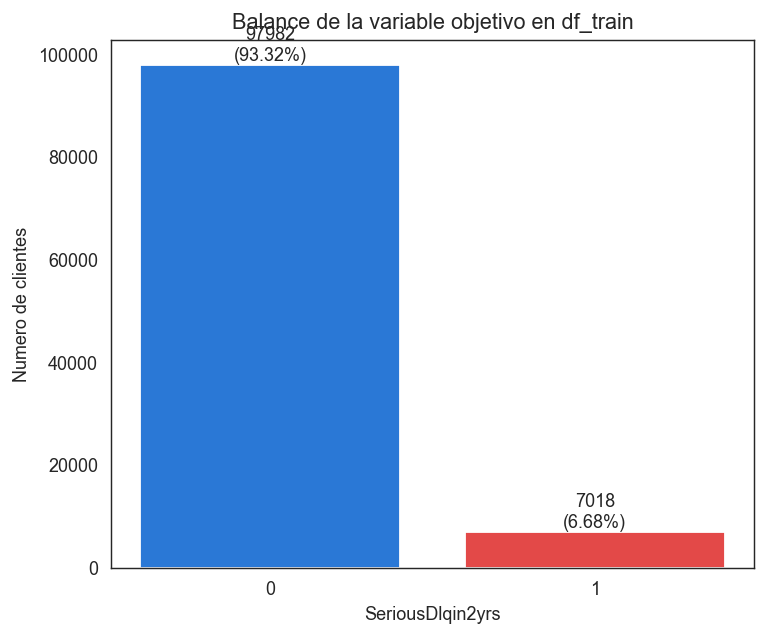

In [4]:
md('**Que mirar:** el desbalance del target -93.32% clase 0 (97982 casos) vs 6.68% clase 1 (7018 casos), aproximadamente 1 de cada 15 clientes impaga.')
fig('02_balance_target.png')

**Que mirar:** la tasa de impago BAJA cuando MonthlyIncome es nulo (5.49%) frente a cuando es conocido (6.98%): el nulo NO delata mayor riesgo, mas bien lo contrario.

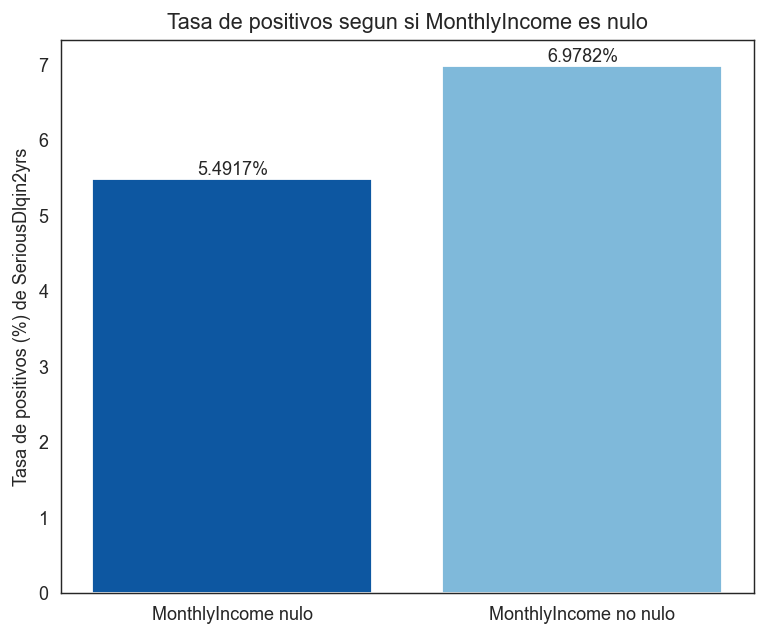

In [5]:
md('**Que mirar:** la tasa de impago BAJA cuando MonthlyIncome es nulo (5.49%) frente a cuando es conocido (6.98%): el nulo NO delata mayor riesgo, mas bien lo contrario.')
fig('08_tasa_target_por_nulo_monthlyincome.png')

**Que mirar:** la mediana de DebtRatio se dispara a 1181.0 cuando MonthlyIncome es nulo frente a 0.2953 cuando es conocido (3999.32x mayor): es el numerador crudo (deuda) sin dividir, no mas riesgo real.

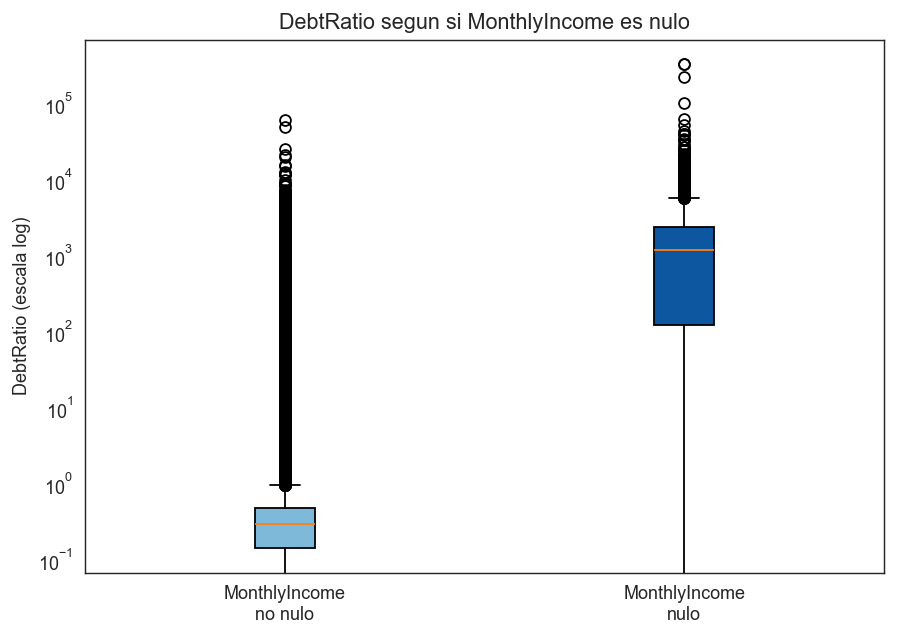

In [6]:
md('**Que mirar:** la mediana de DebtRatio se dispara a 1181.0 cuando MonthlyIncome es nulo frente a 0.2953 cuando es conocido (3999.32x mayor): es el numerador crudo (deuda) sin dividir, no mas riesgo real.')
fig('08_debtratio_boxplot_nulo_monthlyincome.png')

**Que mirar:** el VIF supera 90/70/40 solo en las 3 columnas PastDue; el resto de variables tiene VIF cercano a 1.

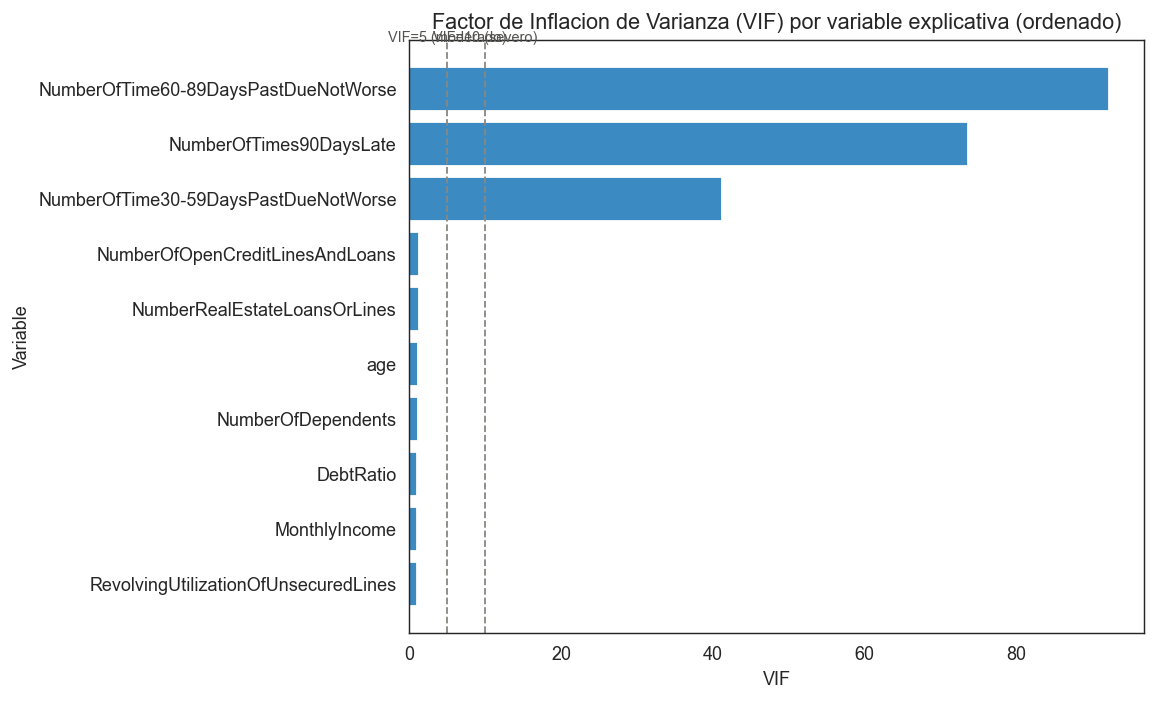

In [7]:
md('**Que mirar:** el VIF supera 90/70/40 solo en las 3 columnas PastDue; el resto de variables tiene VIF cercano a 1.')
fig('05_vif_barras.png')

**Que mirar:** el bloque de las 3 columnas PastDue muestra Pearson ~0.98-0.99 (aparenta colinealidad fuerte), pero su Spearman real cae a 0.25-0.32: el Pearson esta inflado por los centinelas.

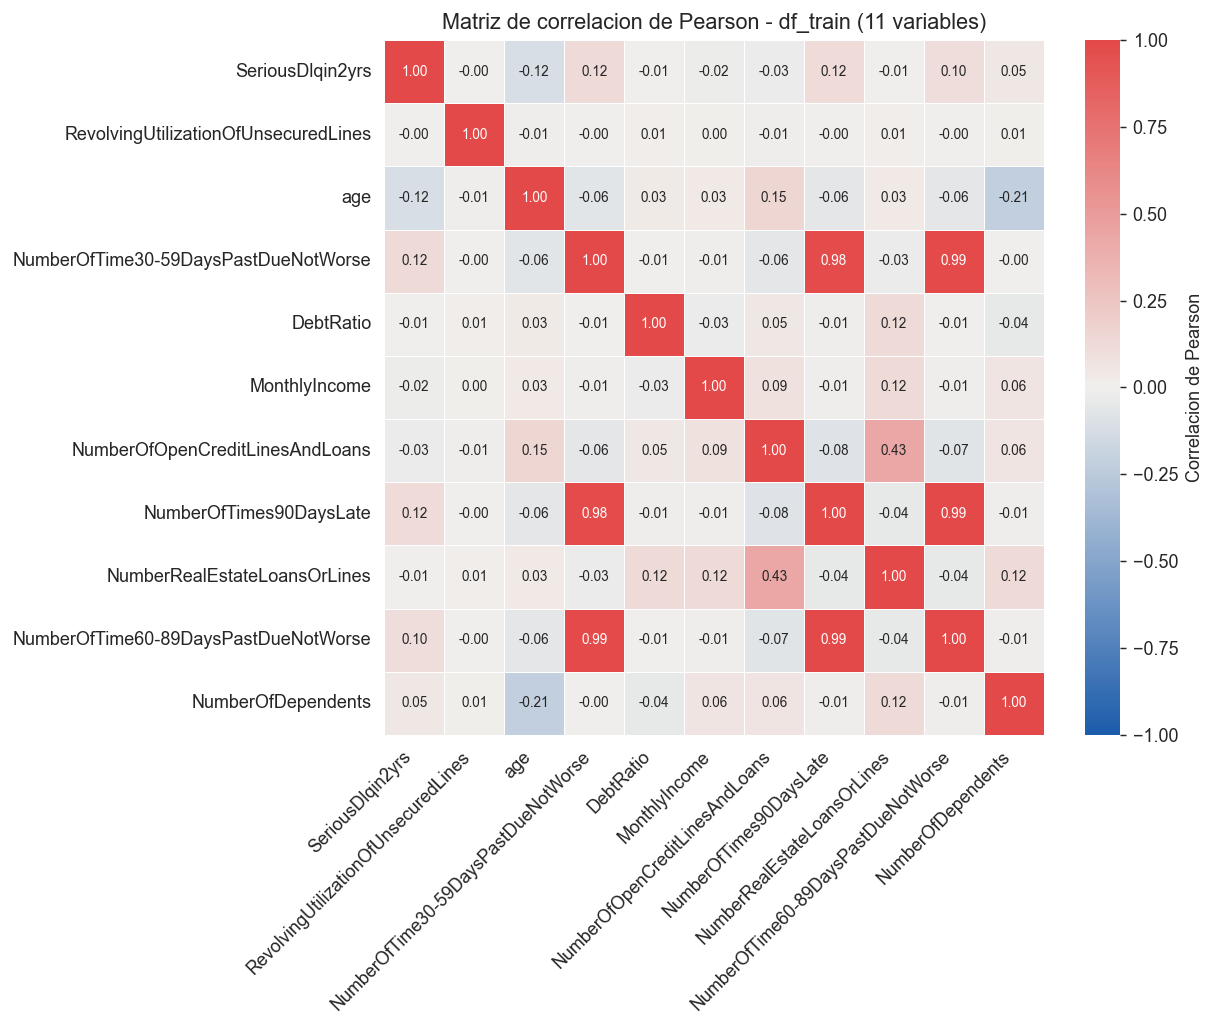

In [8]:
md('**Que mirar:** el bloque de las 3 columnas PastDue muestra Pearson ~0.98-0.99 (aparenta colinealidad fuerte), pero su Spearman real cae a 0.25-0.32: el Pearson esta inflado por los centinelas.')
fig('05_heatmap_correlacion_pearson.png')

In [9]:
df_vif = tabla('05_vif_multicolinealidad.csv')[['variable', 'VIF']]
df_vif['VIF'] = df_vif['VIF'].round(2)
print(df_vif.to_string(index=False))

                            variable   VIF
NumberOfTime60-89DaysPastDueNotWorse 92.30
             NumberOfTimes90DaysLate 73.68
NumberOfTime30-59DaysPastDueNotWorse 41.29
     NumberOfOpenCreditLinesAndLoans  1.29
        NumberRealEstateLoansOrLines  1.27
                                 age  1.09
                  NumberOfDependents  1.08
                           DebtRatio  1.02
                       MonthlyIncome  1.02
RevolvingUtilizationOfUnsecuredLines  1.00


In [10]:
df_cent = tabla('03_resumen_centinelas_outliers.csv')[['hallazgo', 'n_filas', 'pct_filas']]
print(df_cent.to_string(index=False))

                                                                              hallazgo  n_filas  pct_filas
                              NumberOfTime*PastDue* == 98 simultaneo en las 3 columnas      185     0.1762
                              NumberOfTime*PastDue* == 96 simultaneo en las 3 columnas        3     0.0029
                                                              age == 0 (edad invalida)        1     0.0010
          RevolvingUtilizationOfUnsecuredLines > 2 (fuera de rango logico de un ratio)      261     0.2486
DebtRatio > percentil 97.5 con MonthlyIncome nulo o <=1 (posible artefacto de calculo)     2625     2.5000


**Hallazgos:**

- Desbalance manejable (~1 de cada 15 clientes en clase 1): 93.3162% clase 0 (97982) vs 6.6838% clase 1 (7018).
- Esquema y nulos casi identicos entre train y produccion, con una unica diferencia esperada (dtype del target, vacio en produccion): MonthlyIncome 19.8048% (train) vs 19.8578% (produccion), NumberOfDependents 2.6076% vs 2.6356% -parecidos, no identicos.
- DebtRatio guarda el numerador crudo (deuda) sin dividir cuando falta MonthlyIncome: mediana 1181.0 vs 0.2953 con ingreso conocido (3999.32x mayor), y 93.912% de esas filas tiene DebtRatio>1 frente a solo 6.0151% en el resto: es un artefacto de calculo, no variabilidad real.
- Contraintuitivo: el nulo de MonthlyIncome NO marca mayor riesgo -tasa de impago 5.4917% (nulo) vs 6.9782% (conocido), 1.4865pp menos-, aunque la diferencia es sistematica (no aleatoria): mejor preservarla con una variable indicadora que imputar y borrar la senal.
- El nulo de NumberOfDependents (2738 filas, 2.6076%) es subconjunto exacto (100%) del nulo de MonthlyIncome; ese subgrupo es mas mayor (edad mediana 61 vs 52 anios) y con menor tasa de impago (4.6749% vs 6.7376%): ambos nulos comparten un mismo mecanismo de ausencia no aleatorio (MNAR), compatible con clientes mayores con menos datos financieros registrados.
- VIF severo (>10) solo en las 3 columnas PastDue (92.30 / 73.68 / 41.29) esta inflado por 188 filas centinela (96 o 98 simultaneo en las 3 columnas, 0.1790% del dataset) con tasa de impago 54.26% -8x el 6.60% del resto-: el Spearman real cae a 0.25-0.32, muy por debajo del Pearson ~0.98-0.99.
- Un analisis de robustez (PCA, t-SNE y KernelPCA recalculados sin los centinelas ni los outliers extremos) confirma que la separacion entre clases no mejora al quitarlos: el efecto de los centinelas es sobre las metricas de correlacion/VIF, no sobre la estructura real de los datos.
- Recomendacion de imputacion: MonthlyIncome por mediana condicionada al tramo de edad (2800.0 en <=30 anios a 6307.0 en 51-60, frente a 5400.0 de mediana global) mas variable indicadora de ausencia; NumberOfDependents por moda/mediana global (0) con su propia variable indicadora.

## 4. Preprocesado

Split 80/20 estratificado (random_state=42) ANTES de aprender ningun parametro: train queda con 84000 filas y test con 21000, con tasas de clase positiva casi identicas (6.6833% vs 6.6857%, a 0.0024 puntos de distancia del 6.6838% global). Todo lo que sigue -imputacion, recalculo, winsorizado, escalado- se ajusta solo con las 84000 filas de train. Orden real de imputacion sobre train: se limpia age (1 fila con age==0), se tratan como missing los centinelas 96/98 de las 3 columnas PastDue (149 filas, 0.1774%), se imputa MonthlyIncome por la mediana del tramo de edad excluyendo las filas de ingreso no usable, y se imputa NumberOfDependents por su moda (0). El hallazgo central del preprocesado: el CSV guardaba el NUMERADOR crudo de deuda (no el ratio) cuando el ingreso no era usable; dividir por el income ya imputado corrige DebtRatio. Cierra el pipeline un winsorizado + log1p + StandardScaler encapsulados en una clase PreprocesadorCredito que se ajusta (fit) una unica vez en train y se aplica identica a test y produccion, certificada por una bateria de 9 asserts (A-I). El desbalance de clases (6.68%) NO se trata aqui: se deja para la fase de modelado via class_weight o umbral por coste, porque remuestrear antes del split seria fuga.

In [11]:
# === Codigo real de la Seccion 04 (fuente: notebooks/02_preprocesado.ipynb;
#     src/preprocessing.py (clase PreprocesadorCredito)) ===
# Reutiliza el pipeline fiteado y el raw con target; NO reentrena nada pesado.
# Reproduce la SUSTANCIA: split -> income_no_usable -> recalculo DebtRatio (KS) ->
# imputacion por tramo -> winsor p99 -> colapso del VIF de las PastDue -> auditoria de fuga.
# Las figuras canonicas (F1/F2/F3/F4) ya se muestran arriba con fig(...); aqui solo se
# CALCULAN e imprimen los numeros que las respaldan. RANDOM_STATE = 42.
import joblib
from scipy.stats import ks_2samp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from src.preprocessing import PreprocesadorCredito, dividir_train_test

RANDOM_STATE = 42
FEATURES = PreprocesadorCredito.COLUMNAS_FEATURES
TARGET = PreprocesadorCredito.TARGET
FLAGS = PreprocesadorCredito.FLAGS
COLS_PASTDUE = PreprocesadorCredito.COLS_PASTDUE
COLS_LOG = PreprocesadorCredito.COLS_LOG
COLS_WINSOR = PreprocesadorCredito.COLS_WINSOR
BINS_EDAD = PreprocesadorCredito.BINS_EDAD
UMBRAL = PreprocesadorCredito.UMBRAL_INCOME_NO_USABLE
CENTINELA = PreprocesadorCredito.VALORES_CENTINELA

# --- Artefactos: raw train con target + pipeline canonico ya fiteado (SOLO en train) ---
df_full = pd.read_csv(ROOT/"data"/"cs_construccion.csv")
pipe = joblib.load(ROOT/"results"/"models"/"preprocessing_pipeline.joblib")

# --- 1. Split estratificado por target: PRIMERO, antes de aprender nada ---
df_train, df_test = dividir_train_test(df_full, test_size=0.2, random_state=RANDOM_STATE)
n_tr, n_te = len(df_train), len(df_test)
split_resumen = pd.DataFrame({
    "n_filas": [n_tr, n_te, n_tr + n_te],
    "n_positivos": [int(df_train[TARGET].sum()), int(df_test[TARGET].sum()),
                    int(df_full[TARGET].sum())],
    "tasa_clase_1": [df_train[TARGET].mean(), df_test[TARGET].mean(), df_full[TARGET].mean()],
}, index=["train", "test", "total"])
dif_pp = abs(df_train[TARGET].mean() - df_test[TARGET].mean()) * 100
print("=== 1. Split estratificado train/test ===")
print(split_resumen.to_string())
print(f"diferencia de tasa train vs test: {dif_pp:.6f} pp (estratificado -> casi 0)\n")

# --- 2. Flag de missingness sobre el income CRUDO (antes de imputar) ---
# income_no_usable = isna | income<=1 : misma mascara para flag, imputacion y recalculo.
Xtr = df_train[FEATURES].copy().astype("float64")
ytr = df_train[TARGET]
dr_crudo = Xtr["DebtRatio"].copy()                      # DebtRatio original (numerador crudo)
income = Xtr["MonthlyIncome"]
income_no_usable = income.isna() | (income <= UMBRAL)
n_no_usable = int(income_no_usable.sum())
print("=== 2. income_no_usable (numerador de DebtRatio corrupto) ===")
print(f"income_no_usable: {n_no_usable} filas ({income_no_usable.mean()*100:.4f}% de train) "
      f"= {int(income.isna().sum())} nulos + {int((income <= UMBRAL).sum())} con income<=1\n")

# --- 3. Imputacion de income por tramo de edad, con los PARAMETROS del pipe fiteado ---
# (no se reaprende: se reutilizan mediana_age_, medianas_income_por_tramo_ del joblib).
Xtr.loc[(Xtr["age"] == 0) | Xtr["age"].isna(), "age"] = pipe.mediana_age_
n_bins = len(BINS_EDAD) - 1
lut = np.array([pipe.medianas_income_por_tramo_.get(i, pipe.mediana_income_global_)
                for i in range(n_bins)], dtype="float64")
codigos = pd.cut(Xtr["age"], bins=BINS_EDAD).cat.codes.to_numpy()
income_imputado = income.copy()
income_imputado.loc[income_no_usable] = lut[codigos][income_no_usable.to_numpy()]
etiquetas = ["<=30", "31-40", "41-50", "51-60", "61-70", ">70"]
print("=== 3. Parametros de imputacion aprendidos SOLO en train (del pipe) ===")
print(f"mediana_age = {pipe.mediana_age_:.1f} ; mediana_income_global = {pipe.mediana_income_global_:.1f}")
print("income por tramo:", {et: pipe.medianas_income_por_tramo_.get(i, pipe.mediana_income_global_)
                            for i, et in enumerate(etiquetas)})
print(f"moda_dependents = {pipe.moda_dependents_:.1f} ; medianas_pastdue (tras retirar 96/98) = "
      f"{ {c: pipe.medianas_pastdue_[c] for c in COLS_PASTDUE} }\n")

# --- 4. Recalculo de DebtRatio: en las filas no-usables DebtRatio := crudo / income_imputado.
# Hipotesis: cuando falta el ingreso, DebtRatio quedo con el NUMERADOR sin dividir. KS lo prueba.
dr_no_usable_antes = dr_crudo.loc[income_no_usable].dropna()
dr_usable = dr_crudo.loc[~income_no_usable].dropna()
dr_no_usable_despues = (dr_crudo.loc[income_no_usable] /
                        income_imputado.loc[income_no_usable]).dropna()
ks_antes = float(ks_2samp(dr_no_usable_antes, dr_usable).statistic)
ks_despues = float(ks_2samp(dr_no_usable_despues, dr_usable).statistic)
med_antes = float(dr_no_usable_antes.median())
med_despues = float(dr_no_usable_despues.median())
med_usable = float(dr_usable.median())
print("=== 4. Recalculo de DebtRatio (aportacion analitica central) ===")
print(f"mediana DebtRatio no-usable  ANTES  = {med_antes:.1f}   (numerador sin dividir)")
print(f"mediana DebtRatio no-usable DESPUES = {med_despues:.6f}  (sana usable = {med_usable:.6f})")
print(f"ratio de medianas ANTES/usable = {med_antes/med_usable:.1f}x -> {n_no_usable} filas recalculadas")
print(f"KS de dos muestras (contaminada vs sana): {ks_antes:.6f} -> {ks_despues:.6f}  "
      f"(la forma se normaliza)")
# Cotejo contra el diagnostico serializado en el pipe y contra la tabla canonica.
diag = pipe.diagnostico_debtratio()
print(f"[cotejo pipe.diagnostico_debtratio] ks_antes={diag['ks_antes']:.6f} "
      f"ks_despues={diag['ks_despues']:.6f}\n")

# --- 5. Winsor por columna (caps aprendidos en train tras el recalculo) ---
cap_rev = pipe.limites_winsor_["RevolvingUtilizationOfUnsecuredLines"][1]
cap_dr = pipe.limites_winsor_["DebtRatio"][1]
print("=== 5. Winsor por columna (del pipe) ===")
print(f"Revolving cap p99   = {cap_rev:.6f}  (recorta la cola que aplastaria el escalado)")
print(f"DebtRatio cap p99.9 = {cap_dr:.6f}\n")

# --- 6. Colapso del VIF de las 3 PastDue: era un ARTEFACTO de los centinelas 96/98 ---
def _vif(dfX):
    Xc = add_constant(dfX.astype("float64"), has_constant="add")
    vals = Xc.to_numpy()
    return pd.Series({c: float(variance_inflation_factor(vals, i))
                      for i, c in enumerate(Xc.columns) if c != "const"})

# ANTES: features crudas (96/98 presentes; NaN de income/dependents y age==0 -> mediana solo
# para poder calcular el VIF). DESPUES: features ya tratadas por el pipe (centinela->0,
# imputacion, recalculo, winsor) recuperadas con inverse_transform del parquet + log1p (NO age).
X_vif_antes = df_train[FEATURES].copy().astype("float64")
for _c in ["MonthlyIncome", "NumberOfDependents"]:
    X_vif_antes[_c] = X_vif_antes[_c].fillna(X_vif_antes[_c].median())
X_vif_antes.loc[(X_vif_antes["age"] == 0) | X_vif_antes["age"].isna(), "age"] = \
    X_vif_antes["age"].median()

train_out = pd.read_parquet(ROOT/"data"/"processed"/"train.parquet")
# inverse_transform revierte scale+expm1(COLS_LOG) -> valores post-winsor en escala real (= Xtr).
X_vif_despues = pipe.inverse_transform(train_out[FEATURES].copy())[FEATURES].copy()
for _c in COLS_LOG:
    X_vif_despues[_c] = np.log1p(X_vif_despues[_c])   # StandardScaler es afin -> no altera el VIF
vif_antes = _vif(X_vif_antes)
vif_despues = _vif(X_vif_despues)
vif_tab = pd.DataFrame({"VIF_antes": vif_antes, "VIF_despues": vif_despues}).loc[FEATURES]
print("=== 6. VIF antes/despues (las 3 PastDue colapsan) ===")
print(vif_tab.round(4).to_string())
print("VIF PastDue ANTES : " + ", ".join(f"{vif_antes[c]:.2f}" for c in COLS_PASTDUE))
print("VIF PastDue DESPUES: " + ", ".join(f"{vif_despues[c]:.2f}" for c in COLS_PASTDUE))
print(f"VIF maximo de TODAS las features DESPUES: {float(vif_despues.max()):.4f}\n")

# --- 7. Auditoria de fuga (F4): |media| por feature transformada. fit SOLO en train ->
# train ~1e-16 (cero de maquina); test/prod ~1e-2 (residuo, no se re-centraron). ---
test_out = pd.read_parquet(ROOT/"data"/"processed"/"test.parquet")
prod_out = pd.read_parquet(ROOT/"data"/"processed"/"produccion.parquet")
media_abs_train = float(np.abs(train_out[FEATURES].mean().to_numpy()).max())
media_abs_test = float(np.abs(test_out[FEATURES].mean().to_numpy()).max())
media_abs_prod = float(np.abs(prod_out[FEATURES].mean().to_numpy()).max())
print("=== 7. Auditoria de fuga (medias train vs test/prod) ===")
print(f"|media| max de las features transformadas -> train {media_abs_train:.2e} | "
      f"test {media_abs_test:.6f} | prod {media_abs_prod:.6f}")
print(f"gap de ~{np.log10(media_abs_test/max(media_abs_train,1e-300)):.0f} ordenes de magnitud "
      f"=> el StandardScaler se ajusto SOLO en train (sin fuga)")

# --- Cotejo final contra las tablas canonicas de la seccion (deben cuadrar) ---
t_split = tabla("prep_01_split_resumen.csv", index_col=0)
t_dr = tabla("prep_03_debtratio_recalculo.csv", index_col=0)["valor"]
t_vif = tabla("prep_07_vif_antes_despues.csv", index_col=0)
ok_split = int(t_split.loc["train", "n_filas"]) == n_tr and int(t_split.loc["test", "n_filas"]) == n_te
ok_dr = (abs(t_dr["ks_antes"] - ks_antes) < 1e-6 and abs(t_dr["ks_despues"] - ks_despues) < 1e-6
         and int(t_dr["n_income_no_usable"]) == n_no_usable)
ok_vif = np.allclose(t_vif["VIF_despues"].to_numpy(), vif_despues.loc[FEATURES].to_numpy(), atol=1e-6)
print(f"\n[cotejo tablas canonicas] split={ok_split}  debtratio_KS={ok_dr}  VIF_despues={ok_vif}")


=== 1. Split estratificado train/test ===
       n_filas  n_positivos  tasa_clase_1
train    84000         5614      0.066833
test     21000         1404      0.066857
total   105000         7018      0.066838
diferencia de tasa train vs test: 0.002381 pp (estratificado -> casi 0)

=== 2. income_no_usable (numerador de DebtRatio corrupto) ===
income_no_usable: 17900 filas (21.3095% de train) = 16695 nulos + 1205 con income<=1

=== 3. Parametros de imputacion aprendidos SOLO en train (del pipe) ===
mediana_age = 52.0 ; mediana_income_global = 5460.0
income por tramo: {'<=30': 2959.0, '31-40': 5000.0, '41-50': 6167.0, '51-60': 6400.0, '61-70': 5907.5, '>70': 4526.0}
moda_dependents = 0.0 ; medianas_pastdue (tras retirar 96/98) = {'NumberOfTime30-59DaysPastDueNotWorse': 0.0, 'NumberOfTimes90DaysLate': 0.0, 'NumberOfTime60-89DaysPastDueNotWorse': 0.0}

=== 4. Recalculo de DebtRatio (aportacion analitica central) ===
mediana DebtRatio no-usable  ANTES  = 1152.0   (numerador sin dividir)
med

=== 6. VIF antes/despues (las 3 PastDue colapsan) ===
                                      VIF_antes  VIF_despues
RevolvingUtilizationOfUnsecuredLines     1.0006       1.2498
age                                      1.0844       1.1709
NumberOfTime30-59DaysPastDueNotWorse    40.8977       1.1781
DebtRatio                                1.0240       1.9065
MonthlyIncome                            1.0160       1.5578
NumberOfOpenCreditLinesAndLoans          1.2860       1.4221
NumberOfTimes90DaysLate                 71.6977       1.1494
NumberRealEstateLoansOrLines             1.2755       1.8750
NumberOfTime60-89DaysPastDueNotWorse    89.6394       1.1720
NumberOfDependents                       1.0787       1.1171
VIF PastDue ANTES : 40.90, 71.70, 89.64
VIF PastDue DESPUES: 1.18, 1.15, 1.17
VIF maximo de TODAS las features DESPUES: 1.9065

=== 7. Auditoria de fuga (medias train vs test/prod) ===
|media| max de las features transformadas -> train 6.83e-16 | test 0.021086 | prod 0.01408

In [12]:
df_split = tabla('prep_01_split_resumen.csv', index_col=0)
print(df_split.round(4).to_string())

       n_filas  n_positivos  n_negativos  tasa_clase_1
train    84000         5614        78386        0.0668
test     21000         1404        19596        0.0669
total   105000         7018        97982        0.0668


**Recalculo de DebtRatio.** income_no_usable son 17900 filas (21.3095%): 16695 nulos + 1205 con income<=1; un test chi2 de esos dos subgrupos frente al target da chi2=6.8716, p=0.008758 (son estadisticamente distintos entre si), pero se fusionan en un unico flag is_missing_monthlyincome porque comparten el mismo mecanismo (numerador de deuda corrupto), no la misma tasa de riesgo: es una decision de honestidad metodologica, no un atajo. Mirar en la figura: como la distribucion de DebtRatio en esas filas pasa de dispararse (numerador crudo sin dividir) a solaparse con el rango normal tras dividir por el income ya imputado.

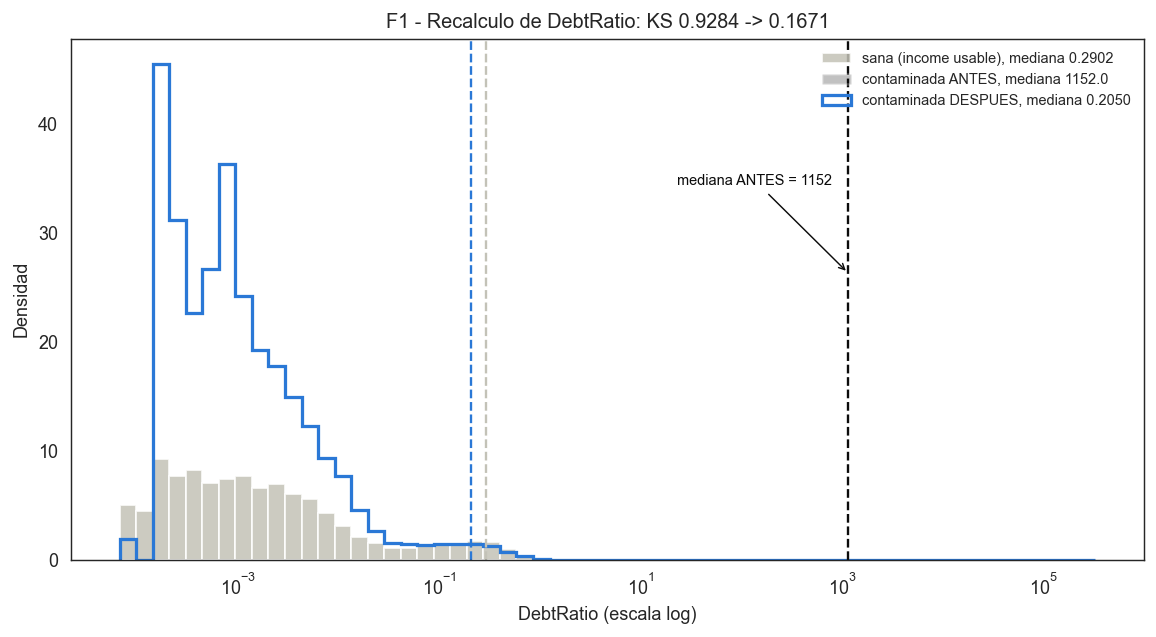

In [13]:
fig('prep_01_debtratio_recalculo_validacion.png')

In [14]:
df_recalc = tabla('prep_03_debtratio_recalculo.csv', index_col=0)
print(df_recalc.round(4).to_string())

                                          valor
metrica                                        
n_income_no_usable                   17900.0000
mediana_DebtRatio_no_usable_ANTES     1152.0000
mediana_DebtRatio_usable                 0.2902
ratio_medianas                        3969.4631
umbral_p97.5_DebtRatio                3538.0250
n_cola_>p97.5                         2100.0000
pct_cola_que_es_income_no_usable       100.0000
mediana_DebtRatio_no_usable_DESPUES      0.2050
ks_antes                                 0.9284
ks_despues                               0.1671
n_filas_recalculadas                 17900.0000


KS de dos muestras (contaminada vs sana) pasa de 0.9284 a 0.1671 tras el recalculo; el AUC univariante de DebtRatio solo frente al target sube de 0.5212 a 0.5531. Mediana DebtRatio no-usable ANTES = 1152.0 vs usable = 0.2902 (ratio ~3970x); el 100% de la cola por encima del percentil 97.5 (2100 filas, umbral 3538.025) era income_no_usable.

**Imputacion de MonthlyIncome.** Se imputa por la mediana del tramo de edad, no por la mediana global: la global habria colapsado las 17900 filas nulas a un unico valor (5460), creando un pico artificial. Mirar en la figura: el gradiente real en forma de U invertida por tramo de edad frente al valor global unico que lo aplanaria.

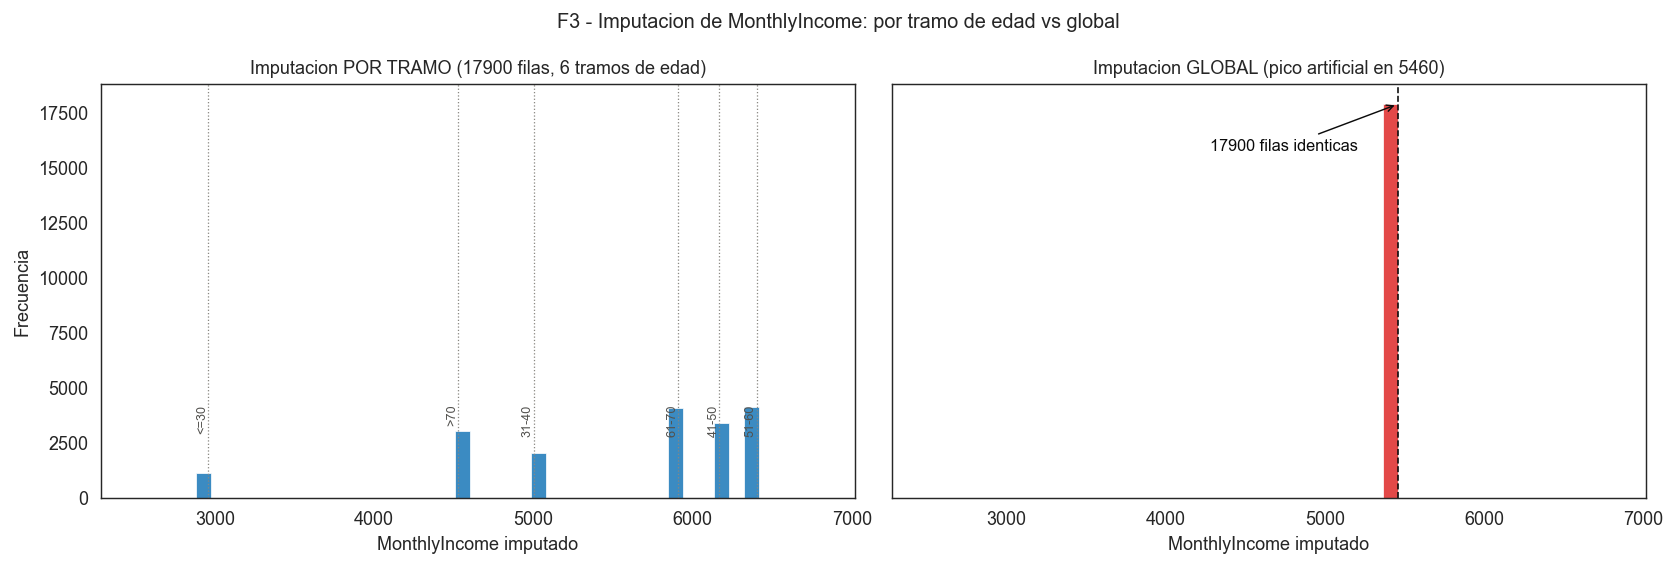

In [15]:
fig('prep_03_imputacion_income_tramo_vs_global.png')

In [16]:
df_imp = tabla('prep_02_imputacion_parametros.csv', index_col=0)
filas_mostrar = [i for i in df_imp.index if 'pastdue' not in i.lower()]
print(df_imp.loc[filas_mostrar].round(4).to_string())

                             valor
parametro                         
mediana_age                   52.0
mediana_income_tramo_<=30   2959.0
mediana_income_tramo_31-40  5000.0
mediana_income_tramo_41-50  6167.0
mediana_income_tramo_51-60  6400.0
mediana_income_tramo_61-70  5907.5
mediana_income_tramo_>70    4526.0
mediana_income_global       5460.0
moda_dependents                0.0


**Winsorizado y escalado.** Revolving se recorta al percentil 99 (cap 1.102904) antes del log1p: el skew crudo (63.10) solo baja a 11.65 con log1p sin recorte (insuficiente); con winsor+log1p cae a 0.72. DebtRatio se recorta al percentil 99.9 (cap 9.184215). age deliberadamente NO lleva log1p: su skew (0.1909) empeoraria a -0.4346 con la transformacion. Skews finales tras el pipeline completo: Revolving 0.717, DebtRatio 2.3282, MonthlyIncome -0.6159, age 0.1909. Mirar en la figura: el histograma de Revolving antes del recorte (cola larga extrema) frente a despues de winsor+log1p+escalado (forma casi simetrica).

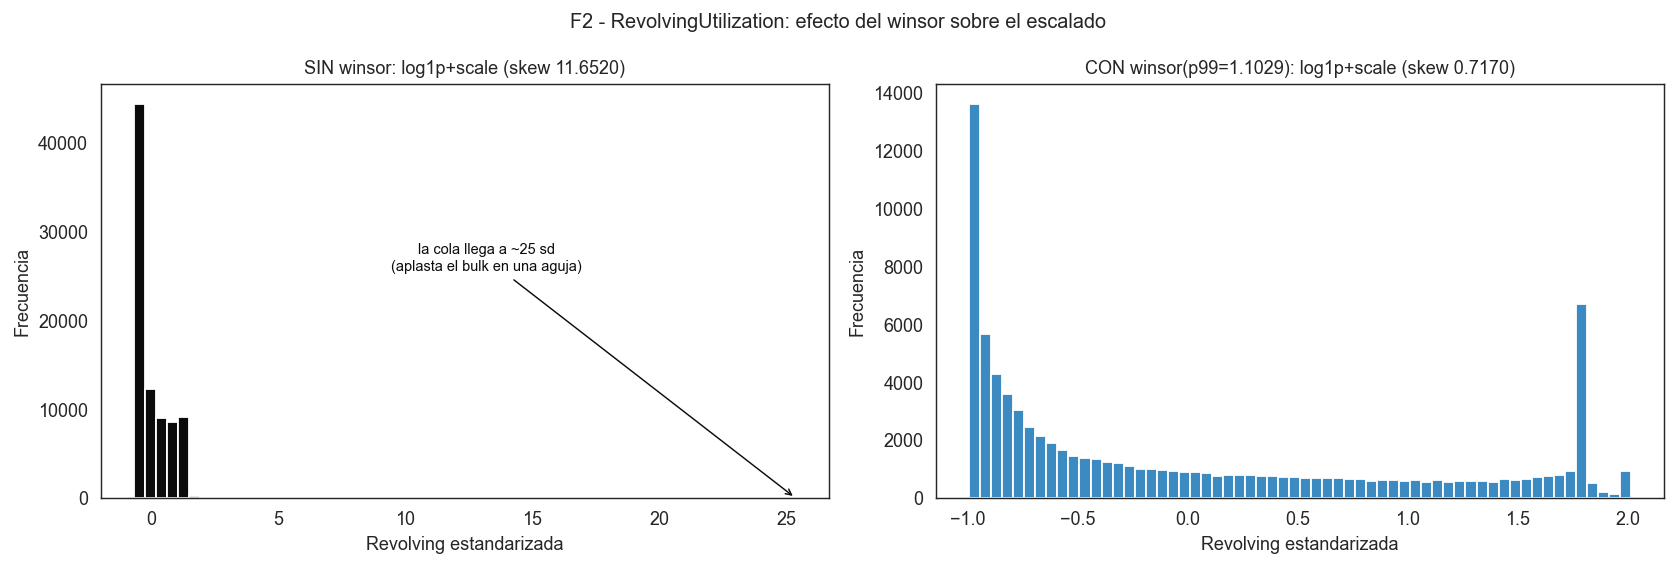

In [17]:
fig('prep_02_revolving_winsor_efecto_escalado.png')

**Multicolinealidad.** El VIF severo de las 3 columnas PastDue detectado antes del preprocesado (40.90 / 71.70 / 89.64) era un artefacto de las 149 filas centinela 96/98, con Pearson maximo entre ellas de 0.9926. Al tratar los centinelas como missing, el VIF colapsa a 1.18 / 1.15 / 1.17 y el Pearson maximo baja a 0.2995: las 3 variables pueden entrar al modelo como features separadas sin consolidar en un indice. VIF maximo de todas las features tras el pipeline = 1.9065 (DebtRatio).

In [18]:
df_vif = tabla('prep_07_vif_antes_despues.csv', index_col=0)
print(df_vif.round(4).to_string())

                                      VIF_antes  VIF_despues
RevolvingUtilizationOfUnsecuredLines     1.0006       1.2498
age                                      1.0844       1.1709
NumberOfTime30-59DaysPastDueNotWorse    40.8977       1.1781
DebtRatio                                1.0240       1.9065
MonthlyIncome                            1.0160       1.5578
NumberOfOpenCreditLinesAndLoans          1.2860       1.4221
NumberOfTimes90DaysLate                 71.6977       1.1494
NumberRealEstateLoansOrLines             1.2755       1.8750
NumberOfTime60-89DaysPastDueNotWorse    89.6394       1.1720
NumberOfDependents                       1.0787       1.1171


**Contrato de salida y verificacion de fuga.** El pipeline entrega train (84000x13), test (21000x13) y produccion (45000x14, con id_fila_original para trazabilidad): 10 features float64 mas 2 flags int8 (is_missing_monthlyincome, es_centinela_pastdue). Una bateria de 9 asserts (A-I) certifica: reproducibilidad exacta del objeto serializado (atol=0), esquema y ausencia de NaN, conteo de filas, apatridia por lote (mismo resultado fila a fila, atol 1e-12), que el fit uso solo train, invarianza a permutacion del orden de filas, robustez a valores de produccion no vistos (p.ej. Revolving=50708 se recorta al cap 1.102904) e idempotencia al releer el objeto guardado en disco. Mirar en la figura: la media absoluta de las features en train queda en ~6.83e-16 (cero de maquina) frente a 0.021086 en test y 0.014083 en produccion -> el fit no vio ni test ni produccion, salto de ~14 ordenes de magnitud respecto a train.

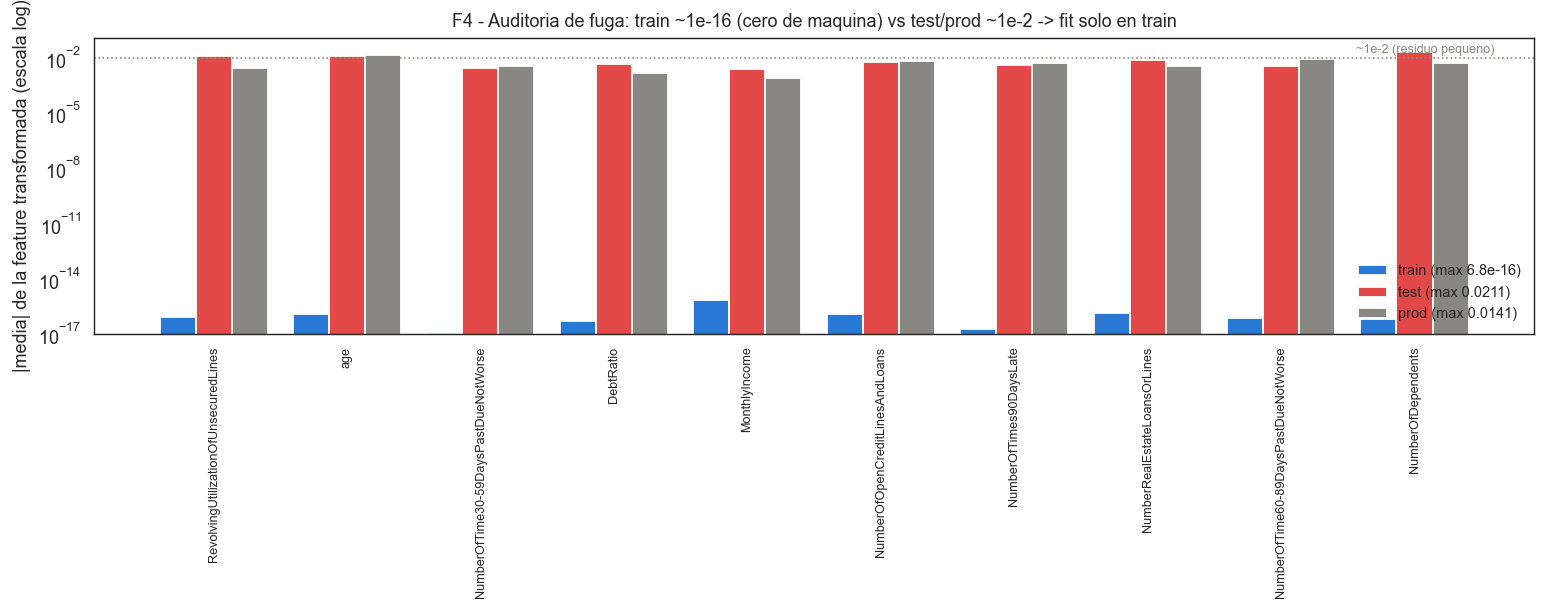

In [19]:
fig('prep_04_auditoria_fuga_medias.png')

**Hallazgos:**

1. Split preserva el desbalance real: 84000 train / 21000 test, tasas de clase positiva 6.6833% vs 6.6857% (0.0024pp de diferencia); el flag es_centinela_pastdue dispara la tasa de target a 53.69% vs 6.60% en el resto (~8x), evidencia de que no es ruido de captura.
2. Recalculo de DebtRatio confirma la hipotesis del EDA: KS 0.9284->0.1671, AUC univariante 0.5212->0.5531, mediana no-usable 1152.0->0.2050 tras dividir por el income imputado.
3. VIF de las 3 PastDue cae de 40.90/71.70/89.64 a ~1.2 al tratar 149 filas centinela; VIF maximo final de todo el dataset = 1.9065 (DebtRatio), sin multicolinealidad relevante.
4. Auditoria de fuga: media |features| en train ~6.83e-16 (cero de maquina) vs test 0.021086 vs produccion 0.014083, gap de ~14 ordenes de magnitud; reforzada por 9 asserts (A-I) que incluyen apatridia por lote e invarianza a permutacion.
5. Nota de calidad de datos: 107 filas de test (0.51%) tienen una fila 'gemela' exacta en train (10 features + target); impacto practicamente nulo en este escenario de costes simetricos, pero se deja constancia de duplicados repartidos entre splits.
6. Decision explicita: el desbalance de clases (6.68%) no se corrige en preprocesado (remuestrear antes del split seria fuga); se delega a la fase de modelado via class_weight o ajuste de umbral por coste.

## 5. Modelo -- escenario de coste simetrico (C_FP = C_FN = 1)

Convencion de coste fijada sin ambiguedad: positivo = impago (`SeriousDlqin2yrs=1`); pred=1 significa denegar, pred=0 conceder. FN = conceder a un moroso (el error caro), FP = denegar a uno bueno. Los aciertos no cuestan nada.

Se comparan 5 familias con interfaz comun `predict`/`predict_proba` -logistica, XGBoost, MLP pequena, MLP profunda y el bandit contextual LinUCB- todas SIN reponderar clases (sin SMOTE ni `class_weight`): la respuesta correcta a una matriz de coste asimetrica es mover el UMBRAL de decision, no distorsionar la probabilidad estimada. Se comparan por coste esperado bajo la matriz simetrica C_FP=C_FN=1 con CV(5) estratificado, usando siempre las probabilidades out-of-fold (OOF) concatenadas de train -nunca las de test, para evitar fuga: optimizar el umbral sobre test contaminaria el mismo numero que despues se reporta-. El umbral operativo sale por busqueda exhaustiva (argmin) del coste sobre esas probas OOF y se contrasta con el analitico C_FP/(C_FP+C_FN)=0.5; LinUCB, al no producir un umbral, se evalua por su accion greedy OOF. El ganador se reentrena en el 100% de train con su umbral de CV y se evalua una unica vez en test, frente a dos baselines triviales (conceder a todos / denegar a todos).

In [20]:
# === Codigo real de la Seccion 05 - Modelo, coste simetrico C_FP=C_FN=1
# (fuente: notebooks/03_modelo_coste1.ipynb; src/modeling.py, src/cost_utils.py) ===
# No reentrena nada: reutiliza el bundle guardado y su oof_proba (probas out-of-fold
# de la CV(5) estratificada, seed 42). Las 4 figuras canonicas (F1..F4) ya las muestra
# fig(...); aqui solo se RECALCULAN e imprimen los numeros que las respaldan.
import joblib
RANDOM_STATE = 42
TARGET = cu.TARGET                                   # "SeriousDlqin2yrs"

# --- Artefactos: parquet de train/test + bundle del modelo coste1 ---
train = pd.read_parquet(ROOT/"data"/"processed"/"train.parquet")
test  = pd.read_parquet(ROOT/"data"/"processed"/"test.parquet")
bundle = joblib.load(ROOT/"results"/"models"/"modelo_coste1.joblib")

FEATURES = list(bundle["features"])                  # 12 = 10 continuas + 2 flags
ganador  = bundle["modelo"]                          # ModeloBoosted refit en TRAIN completo
oof      = bundle["supervisado"]["oof_proba"]        # (84000,) P(impago) out-of-fold
y_train  = train[TARGET].to_numpy(dtype=int)
X_test   = test[FEATURES].copy()
y_test   = test[TARGET].to_numpy(dtype=int)
assert oof.shape[0] == len(y_train) == 84000
print(f"train={train.shape}  test={test.shape}  familia_ganadora={bundle['familia']}")
print(f"features ({len(FEATURES)}): {FEATURES}")

# --- 1) Umbral optimo por ARGMIN empirico del coste sobre las probas OOF (no analitico) ---
# Regla del profesor: pred=1 (denegar) sii proba > umbral. cu.umbral_optimo devuelve el
# umbral que minimiza el coste esperado OOF y su coste; el analitico C_FP/(C_FP+C_FN) es
# solo referencia de sanidad.
u_opt, c_opt = cu.umbral_optimo(y_train, oof, C1_FP, C1_FN)
u_analitico  = cu.umbral_analitico(C1_FP, C1_FN)     # 1/(1+1) = 0.5
bl_train = cu.evaluar_baselines(y_train, C1_FP, C1_FN)
print(f"\n[umbral] optimo_empirico(OOF) u*={u_opt:.6f}  coste_OOF={c_opt:.6f}")
print(f"[umbral] analitico C_FP/(C_FP+C_FN)={u_analitico:.6f}  (dif vs empirico={abs(u_opt-u_analitico):.4f})")
print(f"[umbral] == umbral guardado en bundle={bundle['umbral']:.6f}")
assert abs(u_opt - bundle["umbral"]) < 1e-9          # el umbral del bundle sale de aqui

# --- Curva de coste OOF vs umbral: se cuantifica lo PLANO cerca del optimo (figura F1) ---
umbrales_oof, costes_oof = cu.barrido_umbral(y_train, oof, C1_FP, C1_FN)
ventana = (umbrales_oof >= u_opt - 0.05) & (umbrales_oof <= u_opt + 0.05)
rango_local = float(costes_oof[ventana].max() - costes_oof[ventana].min())
print(f"[planitud F1] en u*+-0.05 el coste OOF varia solo {rango_local:.6f} "
      f"(entre {costes_oof[ventana].min():.6f} y {costes_oof[ventana].max():.6f}); "
      f"baseline conceder-todo(train)={bl_train['conceder_todo']:.6f}")

# --- 2) Comparacion de familias por coste_cv (tabla F2). No se reentrenan las 4 familias +
# bandit; se lee la tabla ya guardada y se CONFIRMA que xgboost gana y que su coste_cv
# coincide con el coste OOF recalculado arriba (traza real -> tabla). ---
comp = tabla("mod_03_comparacion_familias.csv")
modelos_only = comp[~comp["familia"].eq("baseline")].sort_values("coste_cv").reset_index(drop=True)
gana = modelos_only.iloc[0]
print("\n[familias] ranking por coste esperado en CV(5) OOF:")
print(modelos_only[["familia","modelo","coste_cv","umbral","auc_contexto",
                    "mejora_vs_conceder_todo"]].to_string(index=False))
print(f"[familias] gana '{gana['modelo']}' ({gana['familia']}); "
      f"lineal/red/bandit quedan por encima en coste.")
assert gana["modelo"] == "xgboost"
assert abs(gana["coste_cv"] - c_opt) < 1e-9          # coste_cv guardado == coste OOF recalculado

# --- 3) Evaluacion HONESTA en TEST con el umbral de la CV (anti-fuga: el umbral NO se
# retoca en test). cu.evaluar_modelo aplica proba>umbral y calcula coste + confusion. ---
ev = cu.evaluar_modelo(ganador, X_test, y_test, C1_FP, C1_FN, umbral=bundle["umbral"])
bl_test = ev["coste_baselines"]
coste_test = ev["coste"]
deny_test  = ev["tasa_denegacion"]
cm = ev["matriz_confusion"]                          # [real x pred]
mejora = (bl_test["conceder_todo"] - coste_test) / bl_test["conceder_todo"]
print(f"\n[test] umbral aplicado={ev['umbral_optimo']:.6f}")
print(f"[test] coste={coste_test:.6f}  conceder_todo={bl_test['conceder_todo']:.6f}  "
      f"denegar_todo={bl_test['denegar_todo']:.6f}")
print(f"[test] tasa_denegacion={deny_test:.6f}  mejora_vs_conceder_todo={mejora*100:.4f}%")
tn, fp, fn, tp = int(cm[0,0]), int(cm[0,1]), int(cm[1,0]), int(cm[1,1])
print(f"[test] confusion  TN={tn}  FP={fp}  FN={fn}  TP={tp}  "
      f"(FN=morosos concedidos, el error caro)")
cm_df = pd.DataFrame(cm, index=["real_0","real_1"], columns=["pred_0","pred_1"])
print(cm_df.to_string())

# --- 4) Cotejo contra las tablas guardadas de la seccion (numeros deben cuadrar) ---
fila = tabla("umbrales_coste.csv").query("escenario == 'coste1'").iloc[0]
cm_guardada = tabla("mod_03_confusion_optimo.csv", index_col=0)
chequeos = {
    "umbral_optimo":      (u_opt,      float(fila["umbral_optimo"])),
    "coste_test":         (coste_test, float(fila["coste_test"])),
    "tasa_denegacion":    (deny_test,  float(fila["tasa_denegacion_test"])),
    "mejora_rel":         (mejora,     float(fila["mejora_rel_vs_conceder_todo"])),
    "coste_conceder_todo":(bl_test["conceder_todo"], float(fila["coste_conceder_todo"])),
}
print("\n[cotejo] recalculado vs tabla guardada:")
for k,(a,b) in chequeos.items():
    ok = abs(a-b) < 1e-6
    print(f"   {k:20s} recalc={a:.6f}  tabla={b:.6f}  {'OK' if ok else 'DIFF'}")
    assert ok, k
assert (cm == cm_guardada.to_numpy()).all(), "confusion no coincide con la guardada"
print(f"[cotejo] confusion == mod_03_confusion_optimo.csv  OK")
print(f"\nRESUMEN: xgboost gana por coste en CV; umbral empirico {u_opt:.4f} (analitico "
      f"{u_analitico:.1f}); mejora {mejora*100:.2f}% vs conceder-a-todos; curva OOF casi plana.")


train=(84000, 13)  test=(21000, 13)  familia_ganadora=boosted
features (12): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'is_missing_monthlyincome', 'es_centinela_pastdue']

[umbral] optimo_empirico(OOF) u*=0.493394  coste_OOF=0.062286
[umbral] analitico C_FP/(C_FP+C_FN)=0.500000  (dif vs empirico=0.0066)
[umbral] == umbral guardado en bundle=0.493394
[planitud F1] en u*+-0.05 el coste OOF varia solo 0.001107 (entre 0.062286 y 0.063393); baseline conceder-todo(train)=0.066833

[familias] ranking por coste esperado en CV(5) OOF:
 familia       modelo  coste_cv   umbral  auc_contexto  mejora_vs_conceder_todo
 boosted      xgboost  0.062286 0.493394      0.864154                 0.068044
neuronal  mlp_pequena  0.062440 0.489061      0.861726                 0.065


[test] umbral aplicado=0.493394
[test] coste=0.063381  conceder_todo=0.066857  denegar_todo=0.933143
[test] tasa_denegacion=0.023762  mejora_vs_conceder_todo=5.1994%
[test] confusion  TN=19383  FP=213  FN=1118  TP=286  (FN=morosos concedidos, el error caro)
        pred_0  pred_1
real_0   19383     213
real_1    1118     286

[cotejo] recalculado vs tabla guardada:
   umbral_optimo        recalc=0.493394  tabla=0.493394  OK
   coste_test           recalc=0.063381  tabla=0.063381  OK
   tasa_denegacion      recalc=0.023762  tabla=0.023762  OK
   mejora_rel           recalc=0.051994  tabla=0.051994  OK
   coste_conceder_todo  recalc=0.066857  tabla=0.066857  OK
[cotejo] confusion == mod_03_confusion_optimo.csv  OK

RESUMEN: xgboost gana por coste en CV; umbral empirico 0.4934 (analitico 0.5); mejora 5.20% vs conceder-a-todos; curva OOF casi plana.


In [21]:
df_fam = tabla('mod_03_comparacion_familias.csv')
cols_fam = ['familia', 'modelo', 'coste_cv', 'umbral', 'auc_contexto', 'tasa_denegacion_cv']
print(df_fam[cols_fam].round(4).to_string(index=False))

 familia        modelo  coste_cv  umbral  auc_contexto  tasa_denegacion_cv
 boosted       xgboost    0.0623  0.4934        0.8642              0.0233
neuronal   mlp_pequena    0.0624  0.4891        0.8617              0.0201
neuronal  mlp_profunda    0.0626  0.4759        0.8630              0.0185
  lineal     logistica    0.0629  0.4837        0.8515              0.0205
  bandit        linucb    0.0629     NaN           NaN              0.0214
baseline conceder_todo    0.0668     NaN           NaN              0.0000
baseline  denegar_todo    0.9332     NaN           NaN              1.0000


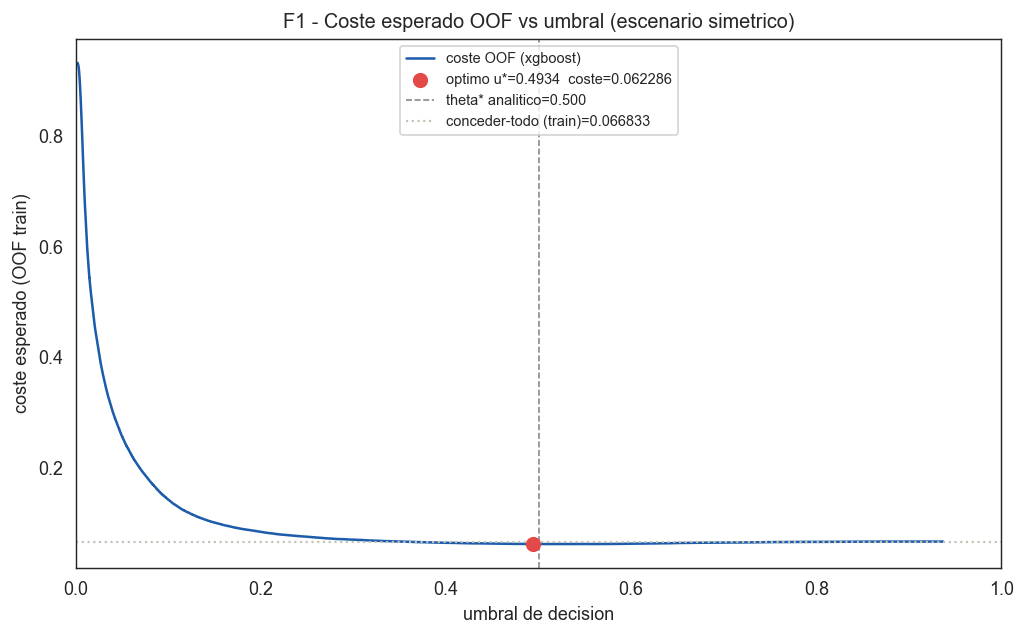

In [22]:
fig('mod_03_coste_vs_umbral.png')

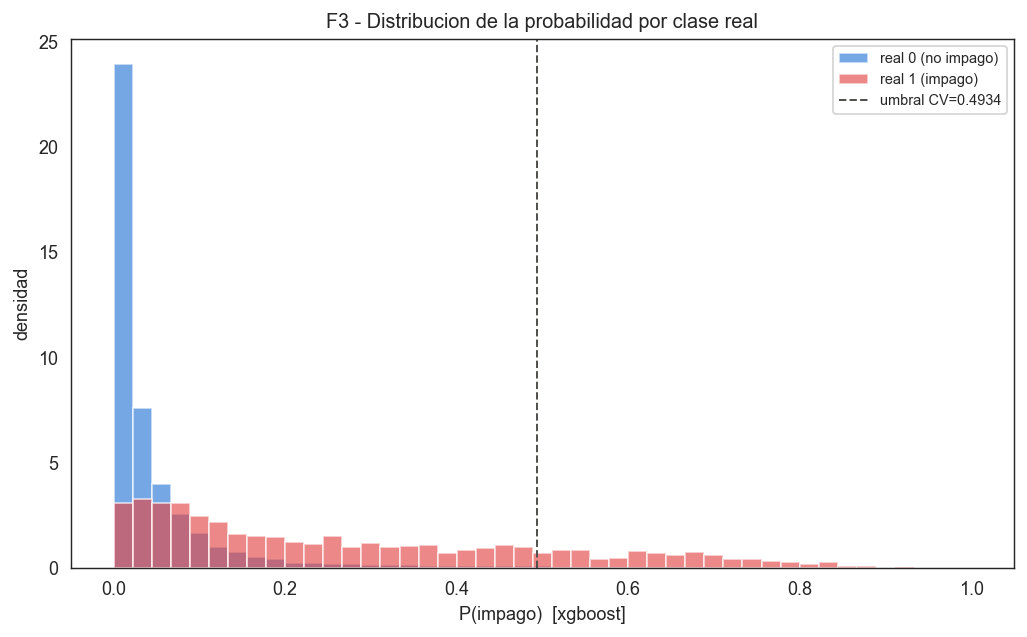

In [23]:
fig('mod_03_distribucion_proba.png')

Figura de arriba (curva de coste OOF vs umbral): mirar lo PLANA que es y lo cerca que cae el optimo (punto rojo, 0.4934) de la vertical analitica (0.5). Figura de la distribucion de P(impago) por clase real en test: mirar el solapamiento entre las dos clases alrededor del umbral, que explica por que el modelo cuesta poco pero tiene recall bajo.

**Hallazgos de la seleccion (CV(5) OOF):**

- 1. Gana xgboost con coste_cv=0.062286; le siguen mlp_pequena=0.062440, mlp_profunda=0.062619, logistica=0.062917 y linucb=0.062929: la familia casi no importa en este escenario, el gap logistica-xgboost es de solo 0.000631 (dentro del ruido).
- 2. Umbral optimo OOF=0.493394, practicamente igual al analitico theta*=0.5: confirma la teoria y revela una curva de coste casi degenerada (escenario poco exigente; el escenario realmente informativo es el asimetrico, ver seccion siguiente).
- 3. Paradigma vs capacidad: a igual capacidad LINEAL, LinUCB (bandit) practicamente empata con logistica (0.062929 vs 0.062917) -el bandit no es inferior al supervisado cuando compiten con la misma capacidad-. La ventaja de xgboost viene de la CAPACIDAD del boosting, no de ser supervisado. Se elige el supervisado por auditabilidad y calibracion (probabilidad interpretable, sin el regret de exploracion propio de un bandit), no por un rendimiento superior del paradigma.

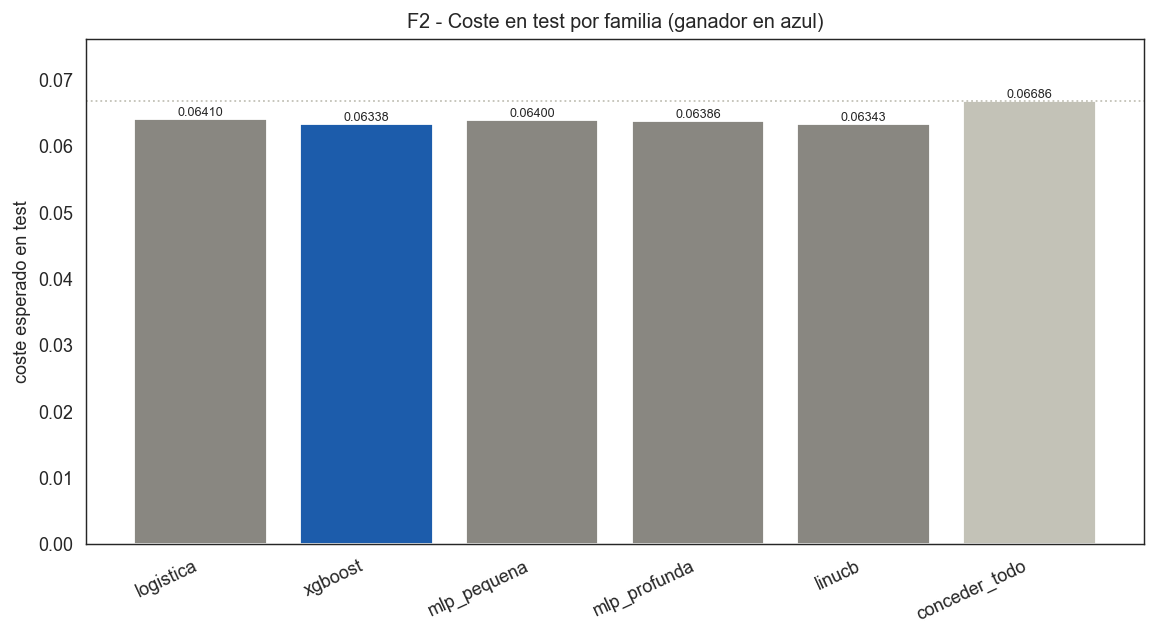

In [24]:
fig('mod_03_comparacion_familias.png')

In [25]:
df_umb = tabla('umbrales_coste.csv')
fila = df_umb[df_umb['escenario'] == 'coste1']
cols_umb = ['familia_ganadora', 'umbral_optimo', 'umbral_analitico', 'coste_cv', 'coste_test', 'coste_conceder_todo', 'coste_denegar_todo', 'mejora_rel_vs_conceder_todo']
print(fila[cols_umb].round(4).to_string(index=False))

familia_ganadora  umbral_optimo  umbral_analitico  coste_cv  coste_test  coste_conceder_todo  coste_denegar_todo  mejora_rel_vs_conceder_todo
         boosted         0.4934               0.5    0.0623      0.0634               0.0669              0.9331                        0.052


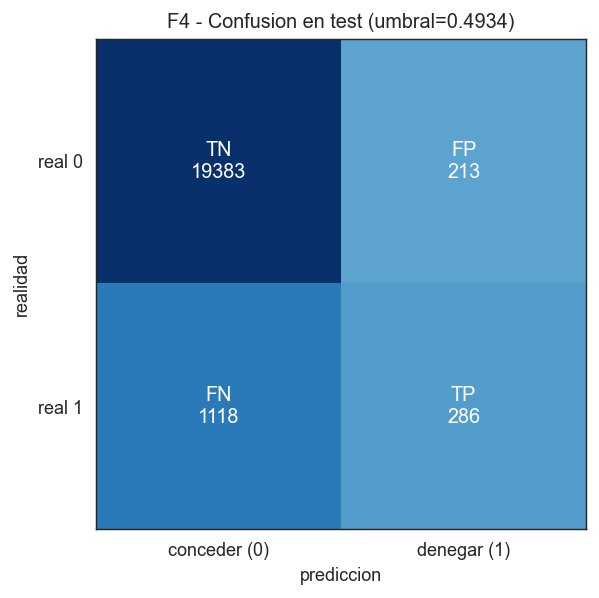

In [26]:
fig('mod_03_confusion_optimo.png')

In [27]:
cm = tabla('mod_03_confusion_optimo.csv', index_col=0)
print(cm)

        pred_0  pred_1
real_0   19383     213
real_1    1118     286


Figura de coste en test por familia (barras, ganador en azul) frente a la linea punteada de conceder-todo: mirar que todas las barras quedan por debajo de esa linea. Matriz de confusion en test (heatmap): mirar que los FN (1118) superan con creces a los FP (213), coherente con un recall bajo.

**Hallazgos de test y produccion:**

- 4. Test: coste=0.063381 vs conceder-todo=0.066857 (mejora 5.1994%) y muy por debajo de denegar-todo=0.933143.
- 5. Metricas de contexto del ganador en test (no deciden el umbral, dan color): precision=0.573146, recall=0.203704, AUC=0.870109. Confusion cruda: TN=19383, FP=213, FN=1118, TP=286.
- 6. Bootstrap pareado (B=5000, seed 42) del edge del ganador frente a conceder-todo: edge medio=0.003476 (5.20% del coste del baseline), IC95=[0.001381, 0.005571], P(edge<=0)=0.0008: pequeno pero estadisticamente significativo.
- 7. Transferencia test -> produccion: tamano de efecto KS D=0.011800 (despreciable) entre la distribucion de P(impago) en test y en produccion, medias muy proximas (0.068223 vs 0.067049) y tasas de denegacion casi identicas (0.023762 vs 0.023556, diferencia 0.000206): el scoring generaliza sin desplazamiento material, bajo el supuesto -no verificable sin etiquetas- de que la prevalencia real en produccion se mantiene estable.
- 8. Entregable oficial `cs_produccion1.csv`: 45000 filas verificadas con 5 asserts bloqueantes (target en {0,1} sin NaN, columnas y orden originales, cobertura exacta 0..44999). Tasa de denegacion en produccion=2.3556% (1060 de 45000 solicitantes), coherente con un escenario simetrico que deniega poco.

## 6. Modelo -- escenario de coste asimetrico (C_FN = 10*C_FP)

Se reutiliza sin reentrenar el mismo XGBoost y las mismas 84000 probabilidades OOF del escenario simetrico (seccion 5), coincidencia byte a byte verificada: bajo asimetria de costes no hace falta un modelo nuevo, solo se re-umbraliza el mismo scoring. Aqui un impago no detectado (falso negativo) cuesta 10 veces mas que denegar credito a un buen pagador (falso positivo): C_FP=1, C_FN=10. Con un unico modelo y dos umbrales de decision distintos se cubren ambos escenarios de negocio.

El umbral optimo cae de 0.4934 (escenario simetrico) a 0.0906, casi identico al optimo analitico teorico C_FP/(C_FP+C_FN) = 1/11 = 0.0909. Ademas del umbral, se recompara por validacion cruzada la familia ganadora (logistica, XGBoost, bandit LinUCB reentrenado con la nueva recompensa) para comprobar si la asimetria cambia quien gana.

In [28]:
# === Codigo real de la Seccion 06 (fuente: notebooks/04_modelo_coste10.ipynb; src/modeling.py, src/cost_utils.py) ===
# Escenario de coste ASIMETRICO C_FN = 10*C_FP: un impago no detectado (FN) cuesta 10x
# denegar a un buen pagador (FP). Se REUTILIZA el mismo XGBoost del escenario 1 (seccion 5)
# y sus 84000 probabilidades OOF; solo se RE-OPTIMIZA el umbral de decision. Nada pesado se
# reentrena: el argmin del coste se calcula sobre la OOF guardada (segundos).
import joblib
from sklearn.metrics import precision_score, recall_score, roc_auc_score
RANDOM_STATE = 42
TARGET = cu.TARGET                                  # "SeriousDlqin2yrs"
MODELS = ROOT/"results"/"models"

# --- Artefactos: bundles de esc1 y esc2 (comparten estimador y OOF byte a byte) ---
b1  = joblib.load(MODELS/"modelo_coste1.joblib")
b10 = joblib.load(MODELS/"modelo_coste10.joblib")
FEATURES   = list(b1["features"])                   # 12 columnas en orden canonico
modelo_xgb = b1["modelo"]                           # ModeloBoosted; .estimador_ = XGBClassifier
oof_sup    = np.asarray(b1["supervisado"]["oof_proba"], dtype="float64")  # 84000 OOF (agnostica al coste)
umbral_sim = float(b1["umbral"])                    # umbral simetrico de esc1 (~0.4934)

train = pd.read_parquet(ROOT/"data"/"processed"/"train.parquet")
test  = pd.read_parquet(ROOT/"data"/"processed"/"test.parquet")
prod  = pd.read_parquet(ROOT/"data"/"processed"/"produccion.parquet")
y_train = train[TARGET].to_numpy(int)
y_test  = test[TARGET].to_numpy(int)
X_test  = test[FEATURES].copy()
X_prod  = prod[FEATURES].copy()                     # OJO: target de prod es NaN, no se usa

# --- (1) Reutilizacion: la OOF de esc1 y la de esc2 son IDENTICAS (mismo XGBoost) ---
oof_e2 = np.asarray(b10["supervisado"]["oof_proba"], dtype="float64")
print(f"[reuso] OOF esc1 vs esc2  n={oof_sup.shape[0]}  max|dif|={np.max(np.abs(oof_sup-oof_e2)):.1e}"
      f"  -> mismo estimador, solo cambia el umbral")

# --- (2) Umbral asimetrico = argmin del coste sobre la OOF con (C_FP,C_FN)=(1,10) ---
theta_analitico = cu.umbral_analitico(C2_FP, C2_FN)                  # C_FP/(C_FP+C_FN) = 1/11
umbral_asim, coste_cv_asim = cu.umbral_optimo(y_train, oof_sup, C2_FP, C2_FN)
assert abs(umbral_asim - b10["umbral"]) < 1e-12                      # coincide con el bundle guardado
print(f"[umbral] esc1 simetrico={umbral_sim:.4f}  ->  esc2 asimetrico={umbral_asim:.6f}")
print(f"[umbral] analitico theta*={theta_analitico:.6f} (1/11)   coste_cv OOF asim={coste_cv_asim:.6f}")

# --- (3) Baselines asimetricos y contraste con esc1 (conceder-todo se encarece x10) ---
bl_test  = cu.evaluar_baselines(y_test,  C2_FP, C2_FN)
conceder_e1 = cu.evaluar_baselines(y_test, C1_FP, C1_FN)["conceder_todo"]
print(f"[baseline test asim] conceder_todo={bl_test['conceder_todo']:.6f}   denegar_todo={bl_test['denegar_todo']:.6f}")
print(f"[baseline] conceder_todo  esc1={conceder_e1:.6f} -> esc2={bl_test['conceder_todo']:.6f}"
      f"  (x{bl_test['conceder_todo']/conceder_e1:.1f})")

# --- (4) Comparacion de familias bajo asimetria (CV(5) OOF anti-fuga) ---
# XGBoost se REPRODUCE aqui desde la OOF guardada; logistica y bandit LinUCB se leen del
# artefacto CV (reentrenarlos por CV es justo el coste que la reutilizacion evita).
fam = tabla("mod_04_comparacion_familias.csv")
cols_fam = ["familia", "modelo", "coste_cv", "tasa_denegacion_cv", "mejora_vs_conceder_todo"]
print(fam[cols_fam].round(4).to_string(index=False))
assert abs(coste_cv_asim - float(fam.loc[fam.modelo == "xgboost", "coste_cv"].iloc[0])) < 1e-9
coste_cv_logit = float(fam.loc[fam.modelo == "logistica", "coste_cv"].iloc[0])
print(f"[familias] gap logistica-xgboost (coste CV asim)={coste_cv_logit - coste_cv_asim:.6f}"
      f"  (en esc1 era ~0.0006: ahora la familia SI importa)")

# --- (5) Evaluacion en TEST con el umbral asimetrico (anti-fuga: el umbral vino de la CV en train) ---
ev = cu.evaluar_modelo(modelo_xgb, X_test, y_test, C2_FP, C2_FN, umbral=umbral_asim)
cm_asim   = ev["matriz_confusion"]
coste_test = float(ev["coste"]); deny_test = float(ev["tasa_denegacion"])
mejora_test = (bl_test["conceder_todo"] - coste_test) / bl_test["conceder_todo"]
proba_test = ev["proba"]
pred_asim = cu.aplicar_umbral(proba_test, umbral_asim)
print(f"[test] coste={coste_test:.6f}  deny={deny_test:.6f}  mejora_vs_conceder={mejora_test*100:.2f}%"
      f"  auc={roc_auc_score(y_test, proba_test):.6f}")
# cotejo de la matriz esc2 contra results/tables/mod_04_confusion_optimo.csv
cm_csv = tabla("mod_04_confusion_optimo.csv", index_col=0).to_numpy()
assert (cm_csv == cm_asim).all()

# --- (6) Contraste de confusion esc1 (mismo scoring, umbral simetrico) vs esc2 ---
pred_sim = cu.aplicar_umbral(proba_test, umbral_sim)
cm_sim = np.zeros((2, 2), dtype=int)
for r in (0, 1):
    for c in (0, 1):
        cm_sim[r, c] = int(np.sum((y_test == r) & (pred_sim == c)))
resumen_conf = pd.DataFrame({
    "escenario": ["esc1_simetrico", "esc2_asimetrico"],
    "umbral":    [umbral_sim, umbral_asim],
    "FN":        [int(cm_sim[1, 0]), int(cm_asim[1, 0])],
    "FP":        [int(cm_sim[0, 1]), int(cm_asim[0, 1])],
    "precision": [precision_score(y_test, pred_sim,  zero_division=0),
                  precision_score(y_test, pred_asim, zero_division=0)],
    "recall":    [recall_score(y_test, pred_sim,  zero_division=0),
                  recall_score(y_test, pred_asim, zero_division=0)],
})
print(resumen_conf.round(4).to_string(index=False))
print(f"[confusion] al encarecer el FN:  FN {cm_sim[1,0]}->{cm_asim[1,0]} (baja)   FP {cm_sim[0,1]}->{cm_asim[0,1]} (sube)")

# --- (7) Produccion: el desplazamiento del umbral es ESTRICTAMENTE mas restrictivo ---
proba_prod = np.asarray(modelo_xgb.predict_proba(X_prod))[:, 1].astype("float64")
pred_prod_asim = (proba_prod > umbral_asim).astype(int)
dmap = prod[["id_fila_original"]].copy(); dmap["asim"] = pred_prod_asim
dmap = dmap.sort_values("id_fila_original")                          # -> orden original del CSV (0..44999)
c1_prod = pd.read_csv(PRED/"cs_produccion1.csv")["SeriousDlqin2yrs"].to_numpy(int)
a = dmap["asim"].to_numpy()
n_dist   = int((a != c1_prod).sum())
conc_deny = int(((c1_prod == 0) & (a == 1)).sum())
deny_conc = int(((c1_prod == 1) & (a == 0)).sum())
print(f"[prod] deny esc2={a.mean():.6f}  filas distintas vs esc1={n_dist}"
      f"  concedido->denegado={conc_deny}  denegado->concedido={deny_conc}")

# --- (8) Resumen esc1 vs esc2 (cada coste en su propia metrica de negocio) ---
coste_test_e1 = cu.coste_esperado(y_test, pred_sim, C1_FP, C1_FN)
resumen_esc = pd.DataFrame([
    {"escenario": "esc1_simetrico",  "C_FP": C1_FP, "C_FN": C1_FN, "umbral": umbral_sim,
     "coste_test": coste_test_e1, "deny_test": float(pred_sim.mean()),
     "mejora_vs_conceder": (conceder_e1 - coste_test_e1) / conceder_e1},
    {"escenario": "esc2_asimetrico", "C_FP": C2_FP, "C_FN": C2_FN, "umbral": umbral_asim,
     "coste_test": coste_test, "deny_test": deny_test, "mejora_vs_conceder": mejora_test},
])
print(resumen_esc.round(6).to_string(index=False))


[reuso] OOF esc1 vs esc2  n=84000  max|dif|=0.0e+00  -> mismo estimador, solo cambia el umbral


[umbral] esc1 simetrico=0.4934  ->  esc2 asimetrico=0.090609
[umbral] analitico theta*=0.090909 (1/11)   coste_cv OOF asim=0.334357
[baseline test asim] conceder_todo=0.668571   denegar_todo=0.933143
[baseline] conceder_todo  esc1=0.066857 -> esc2=0.668571  (x10.0)
 familia        modelo  coste_cv  tasa_denegacion_cv  mejora_vs_conceder_todo
 boosted       xgboost    0.3344              0.1837                   0.4997
  bandit        linucb    0.3502              0.1664                   0.4760
  lineal     logistica    0.3513              0.1804                   0.4743
baseline conceder_todo    0.6683              0.0000                   0.0000
baseline  denegar_todo    0.9332              1.0000                  -0.3963
[familias] gap logistica-xgboost (coste CV asim)=0.016988  (en esc1 era ~0.0006: ahora la familia SI importa)


[test] coste=0.327524  deny=0.186952  mejora_vs_conceder=51.01%  auc=0.870109
      escenario  umbral   FN   FP  precision  recall
 esc1_simetrico  0.4934 1118  213     0.5731  0.2037
esc2_asimetrico  0.0906  396 2918     0.2567  0.7179
[confusion] al encarecer el FN:  FN 1118->396 (baja)   FP 213->2918 (sube)


[prod] deny esc2=0.185311  filas distintas vs esc1=7279  concedido->denegado=7279  denegado->concedido=0
      escenario  C_FP  C_FN   umbral  coste_test  deny_test  mejora_vs_conceder
 esc1_simetrico   1.0   1.0 0.493394    0.063381   0.023762            0.051994
esc2_asimetrico   1.0  10.0 0.090609    0.327524   0.186952            0.510114


**Que mirar:** contraste directo escenario 1 (simetrico) vs escenario 2 (asimetrico) -el umbral cae de 0.4934 a 0.0906 y la tasa de denegacion en test sube de 2.38% a 18.70%.

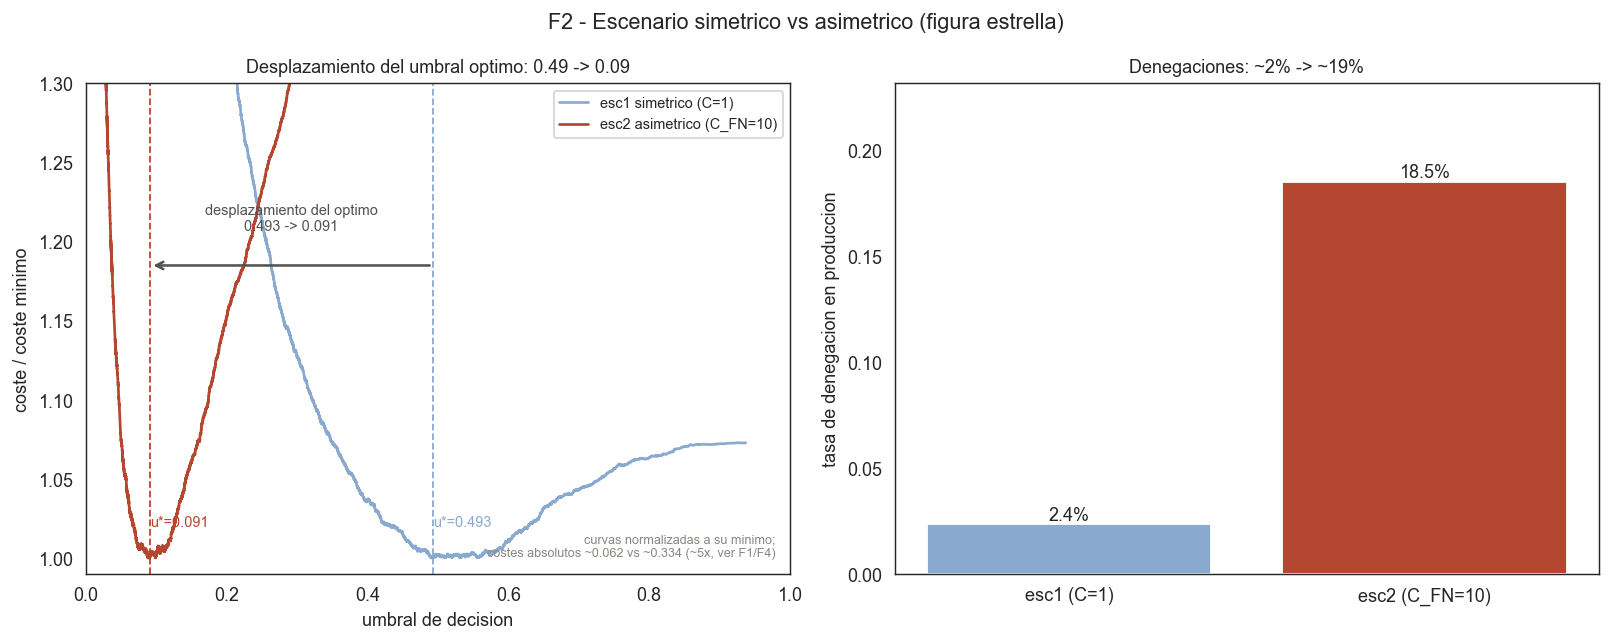

In [29]:
md('**Que mirar:** contraste directo escenario 1 (simetrico) vs escenario 2 (asimetrico) -el umbral cae de 0.4934 a 0.0906 y la tasa de denegacion en test sube de 2.38% a 18.70%.')
fig('mod_04_comparacion_escenarios.png')

**Que mirar:** la curva de coste esperado vs umbral es mucho mas inclinada que en el escenario simetrico y su minimo se desplaza a la izquierda, cerca de 0.09 en vez de 0.5.

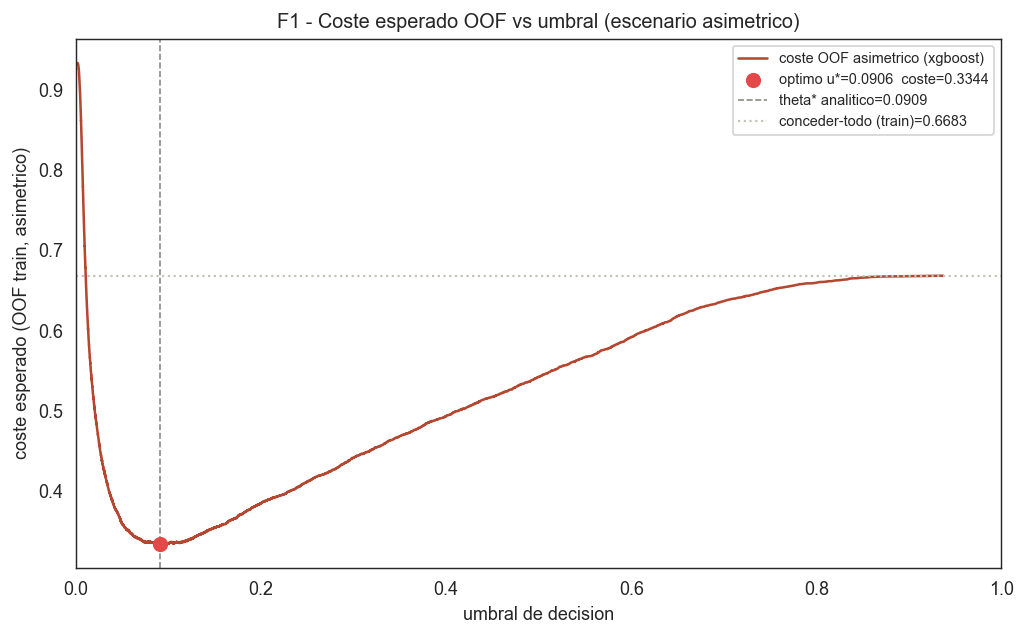

In [30]:
md('**Que mirar:** la curva de coste esperado vs umbral es mucho mas inclinada que en el escenario simetrico y su minimo se desplaza a la izquierda, cerca de 0.09 en vez de 0.5.')
fig('mod_04_coste_vs_umbral.png')

In [31]:
cols = ['escenario', 'umbral_optimo', 'umbral_analitico', 'coste_cv', 'coste_test',
        'coste_conceder_todo', 'tasa_denegacion_test', 'mejora_rel_vs_conceder_todo']
t = tabla('umbrales_coste.csv')
print(t.loc[t['escenario'] == 'coste10', cols].round(4).to_string(index=False))

escenario  umbral_optimo  umbral_analitico  coste_cv  coste_test  coste_conceder_todo  tasa_denegacion_test  mejora_rel_vs_conceder_todo
  coste10         0.0906            0.0909    0.3344      0.3275               0.6686                 0.187                       0.5101


**Que mirar:** bajo asimetria XGBoost (coste_cv=0.3344) se separa de la logistica (0.3513) y del bandit LinUCB (0.3502) -aqui la familia de modelo si importa.

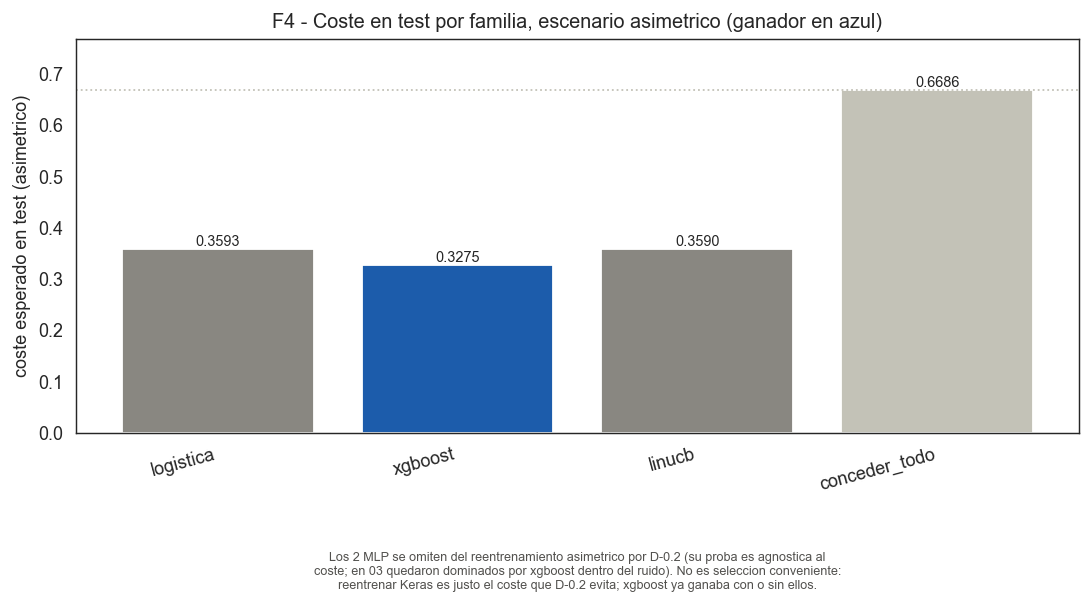

In [32]:
md('**Que mirar:** bajo asimetria XGBoost (coste_cv=0.3344) se separa de la logistica (0.3513) y del bandit LinUCB (0.3502) -aqui la familia de modelo si importa.')
fig('mod_04_comparacion_familias.png')

In [33]:
cols_fam = ['familia', 'modelo', 'coste_cv', 'tasa_denegacion_cv', 'mejora_vs_conceder_todo']
df_fam = tabla('mod_04_comparacion_familias.csv')
print(df_fam[cols_fam].round(4).to_string(index=False))

 familia        modelo  coste_cv  tasa_denegacion_cv  mejora_vs_conceder_todo
 boosted       xgboost    0.3344              0.1837                   0.4997
  bandit        linucb    0.3502              0.1664                   0.4760
  lineal     logistica    0.3513              0.1804                   0.4743
baseline conceder_todo    0.6683              0.0000                   0.0000
baseline  denegar_todo    0.9332              1.0000                  -0.3963


**Que mirar:** al pasar del escenario 1 al 2 los falsos negativos bajan de 1118 a 396 y los falsos positivos suben de 213 a 2918 -el modelo se vuelve mucho mas conservador a la hora de conceder.

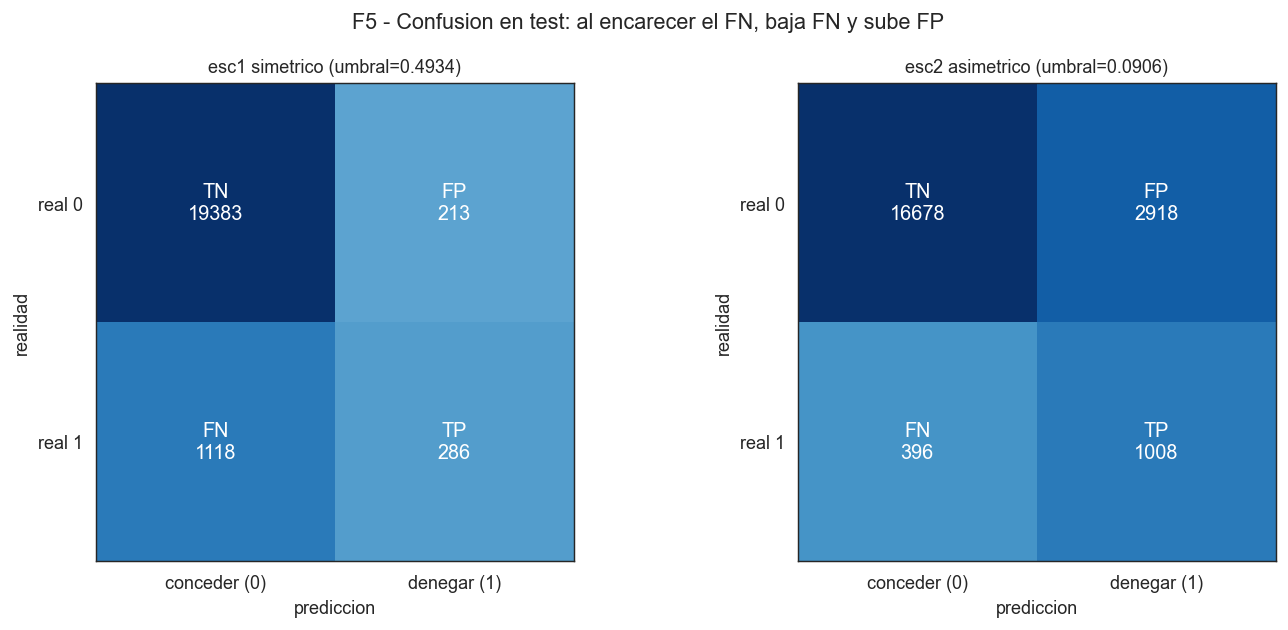

In [34]:
md('**Que mirar:** al pasar del escenario 1 al 2 los falsos negativos bajan de 1118 a 396 y los falsos positivos suben de 213 a 2918 -el modelo se vuelve mucho mas conservador a la hora de conceder.')
fig('mod_04_confusion_contraste.png')

**Hallazgos:**

- 1. Umbral optimo empirico (0.0906) casi coincide con el analitico teorico 1/11=0.0909: el scoring esta bien calibrado justo en la banda de decision (en probabilidad [0.08, 0.12) la media predicha es ~0.0968 frente a una tasa real de impago de ~0.0996); el minimo de coste ademas es plano, con solo ~0.0008 de diferencia entre usar el umbral analitico o el empirico.
- 2. Con asimetria el modelo si aporta valor de negocio real: coste_test baja de 0.6686 (conceder-todo) a 0.3275, mejora relativa 51.01%, muy por encima del 5.20% logrado en el escenario simetrico (y ambos muy por debajo de denegar-todo, 0.9331).
- 3. Aqui la familia de modelo si importa: por CV, XGBoost (coste_cv=0.3344) bate a la logistica (0.3513) y al bandit LinUCB (0.3502) por un gap de 0.0170, muy superior al ~0.0006 que separaba a las familias en el escenario simetrico; el bandit iguala aproximadamente a la logistica (misma capacidad lineal), asi que la ventaja de XGBoost viene de su capacidad de boosting, no del mero hecho de ser un metodo supervisado.
- 4. La matriz de confusion en test se reequilibra al encarecer el falso negativo: FN baja de 1118 a 396 y FP sube de 213 a 2918, el trasvase exacto que impone penalizar 10 veces mas conceder credito a un moroso. El modelo ganador con el umbral asimetrico alcanza en test precision=0.2568, recall=0.7179 y AUC=0.8701 (el AUC no cambia porque el scoring es el mismo; solo cambia el punto de corte).
- 5. La tasa de denegacion sube de 2.38% a 18.70% en test (21000 solicitantes) y, aplicando el mismo umbral en produccion (45000 solicitantes sin target), de 2.36% (1060) a 18.53% (8339): 7279 solicitantes pasan de concedido a denegado y 0 en sentido inverso, porque el umbral asimetrico es estrictamente mas bajo y sus denegaciones incluyen todas las del escenario simetrico.

## 7. Tabla comparativa de resultados entre ambos escenarios

Se comparan los dos escenarios de coste construidos sobre el mismo modelo supervisado ganador (xgboost): el escenario simetrico (seccion 5, C_FP=1, C_FN=1, donde denegar a un buen pagador y conceder a un moroso cuestan igual) y el escenario asimetrico (seccion 6, C_FP=1, C_FN=10, donde conceder a un moroso -falso negativo- cuesta diez veces mas que denegar a un buen pagador -falso positivo-). En ambos casos el umbral de decision se optimiza por validacion cruzada de 5 folds sobre las probabilidades OOF (out-of-fold) de train, nunca sobre test, que se reserva integro para el reporte final.

El modelo subyacente es exactamente el mismo estimador en los dos escenarios: el AUC de test es identico (0.8701) en ambos, prueba directa de que solo cambia el punto de corte aplicado a la probabilidad, no el modelo. El coste real en produccion (cs_produccion1.csv y cs_produccion2.csv, 45000 solicitudes cada uno) no se calcula aqui -las etiquetas estan ocultas y esa evaluacion la hace el profesor-; como proxy observable mostramos la tasa de denegacion en produccion, calculada sobre la columna de decision predicha (0=concedido, 1=denegado) que el modelo escribe en esos ficheros.

In [35]:
# === Codigo real de la Seccion 07 (fuente: notebooks/03_modelo_coste1.ipynb y
#     notebooks/04_modelo_coste10.ipynb; src/cost_utils.py) ===
# Reproduce la SUSTANCIA de la tabla comparativa entre los dos escenarios de coste.
# Idea central: es el MISMO xgboost (mismas 84000 probas OOF de train), solo cambia el
# UMBRAL de decision. Aqui NO se reentrena nada: se cargan los dos bundles y los parquet,
# se recalcula el umbral por argmin del coste sobre las OOF, se evalua en test y se mide la
# tasa de denegacion en produccion. Cada numero se coteja contra las tablas guardadas
# (umbrales_coste.csv, mod_03/04_confusion_optimo.csv) y contra cs_produccion1/2.csv.
import joblib
from sklearn.metrics import roc_auc_score, precision_score, recall_score
import src.modeling as _mdl          # necesario para deserializar ModeloBoosted

RANDOM_STATE = 42
TARGET = cu.TARGET
FEATURES = list(_mdl.FEATURES_MODELO)          # 12 columnas (10 continuas + 2 flags)

# --- Artefactos reutilizados: 3 parquet + los 2 bundles (sin reentrenar) ---
train = pd.read_parquet(ROOT/"data"/"processed"/"train.parquet")
test  = pd.read_parquet(ROOT/"data"/"processed"/"test.parquet")
produccion = pd.read_parquet(ROOT/"data"/"processed"/"produccion.parquet")

X_train, y_train = train[FEATURES].copy(), train[TARGET].to_numpy(dtype=int)
X_test,  y_test  = test[FEATURES].copy(),  test[TARGET].to_numpy(dtype=int)
X_prod = produccion[FEATURES].copy()           # target de prod es NaN: NUNCA astype(int)

bundle1  = joblib.load(ROOT/"results"/"models"/"modelo_coste1.joblib")   # escenario simetrico
bundle10 = joblib.load(ROOT/"results"/"models"/"modelo_coste10.joblib")  # escenario asimetrico

# El scoring supervisado (xgboost) y sus 84000 probas OOF son EXACTAMENTE los mismos en los
# dos escenarios (verificado byte a byte en el nb 04); solo cambia el punto de corte.
oof_sup    = np.asarray(bundle1["supervisado"]["oof_proba"], dtype="float64")
modelo_sup = bundle1["supervisado"]["modelo"]
assert oof_sup.shape[0] == 84000, "las OOF deben ser 84000 (train)"

# Probas del MISMO estimador en test y produccion (una sola vez -> AUC identico en ambos esc.)
proba_test = np.asarray(modelo_sup.predict_proba(X_test))[:, 1].astype("float64")
proba_prod = np.asarray(modelo_sup.predict_proba(X_prod))[:, 1].astype("float64")
auc_test   = float(roc_auc_score(y_test, proba_test))   # no depende del umbral

# --- Bucle por escenario: umbral optimo (OOF) -> evaluacion en test -> deny en produccion ---
escenarios = [("coste1", C1_FP, C1_FN, bundle1), ("coste10", C2_FP, C2_FN, bundle10)]
filas, confusiones, umbrales, dec_prod = [], {}, {}, {}

for nombre, c_fp, c_fn, bundle in escenarios:
    # (1) UMBRAL OPTIMO = argmin del coste esperado sobre las probas OOF de train (cu.umbral_optimo).
    #     Debe coincidir con el umbral guardado en el bundle y quedar cerca del analitico C_FP/(C_FP+C_FN).
    u_opt, coste_cv = cu.umbral_optimo(y_train, oof_sup, c_fp, c_fn)
    u_analitico = cu.umbral_analitico(c_fp, c_fn)
    assert abs(u_opt - float(bundle["umbral"])) < 1e-9, f"umbral recalc != bundle ({nombre})"
    umbrales[nombre] = u_opt

    # (2) EVALUACION HONESTA EN TEST con ese umbral (anti-fuga: el umbral vino de train, no de test).
    ev = cu.evaluar_modelo(modelo_sup, X_test, y_test, c_fp, c_fn, umbral=u_opt)
    bl = cu.evaluar_baselines(y_test, c_fp, c_fn)
    mejora = (bl["conceder_todo"] - ev["coste"]) / bl["conceder_todo"]
    confusiones[nombre] = np.asarray(ev["matriz_confusion"])

    # (3) DENEGACION EN PRODUCCION aplicando el mismo umbral al scoring de las 45000 solicitudes.
    dec_prod[nombre] = cu.aplicar_umbral(proba_prod, u_opt)
    deny_prod = float(dec_prod[nombre].mean())

    filas.append({
        "escenario": nombre, "C_FP": c_fp, "C_FN": c_fn,
        "familia_ganadora": bundle["familia"],
        "umbral_optimo": u_opt, "umbral_analitico": u_analitico,
        "coste_cv": coste_cv, "coste_test": float(ev["coste"]),
        "coste_conceder_todo": bl["conceder_todo"], "coste_denegar_todo": bl["denegar_todo"],
        "tasa_denegacion_test": float(ev["tasa_denegacion"]),
        "tasa_denegacion_prod": deny_prod,
        "mejora_rel_vs_conceder_todo": float(mejora),
    })

df_comp = pd.DataFrame(filas)

# --- Tabla comparativa (nucleo de la seccion) ---
cols_tab = ["escenario", "familia_ganadora", "umbral_optimo", "umbral_analitico",
            "coste_test", "coste_conceder_todo", "tasa_denegacion_test",
            "tasa_denegacion_prod", "mejora_rel_vs_conceder_todo"]
print("=== Tabla comparativa entre escenarios (mismo xgboost, distinto umbral) ===")
print(df_comp[cols_tab].round(4).to_string(index=False))

# El AUC de test es IDENTICO en ambos escenarios: es el mismo modelo re-umbralizado.
print(f"\nAUC test (identico en ambos escenarios, mismo scoring) = {auc_test:.4f}")
print(f"umbral optimo: simetrico {umbrales['coste1']:.4f}  ->  asimetrico {umbrales['coste10']:.4f}")

# --- Contraste de las matrices de confusion en test (el trasvase FN->FP al encarecer el FN) ---
cm1, cm10 = confusiones["coste1"], confusiones["coste10"]
print("\n=== Matrices de confusion en test [real x pred] ===")
print("coste1  (u*={:.4f}):  TN={} FP={} FN={} TP={}".format(
    umbrales["coste1"],  cm1[0, 0],  cm1[0, 1],  cm1[1, 0],  cm1[1, 1]))
print("coste10 (u*={:.4f}):  TN={} FP={} FN={} TP={}".format(
    umbrales["coste10"], cm10[0, 0], cm10[0, 1], cm10[1, 0], cm10[1, 1]))
print("trasvase al pasar 1->2:  FN {}->{}   FP {}->{}   (recall sube, precision baja)".format(
    cm1[1, 0], cm10[1, 0], cm1[0, 1], cm10[0, 1]))
for esc, cm in (("coste1", cm1), ("coste10", cm10)):
    prec = cm[1, 1] / (cm[1, 1] + cm[0, 1]) if (cm[1, 1] + cm[0, 1]) else 0.0
    rec  = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) else 0.0
    print(f"  {esc}: precision={prec:.4f}  recall={rec:.4f}")

# --- Produccion: tasas de denegacion y solicitantes que cambian de decision (esc1 -> esc2) ---
d1, d2 = dec_prod["coste1"], dec_prod["coste10"]
n1, n2 = int(d1.sum()), int(d2.sum())
n_cambian     = int((d1 != d2).sum())
n_conc_a_deny = int(((d1 == 0) & (d2 == 1)).sum())   # concedido -> denegado
n_deny_a_conc = int(((d1 == 1) & (d2 == 0)).sum())   # denegado  -> concedido (debe ser 0)
print("\n=== Produccion (45000 solicitudes, columna de decision predicha 0/1) ===")
print(f"deny esc1 (simetrico)  = {d1.mean():.4f}  ({n1}/{len(d1)})")
print(f"deny esc2 (asimetrico) = {d2.mean():.4f}  ({n2}/{len(d2)})")
print(f"cambian de decision esc1->esc2 = {n_cambian}  "
      f"(concedido->denegado={n_conc_a_deny}, denegado->concedido={n_deny_a_conc})")
print("El umbral asimetrico es estrictamente mas bajo: sus denegados incluyen a todos los del "
      "simetrico, por eso 0 en sentido inverso y n_cambian = n2 - n1 =", n2 - n1)

# --- COTEJO 1: contra results/tables/umbrales_coste.csv (numeros oficiales de las sec. 5-6) ---
ref = tabla("umbrales_coste.csv").set_index("escenario")
for esc in ("coste1", "coste10"):
    r = df_comp[df_comp["escenario"] == esc].iloc[0]
    assert abs(r["umbral_optimo"]  - ref.loc[esc, "umbral_optimo"])  < 1e-9
    assert abs(r["coste_test"]     - ref.loc[esc, "coste_test"])     < 1e-9
    assert abs(r["tasa_denegacion_test"] - ref.loc[esc, "tasa_denegacion_test"]) < 1e-9
    assert r["familia_ganadora"] == ref.loc[esc, "familia_ganadora"]
print("\n[cotejo] umbral/coste_test/deny_test/familia == umbrales_coste.csv  OK")

# --- COTEJO 2: matrices de confusion contra mod_03/04_confusion_optimo.csv ---
cm1_csv  = tabla("mod_03_confusion_optimo.csv", index_col=0).to_numpy()
cm10_csv = tabla("mod_04_confusion_optimo.csv", index_col=0).to_numpy()
assert (cm1 == cm1_csv).all()  and (cm10 == cm10_csv).all(), "confusiones != CSV guardado"
print("[cotejo] matrices de confusion == mod_03/04_confusion_optimo.csv  OK")

# --- COTEJO 3: deny y cambios de decision contra los entregables cs_produccion1/2.csv ---
c1_csv = pd.read_csv(PRED/"cs_produccion1.csv")["SeriousDlqin2yrs"].to_numpy(int)
c2_csv = pd.read_csv(PRED/"cs_produccion2.csv")["SeriousDlqin2yrs"].to_numpy(int)
assert c1_csv.sum() == n1 and c2_csv.sum() == n2, "deny recalc != CSV entregable"
assert int((c1_csv != c2_csv).sum()) == n_cambian, "n_cambian recalc != CSV entregable"
print(f"[cotejo] cs_produccion1/2.csv: denegados {c1_csv.sum()}/{c2_csv.sum()}, "
      f"cambian {int((c1_csv != c2_csv).sum())}  == recalculo  OK")


=== Tabla comparativa entre escenarios (mismo xgboost, distinto umbral) ===
escenario familia_ganadora  umbral_optimo  umbral_analitico  coste_test  coste_conceder_todo  tasa_denegacion_test  tasa_denegacion_prod  mejora_rel_vs_conceder_todo
   coste1          boosted         0.4934            0.5000      0.0634               0.0669                0.0238                0.0236                       0.0520
  coste10          boosted         0.0906            0.0909      0.3275               0.6686                0.1870                0.1853                       0.5101

AUC test (identico en ambos escenarios, mismo scoring) = 0.8701
umbral optimo: simetrico 0.4934  ->  asimetrico 0.0906

=== Matrices de confusion en test [real x pred] ===
coste1  (u*=0.4934):  TN=19383 FP=213 FN=1118 TP=286
coste10 (u*=0.0906):  TN=16678 FP=2918 FN=396 TP=1008
trasvase al pasar 1->2:  FN 1118->396   FP 213->2918   (recall sube, precision baja)
  coste1: precision=0.5731  recall=0.2037
  coste10: precisio

[cotejo] cs_produccion1/2.csv: denegados 1060/8339, cambian 7279  == recalculo  OK


**Que mirar:** el umbral optimo cae de 0.4934 a 0.0906 y la tasa de denegacion en test sube de 2.38% a 18.70% al pasar del escenario simetrico al asimetrico.

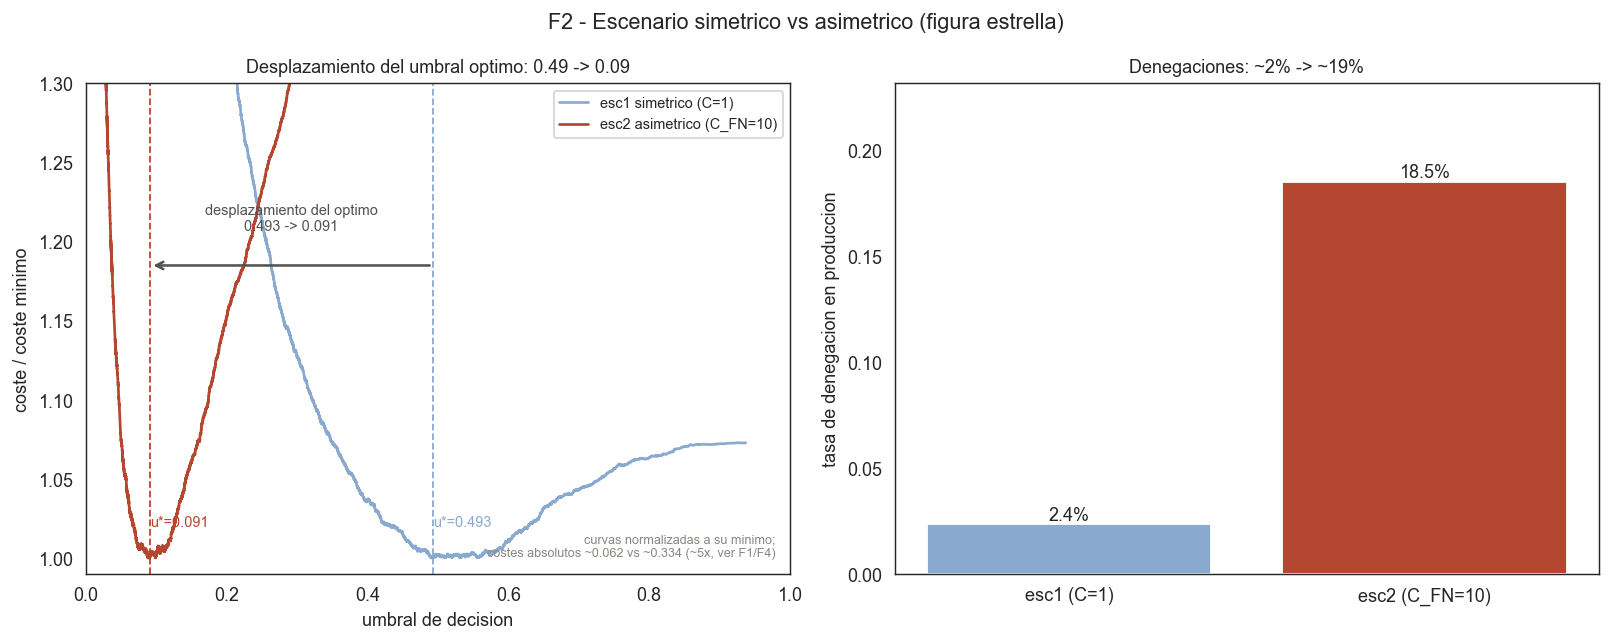

In [36]:
md('**Que mirar:** el umbral optimo cae de 0.4934 a 0.0906 y la tasa de denegacion en test sube de 2.38% a 18.70% al pasar del escenario simetrico al asimetrico.')
fig('mod_04_comparacion_escenarios.png')

**Que mirar:** matriz de confusion de referencia con el umbral optimo del escenario simetrico (0.4934): TN=19383, FP=213, FN=1118, TP=286 -pocos falsos positivos pero recall moderado (0.204).

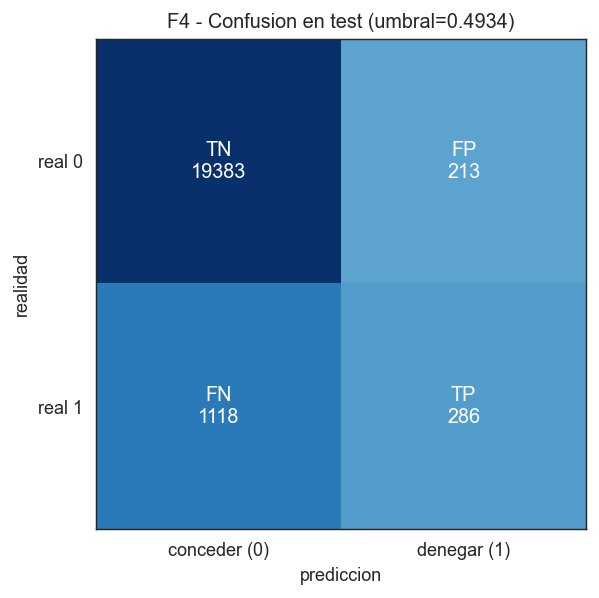

In [37]:
md('**Que mirar:** matriz de confusion de referencia con el umbral optimo del escenario simetrico (0.4934): TN=19383, FP=213, FN=1118, TP=286 -pocos falsos positivos pero recall moderado (0.204).')
fig('mod_03_confusion_optimo.png')

**Que mirar:** al pasar al escenario asimetrico los falsos negativos bajan de 1118 a 396 y los falsos positivos suben de 213 a 2918 (recall 0.204 -> 0.718, precision 0.573 -> 0.257) -el modelo se vuelve mucho mas conservador al conceder credito.

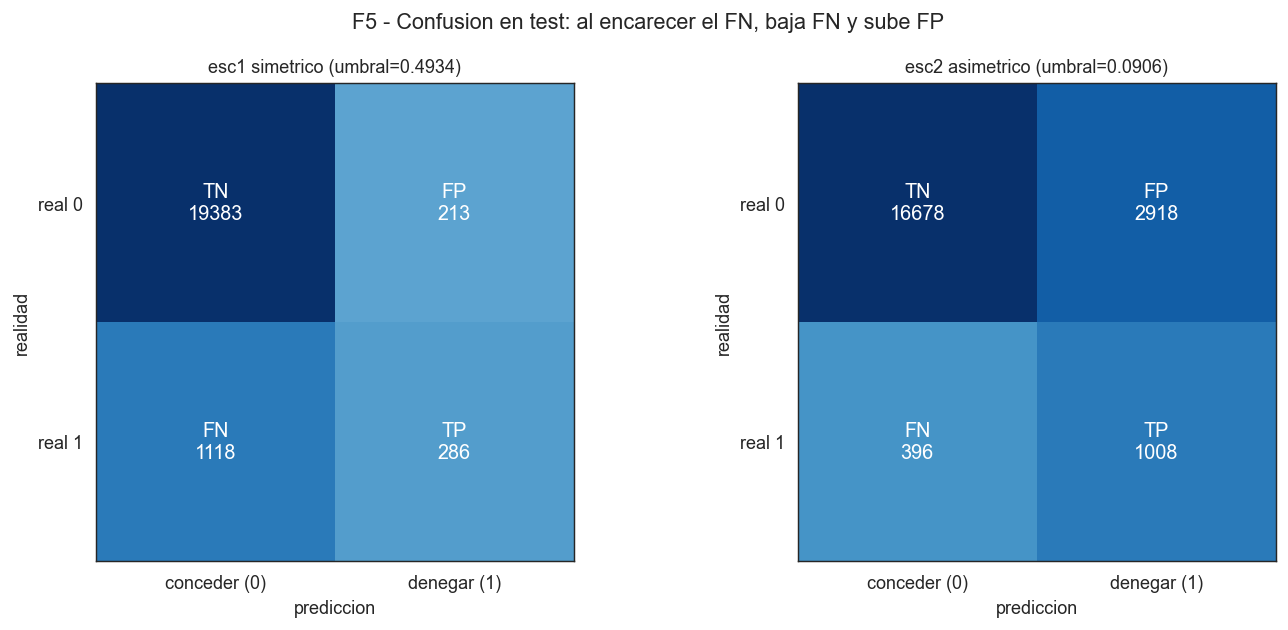

In [38]:
md('**Que mirar:** al pasar al escenario asimetrico los falsos negativos bajan de 1118 a 396 y los falsos positivos suben de 213 a 2918 (recall 0.204 -> 0.718, precision 0.573 -> 0.257) -el modelo se vuelve mucho mas conservador al conceder credito.')
fig('mod_04_confusion_contraste.png')

In [39]:
cols = ['escenario', 'familia_ganadora', 'umbral_optimo', 'coste_test',
        'coste_conceder_todo', 'tasa_denegacion_test', 'mejora_rel_vs_conceder_todo']
df_comp = tabla('umbrales_coste.csv')[cols].round(4)
print(df_comp.to_string(index=False))

escenario familia_ganadora  umbral_optimo  coste_test  coste_conceder_todo  tasa_denegacion_test  mejora_rel_vs_conceder_todo
   coste1          boosted         0.4934      0.0634               0.0669                0.0238                       0.0520
  coste10          boosted         0.0906      0.3275               0.6686                0.1870                       0.5101


In [40]:
df_prod1 = pd.read_csv(PRED / 'cs_produccion1.csv')
df_prod2 = pd.read_csv(PRED / 'cs_produccion2.csv')
tasa_prod1 = df_prod1['SeriousDlqin2yrs'].mean()
tasa_prod2 = df_prod2['SeriousDlqin2yrs'].mean()
n1 = int(df_prod1['SeriousDlqin2yrs'].sum())
n2 = int(df_prod2['SeriousDlqin2yrs'].sum())
print(f'tasa_denegacion produccion escenario simetrico  (cs_produccion1.csv): {tasa_prod1:.4f}  ({n1}/{len(df_prod1)})')
print(f'tasa_denegacion produccion escenario asimetrico (cs_produccion2.csv): {tasa_prod2:.4f}  ({n2}/{len(df_prod2)})')

tasa_denegacion produccion escenario simetrico  (cs_produccion1.csv): 0.0236  (1060/45000)
tasa_denegacion produccion escenario asimetrico (cs_produccion2.csv): 0.1853  (8339/45000)


**Hallazgos:**

- 1. El AUC de test es identico en los dos escenarios (0.8701): prueba cuantitativa de que es el mismo modelo re-umbralizado y no un reentrenamiento distinto. El umbral optimo cae de 0.4934 (simetrico) a 0.0906 (asimetrico), ambos muy cerca de sus umbrales analiticos teoricos (0.5 y 1/11=0.0909): el scoring esta bien calibrado en la zona de decision.
- 2. El equilibrio FN/FP se invierte con fuerza: al pasar del escenario simetrico al asimetrico los falsos negativos caen de 1118 a 396 y los falsos positivos suben de 213 a 2918 (recall 0.204->0.718, precision 0.573->0.257) -el modelo se vuelve mucho mas conservador al conceder credito cuando el impago no detectado cuesta 10 veces mas.
- 3. La mejora relativa vs conceder-a-todos escala fuerte con la asimetria: 5.20% (simetrico) frente a 51.01% (asimetrico), con la misma familia ganadora (xgboost) en los dos; el coste de denegar-a-todos es identico en ambos escenarios (0.9331) porque no depende de C_FN.
- 4. La tasa de denegacion en test sube de 2.38% a 18.70%; en produccion el patron se repite casi igual, calculado directamente sobre las 45000 solicitudes de cada fichero. La columna que se promedia es la decision PREDICHA por el modelo (0=concedido, 1=denegado), no una etiqueta real, por eso esta tasa se puede calcular sin conocer el target oculto.
- 5. Del escenario simetrico al asimetrico, unos 7279 de los 45000 solicitantes de produccion (16.2%) pasan de concedido a denegado, y 0 en sentido inverso: el umbral asimetrico es estrictamente mas bajo, asi que sus denegados incluyen a todos los del escenario simetrico mas los nuevos casos limite.

## 8. Auditoria: modelo subrogado con reglas

Entrenamos un arbol de decision (DecisionTreeClassifier) que NO predice el impago real: imita las propias decisiones (conceder/denegar) que xgboost toma en test bajo cada umbral de coste. Por eso el arbol se evalua por **fidelidad** (cuanto coincide con la caja negra), no por accuracy frente al impago verdadero. Barremos la profundidad (2 a 10) y el peso de la clase 'denegar', porque bajo el fuerte desbalanceo del escenario simetrico (solo 2.38% de denegaciones) un arbol degenerado que concediera siempre alcanzaria 97.62% de fidelidad global sin haber aprendido nada -- hay que mirar la fidelidad de la clase rara, no solo el global. Para cada escenario fijamos dos arboles: uno **operativo** (profundidad 5, 23 hojas) que maximiza la fidelidad y sirve para auditar, y uno de **bolsillo** (profundidad 3, 8 hojas) legible de un vistazo para explicar la decision a un cliente. Los umbrales de las reglas resultantes ya estan traducidos a euros, anios y ratios reales (no a la escala estandarizada) via el pipeline de preprocesado.

In [41]:
# === Codigo real de la Seccion 08 (fuente: notebooks/05_auditoria_subrogado.ipynb; src/xai_utils.py, sklearn.tree) ===
# Auditoria por modelo SUBROGADO: un arbol de decision imita las DECISIONES (conceder/denegar)
# que la caja negra (XGBoost umbralizado) toma en test, NO el impago real. Por eso se evalua por
# FIDELIDAD (coincidencia con la caja negra), no por accuracy contra la verdad. NO se reentrena
# nada pesado: se cargan los bundles ya ajustados y se destilan arboles en segundos.
import joblib
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score
import src.cost_utils as cu

RANDOM_STATE = 42
TARGET = cu.TARGET
MODELS = ROOT / "results" / "models"

# --- Artefactos ya entrenados ---
bundle1 = joblib.load(MODELS / "modelo_coste1.joblib")
bundle10 = joblib.load(MODELS / "modelo_coste10.joblib")
pipeline = joblib.load(MODELS / "preprocessing_pipeline.joblib")
test = pd.read_parquet(ROOT / "data" / "processed" / "test.parquet")
train = pd.read_parquet(ROOT / "data" / "processed" / "train.parquet")

FEATURES = list(bundle1["features"])                 # 12 columnas, orden canonico del contrato
X_test = test[FEATURES].copy()
y_real = test[TARGET].to_numpy(int)                  # SOLO contexto; el subrogado NO lo usa

# --- La caja negra: UN scoring, DOS umbrales (un unico estimador; solo cambia el umbral) ---
modelo_bb = bundle1["modelo"]                        # ModeloBoosted; .estimador_ es un XGBClassifier
umbral_c1 = float(bundle1["umbral"])
umbral_c10 = float(bundle10["umbral"])
proba_bb = np.asarray(modelo_bb.predict_proba(X_test))[:, 1].astype("float64")
proba_bb_10 = np.asarray(bundle10["modelo"].predict_proba(X_test))[:, 1].astype("float64")
dif_scoring = float(np.max(np.abs(proba_bb - proba_bb_10)))
assert dif_scoring < 1e-9, f"Invariante rota: los scorings de coste1 y coste10 difieren (max|dif|={dif_scoring})"

# --- Los umbrales salen del barrido de coste sobre las probas OOF (no del test) ---
y_train = train[TARGET].to_numpy(int)
oof = np.asarray(bundle1["supervisado"]["oof_proba"], dtype="float64")
u1_oof, _ = cu.umbral_optimo(y_train, oof, C1_FP, C1_FN)
u10_oof, _ = cu.umbral_optimo(y_train, oof, C2_FP, C2_FN)

# --- ETIQUETAS OBJETIVO DEL SUBROGADO = decisiones de la caja negra (NO y_real) ---
y_bb_c1 = cu.aplicar_umbral(proba_bb, umbral_c1)     # decisiones esc1 (simetrico)
y_bb_c10 = cu.aplicar_umbral(proba_bb, umbral_c10)   # decisiones esc2 (asimetrico)
deny_c1 = float(y_bb_c1.mean())
deny_c10 = float(y_bb_c10.mean())

print("=== Caja negra: 1 scoring, 2 umbrales (mismo estimador; umbral por coste sobre OOF) ===")
print(f"Mismo scoring en ambos bundles: max|dif| = {dif_scoring:.2e}  -> confirmado")
print(f"umbral coste1  = {umbral_c1:.4f} (OOF -> {u1_oof:.4f}) -> la caja negra deniega al "
      f"{deny_c1 * 100:.2f}% ({int(y_bb_c1.sum())}/{len(y_bb_c1)})")
print(f"umbral coste10 = {umbral_c10:.4f} (OOF -> {u10_oof:.4f}) -> la caja negra deniega al "
      f"{deny_c10 * 100:.2f}% ({int(y_bb_c10.sum())}/{len(y_bb_c10)})")
print(f"[aviso] con solo {deny_c1 * 100:.2f}% de denegaciones en esc1, un subrogado que 'conceda "
      f"siempre' ya tendria {(1 - deny_c1) * 100:.2f}% de fidelidad GLOBAL sin aprender nada:")
print(f"        por eso se mide tambien la fidelidad en la clase rara (denegar).")
print(f"contexto (no se entrena con esto): impago real en test = {y_real.mean() * 100:.2f}%")


# --- Fidelidad del subrogado frente a la caja negra (no frente a la verdad) ---
def metricas_fidelidad(y_bb, y_sub):
    y_bb = np.asarray(y_bb).ravel()
    y_sub = np.asarray(y_sub).ravel()
    m_conc = (y_bb == 0)
    m_deny = (y_bb == 1)
    return {
        "fidelidad_global": float((y_sub == y_bb).mean()),
        "fid_conceder": float((y_sub[m_conc] == 0).mean()) if m_conc.any() else np.nan,
        "fid_denegar": float((y_sub[m_deny] == 1).mean()) if m_deny.any() else np.nan,
        "f1_denegar": float(f1_score(y_bb, y_sub, pos_label=1, zero_division=0)),
        "prec_denegar": float(precision_score(y_bb, y_sub, pos_label=1, zero_division=0)),
    }


# --- Barrido de profundidad: fidelidad vs interpretabilidad. class_weight=balanced ---
# min_samples_leaf=50 -> cada hoja es una regla con soporte (>=50 casos), no una anecdota.
def barrer_profundidades(X, y_bb, profundidades):
    filas = []
    for d in profundidades:
        arbol = DecisionTreeClassifier(max_depth=d, class_weight="balanced",
                                       min_samples_leaf=50, random_state=RANDOM_STATE)
        arbol.fit(X, y_bb)                            # OBJETIVO = decisiones de la caja negra
        met = metricas_fidelidad(y_bb, arbol.predict(X))
        met["max_depth"] = "None" if d is None else d
        met["prof_real"] = int(arbol.get_depth())
        met["n_hojas"] = int(arbol.get_n_leaves())
        filas.append(met)
    cols = ["max_depth", "prof_real", "n_hojas", "fidelidad_global", "fid_conceder",
            "fid_denegar", "f1_denegar", "prec_denegar"]
    return pd.DataFrame(filas)[cols]


barrido_c1 = barrer_profundidades(X_test, y_bb_c1, [2, 3, 4, 5, 6, 8, 10, None])
deg = metricas_fidelidad(y_bb_c1, np.zeros_like(y_bb_c1))
print("\n=== Barrido de profundidad coste1 (reproduce sub_05_barrido_profundidad_coste1.csv "
      "y la fig sub_05_fidelidad_vs_profundidad_coste1.png) ===")
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(barrido_c1.to_string(index=False))
print(f"[referencia] subrogado DEGENERADO 'conceder siempre': global={deg['fidelidad_global']:.4f} "
      f"(alta y vacia) / fid_denegar={deg['fid_denegar']:.4f} (ahi se le ve el plumero)")

# --- Subrogados DEFINITIVOS: operativo depth=5 (23 hojas, auditoria) + bolsillo depth=3 ---
# coste1 (simetrico, 2.38% deny): reponderar clase 'denegar' x3 (optimo del F1 en el barrido).
# coste10 (asimetrico, 18.70% deny): SIN reponderar (replica la tasa de la caja negra de forma natural).
MIN_HOJA = 50


def fit_sub(y_bb, depth, peso):
    a = DecisionTreeClassifier(max_depth=depth, class_weight=peso,
                               min_samples_leaf=MIN_HOJA, random_state=RANDOM_STATE)
    a.fit(X_test, y_bb)                              # OBJETIVO = decisiones de la caja negra
    return a


sub_c1 = fit_sub(y_bb_c1, 5, {0: 1, 1: 3})
sub_c1_bolsillo = fit_sub(y_bb_c1, 3, {0: 1, 1: 3})
sub_c10 = fit_sub(y_bb_c10, 5, None)
sub_c10_bolsillo = fit_sub(y_bb_c10, 3, None)


# --- Tabla de fidelidad de los 4 subrogados (reproduce sub_05_fidelidad.csv) ---
def fila_fidelidad(nombre, arbol, y_bb, deny_bb):
    y_sub = arbol.predict(X_test)
    m = metricas_fidelidad(y_bb, y_sub)
    return {"subrogado": nombre, "n_hojas": int(arbol.get_n_leaves()),
            "deny_caja_negra": deny_bb, "deny_subrogado": float(y_sub.mean()),
            "fidelidad_global": m["fidelidad_global"], "fid_denegar": m["fid_denegar"],
            "prec_denegar": m["prec_denegar"], "f1_denegar": m["f1_denegar"]}


tabla_fid = pd.DataFrame([
    fila_fidelidad("coste1 operativo (d5)", sub_c1, y_bb_c1, deny_c1),
    fila_fidelidad("coste1 bolsillo (d3)", sub_c1_bolsillo, y_bb_c1, deny_c1),
    fila_fidelidad("coste10 operativo (d5)", sub_c10, y_bb_c10, deny_c10),
    fila_fidelidad("coste10 bolsillo (d3)", sub_c10_bolsillo, y_bb_c10, deny_c10),
])
print("\n=== Tabla de fidelidad -- subrogados vs caja negra (reproduce sub_05_fidelidad.csv) ===")
print("chequeo de sanidad: deny_subrogado ~ deny_caja_negra; y F1 de la clase rara operativo>bolsillo")
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(tabla_fid.round(4).to_string(index=False))

# --- Importancia de variables por subrogado (reproduce sub_05_importancia_variables.csv) ---
# feature_importances_ = reduccion de impureza al IMITAR a la caja negra. Aqui viven las
# "dos personalidades de riesgo": el escenario simetrico y el asimetrico miran variables distintas.
NOMBRE_LEGIBLE = {
    "RevolvingUtilizationOfUnsecuredLines": "Utilizacion de credito revolving",
    "age": "Edad",
    "NumberOfTime30-59DaysPastDueNotWorse": "N. moras 30-59 dias",
    "DebtRatio": "Ratio de deuda",
    "MonthlyIncome": "Ingreso mensual",
    "NumberOfOpenCreditLinesAndLoans": "N. lineas de credito abiertas",
    "NumberOfTimes90DaysLate": "N. impagos 90+ dias",
    "NumberRealEstateLoansOrLines": "N. hipotecas/lineas inmob.",
    "NumberOfTime60-89DaysPastDueNotWorse": "N. moras 60-89 dias",
    "NumberOfDependents": "N. dependientes",
    "is_missing_monthlyincome": "Ingreso ausente (flag)",
    "es_centinela_pastdue": "Centinela mora (flag)",
}
imp = pd.DataFrame({
    "variable": [NOMBRE_LEGIBLE.get(c, c) for c in X_test.columns],
    "imp_coste1": sub_c1.feature_importances_,
    "imp_coste10": sub_c10.feature_importances_,
}).sort_values("imp_coste10", ascending=False)
imp = imp[(imp["imp_coste1"] > 0) | (imp["imp_coste10"] > 0)].reset_index(drop=True)
top_c1 = imp.sort_values("imp_coste1", ascending=False).iloc[0]
top_c10 = imp.sort_values("imp_coste10", ascending=False).iloc[0]
print("\n=== Importancia por subrogado (reproduce sub_05_importancia_variables.csv) ===")
with pd.option_context("display.float_format", lambda v: f"{v:.4f}"):
    print(imp.sort_values("imp_coste1", ascending=False).to_string(index=False))
print(f"[dos personalidades] simetrico domina '{top_c1['variable']}' ({top_c1['imp_coste1']:.4f}); "
      f"asimetrico domina '{top_c10['variable']}' ({top_c10['imp_coste10']:.4f})")

# --- Reglas de denegacion destiladas de las ramas del arbol OPERATIVO (depth=5) ---
# Los umbrales del arbol estan en escala estandarizada; se traducen a euros/anios/ratios reales
# colocando el corte en una fila neutra y aplicando inverse_transform del pipeline del 02.
COLS_SALIDA = list(pipeline.columnas_salida_)
FEATURES_CONTEO = {
    "NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse", "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines", "NumberOfDependents",
}


def umbral_a_original(feature, umbral_std):
    fila = pd.DataFrame(np.zeros((1, len(COLS_SALIDA))), columns=COLS_SALIDA)
    fila[feature] = umbral_std
    orig = pipeline.inverse_transform(fila)
    return float(np.asarray(orig[feature])[0])


def _valor_legible(feature, umbral_std, operador):
    val = umbral_a_original(feature, umbral_std)
    if feature in FEATURES_CONTEO:
        return int(np.floor(val + 0.5)) + (1 if operador == ">" else 0)
    return round(val, 2)


def _fmt_umbral(feature, umbral_std, operador):
    val = umbral_a_original(feature, umbral_std)
    nombre = NOMBRE_LEGIBLE.get(feature, feature)
    if feature in FEATURES_CONTEO:
        if operador == "<=":
            return f"{nombre} <= {int(np.floor(val + 0.5))}"
        return f"{nombre} >= {int(np.floor(val + 0.5)) + 1}"
    simbolo = "<=" if operador == "<=" else ">"
    return f"{nombre} {simbolo} {val:.2f}"


def _consolidar(cortes):
    """Combina los cortes de una misma variable en un intervalo unico -> una condicion legible."""
    condiciones = []
    for f, (low, high) in cortes.items():
        tiene_low = low > -np.inf
        tiene_high = high < np.inf
        nombre = NOMBRE_LEGIBLE.get(f, f)
        if tiene_low and tiene_high:
            lo = _valor_legible(f, low, ">")
            hi = _valor_legible(f, high, "<=")
            if f in FEATURES_CONTEO and (hi - lo) <= 1:
                condiciones.append(f"{nombre} = {int(round(hi))}")
            else:
                condiciones.append(f"{nombre}: entre {lo} y {hi}")
        elif tiene_high:
            condiciones.append(_fmt_umbral(f, high, "<="))
        elif tiene_low:
            condiciones.append(_fmt_umbral(f, low, ">"))
    return condiciones


def extraer_reglas_denegacion(arbol, cols):
    """Ramas hoja->DENEGAR (clase 1) con cortes consolidados por variable, ordenadas por soporte.

    pureza = fraccion de la hoja que la caja negra tambien deniega (fidelidad local de la regla).
    """
    t = arbol.tree_
    cols = list(cols)
    reglas = []

    def recorrer(nodo, cortes):
        if t.children_left[nodo] == t.children_right[nodo]:      # hoja
            if int(np.argmax(t.value[nodo][0])) == 1:            # 1 = DENEGAR
                reglas.append({"condiciones": _consolidar(cortes),
                               "soporte": int(t.n_node_samples[nodo]),
                               "pureza": float(t.value[nodo][0][1] / t.value[nodo][0].sum())})
            return
        f = cols[t.feature[nodo]]
        u = float(t.threshold[nodo])
        izq = {k: list(v) for k, v in cortes.items()}
        low, high = izq.get(f, [-np.inf, np.inf]); izq[f] = [low, min(high, u)]
        recorrer(t.children_left[nodo], izq)
        der = {k: list(v) for k, v in cortes.items()}
        low, high = der.get(f, [-np.inf, np.inf]); der[f] = [max(low, u), high]
        recorrer(t.children_right[nodo], der)

    recorrer(0, {})
    reglas.sort(key=lambda r: r["soporte"], reverse=True)
    return reglas


reglas_c1 = extraer_reglas_denegacion(sub_c1, X_test.columns)
reglas_c10 = extraer_reglas_denegacion(sub_c10, X_test.columns)
tot_c1 = sum(r["soporte"] for r in reglas_c1)
tot_c10 = sum(r["soporte"] for r in reglas_c10)
print("\n=== Reglas de denegacion destiladas (reproduce reglas_subrogado_coste{1,10}.md) ===")
print(f"coste1  (simetrico) : {len(reglas_c1)} reglas cubren {tot_c1} denegaciones de test")
print(f"coste10 (asimetrico): {len(reglas_c10)} reglas cubren {tot_c10} denegaciones de test")

print("\n-- Reglas de DENEGACION del subrogado operativo SIMETRICO (coste1), por soporte --")
for i, r in enumerate(reglas_c1, 1):
    print(f"Regla {i} (soporte {r['soporte']}, pureza {r['pureza'] * 100:.1f}%): "
          + " Y ".join(r["condiciones"]))

# La regla top-pura del asimetrico (la que cita la seccion: soporte 975, pureza 100%).
pura_c10 = max(reglas_c10, key=lambda r: (r["pureza"] >= 0.999, r["soporte"]))
print("\n-- coste10: regla de mayor soporte con pureza 100% --")
print(f"soporte {pura_c10['soporte']} | pureza {pura_c10['pureza'] * 100:.1f}%: "
      + " Y ".join(pura_c10["condiciones"]))

# Interaccion Edad x mora dentro de las reglas del simetrico: mismo perfil de impagos, el corte
# de edad separa el riesgo (se corrobora de forma independiente con el PDP 2D de la seccion 11).
edad_reglas = [r for r in reglas_c1 if any("Edad" in c for c in r["condiciones"])]
if edad_reglas:
    print("\n-- Interaccion Edad x mora (reglas de coste1 que parten por Edad) --")
    for r in edad_reglas:
        cond_edad = [c for c in r["condiciones"] if "Edad" in c][0]
        print(f"  {cond_edad}  -> pureza {r['pureza'] * 100:.1f}% (soporte {r['soporte']})")


=== Caja negra: 1 scoring, 2 umbrales (mismo estimador; umbral por coste sobre OOF) ===
Mismo scoring en ambos bundles: max|dif| = 0.00e+00  -> confirmado
umbral coste1  = 0.4934 (OOF -> 0.4934) -> la caja negra deniega al 2.38% (499/21000)
umbral coste10 = 0.0906 (OOF -> 0.0906) -> la caja negra deniega al 18.70% (3926/21000)
[aviso] con solo 2.38% de denegaciones en esc1, un subrogado que 'conceda siempre' ya tendria 97.62% de fidelidad GLOBAL sin aprender nada:
        por eso se mide tambien la fidelidad en la clase rara (denegar).
contexto (no se entrena con esto): impago real en test = 6.69%



=== Barrido de profundidad coste1 (reproduce sub_05_barrido_profundidad_coste1.csv y la fig sub_05_fidelidad_vs_profundidad_coste1.png) ===
max_depth  prof_real  n_hojas  fidelidad_global  fid_conceder  fid_denegar  f1_denegar  prec_denegar
        2          2        4            0.8561        0.8531       0.9820      0.2449        0.1399
        3          3        8            0.9621        0.9632       0.9178      0.5350        0.3776
        4          4       15            0.9519        0.9514       0.9719      0.4899        0.3275
        5          5       23            0.9551        0.9542       0.9900      0.5117        0.3450
        6          6       31            0.9539        0.9529       0.9960      0.5066        0.3397
        8          8       34            0.9539        0.9529       0.9960      0.5066        0.3397
       10          8       34            0.9539        0.9529       0.9960      0.5066        0.3397
     None          8       34            0.9539    


=== Tabla de fidelidad -- subrogados vs caja negra (reproduce sub_05_fidelidad.csv) ===
chequeo de sanidad: deny_subrogado ~ deny_caja_negra; y F1 de la clase rara operativo>bolsillo
             subrogado  n_hojas  deny_caja_negra  deny_subrogado  fidelidad_global  fid_denegar  prec_denegar  f1_denegar
 coste1 operativo (d5)       23           0.0238          0.0259            0.9879       0.7896        0.7256      0.7562
  coste1 bolsillo (d3)        8           0.0238          0.0353            0.9809       0.8397        0.5655      0.6758
coste10 operativo (d5)       23           0.1870          0.1876            0.9415       0.8454        0.8424      0.8439
 coste10 bolsillo (d3)        8           0.1870          0.1196            0.9173       0.5988        0.9359      0.7304

=== Importancia por subrogado (reproduce sub_05_importancia_variables.csv) ===
                        variable  imp_coste1  imp_coste10
             N. impagos 90+ dias      0.7155       0.1875
          


=== Reglas de denegacion destiladas (reproduce reglas_subrogado_coste{1,10}.md) ===
coste1  (simetrico) : 8 reglas cubren 543 denegaciones de test
coste10 (asimetrico): 18 reglas cubren 3940 denegaciones de test

-- Reglas de DENEGACION del subrogado operativo SIMETRICO (coste1), por soporte --
Regla 1 (soporte 118, pureza 100.0%): N. impagos 90+ dias >= 2 Y N. moras 60-89 dias >= 2 Y Utilizacion de credito revolving > 0.91
Regla 2 (soporte 82, pureza 77.6%): N. impagos 90+ dias = 1 Y N. moras 60-89 dias >= 2 Y N. moras 30-59 dias <= 1 Y Utilizacion de credito revolving > 0.77
Regla 3 (soporte 73, pureza 93.3%): N. impagos 90+ dias = 1 Y N. moras 60-89 dias >= 2 Y N. moras 30-59 dias >= 2
Regla 4 (soporte 59, pureza 65.7%): N. impagos 90+ dias >= 2 Y N. moras 60-89 dias <= 1 Y N. moras 30-59 dias <= 1 Y Edad <= 40.50
Regla 5 (soporte 58, pureza 75.0%): N. impagos 90+ dias >= 2 Y N. moras 60-89 dias <= 1 Y N. moras 30-59 dias >= 2 Y Edad > 43.50
Regla 6 (soporte 53, pureza 98.0%): N. i

**Fidelidad segun profundidad y peso de clase (coste1).** Que mirar: la fidelidad global (linea superior) satura casi plana cerca de 0.98 desde poca profundidad, mientras que fid_denegar y F1-denegar (la clase rara) siguen subiendo con la profundidad y dependen fuerte del peso de clase -- ahi esta el verdadero limite de aprendizaje del subrogado, no en la fidelidad global.

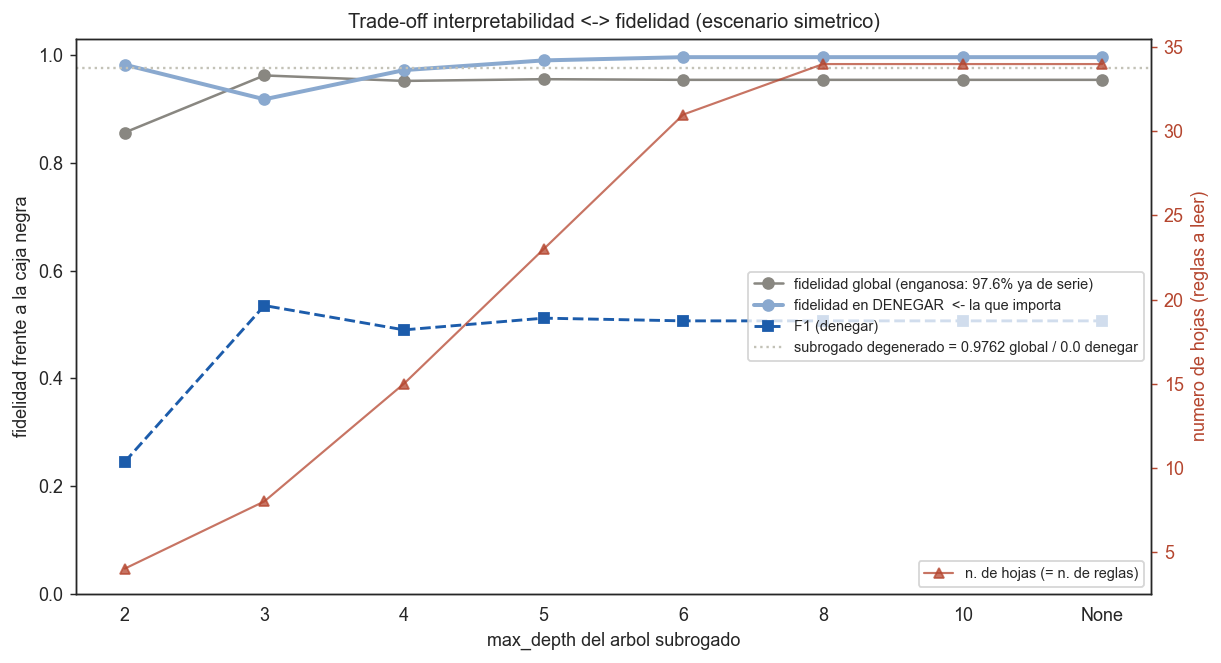

In [42]:
fig('sub_05_fidelidad_vs_profundidad_coste1.png')

**Arboles de bolsillo (8 hojas cada uno) -- las dos personalidades de riesgo.** Que mirar: la variable de la raiz de cada arbol. Arriba, coste1 (umbral 0.4934, deniega solo al 2.38% de los solicitantes): la raiz corta por impagos ya consumados (N. impagos 90+ dias), un criterio conservador. Abajo, coste10 (umbral 0.0906, deniega al 18.70%): la raiz corta por utilizacion de credito revolving, una senal de estres temprano, un criterio preventivo. Es el mismo xgboost; solo cambia donde se pone el umbral de coste.

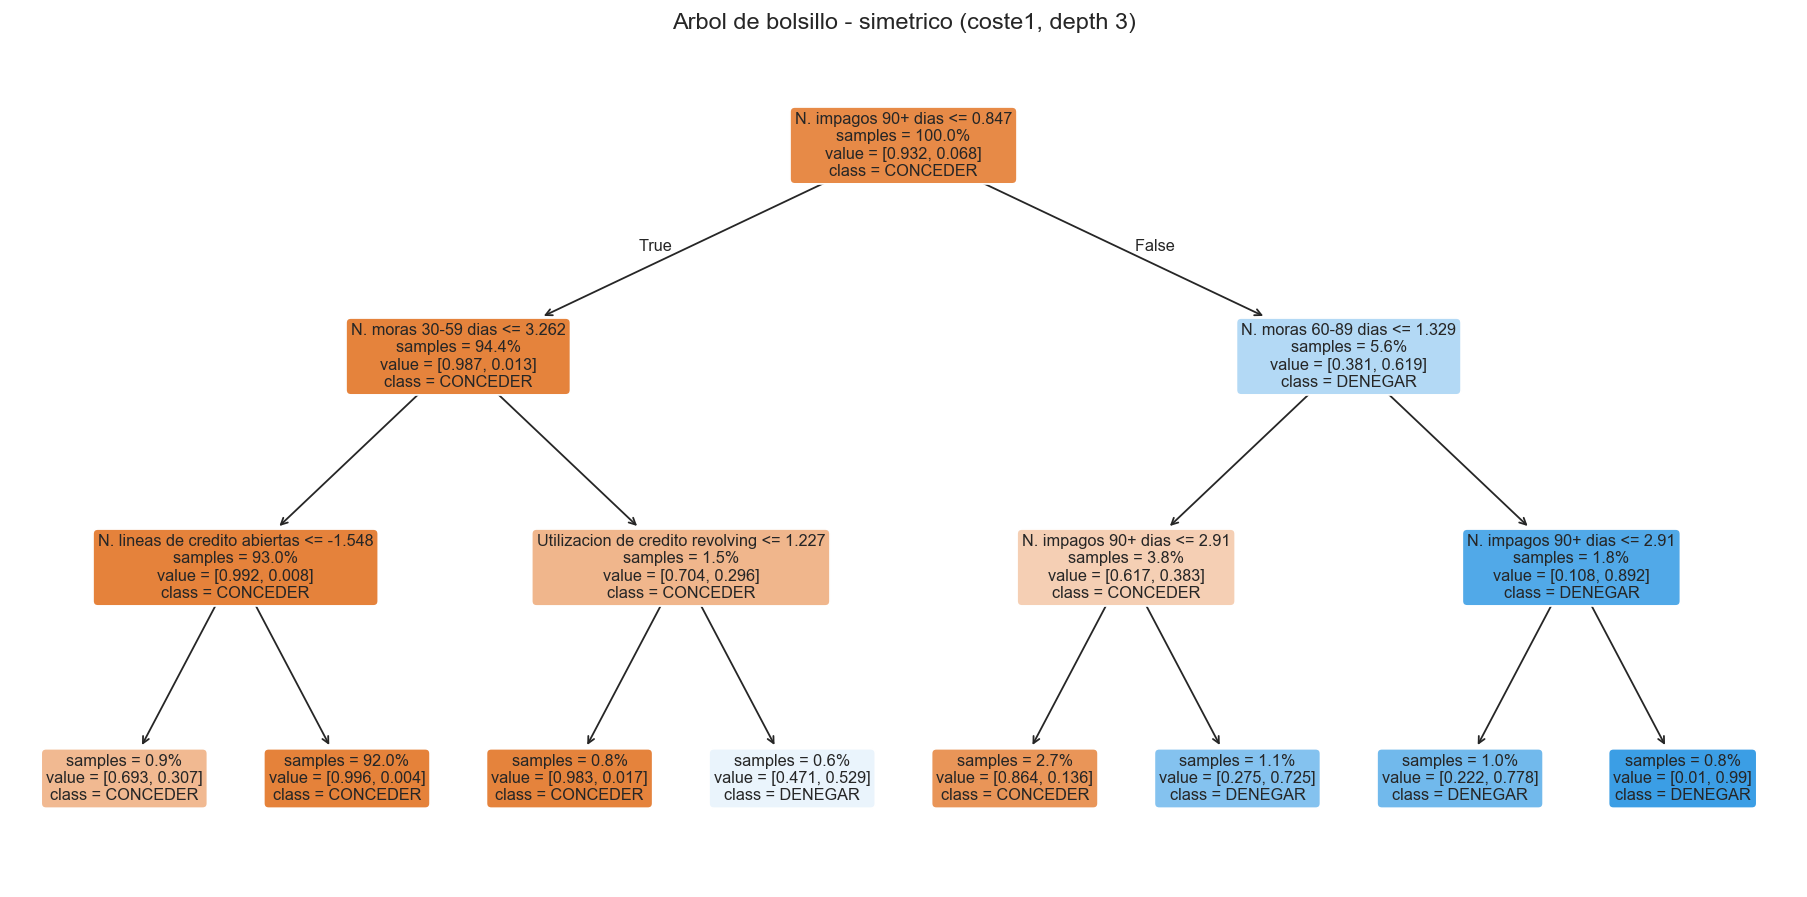

In [43]:
fig('sub_05_arbol_bolsillo_coste1.png')

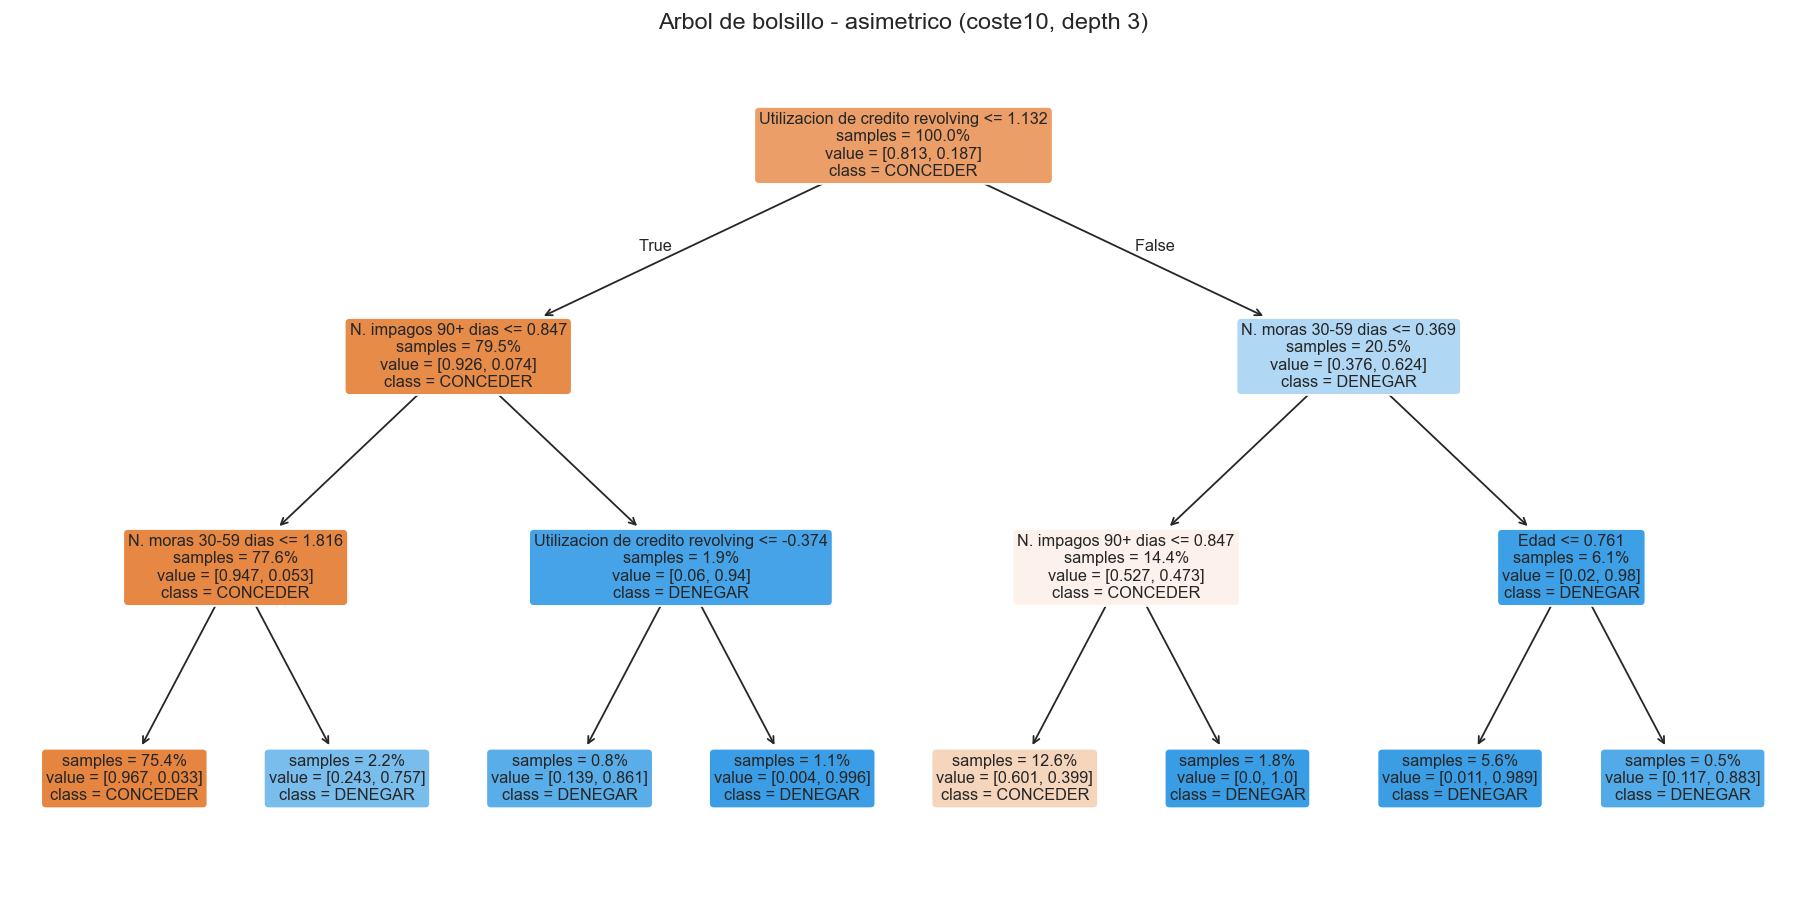

In [44]:
fig('sub_05_arbol_bolsillo_coste10.png')

**Arbol operativo completo (23 hojas, coste10).** Que mirar: con mas profundidad se despliega toda la jerarquia de la variable dominante (utilizacion de credito revolving) combinada con moras y edad -- de estas ramas salen, una por una, las reglas de denegacion legibles que se listan mas abajo.

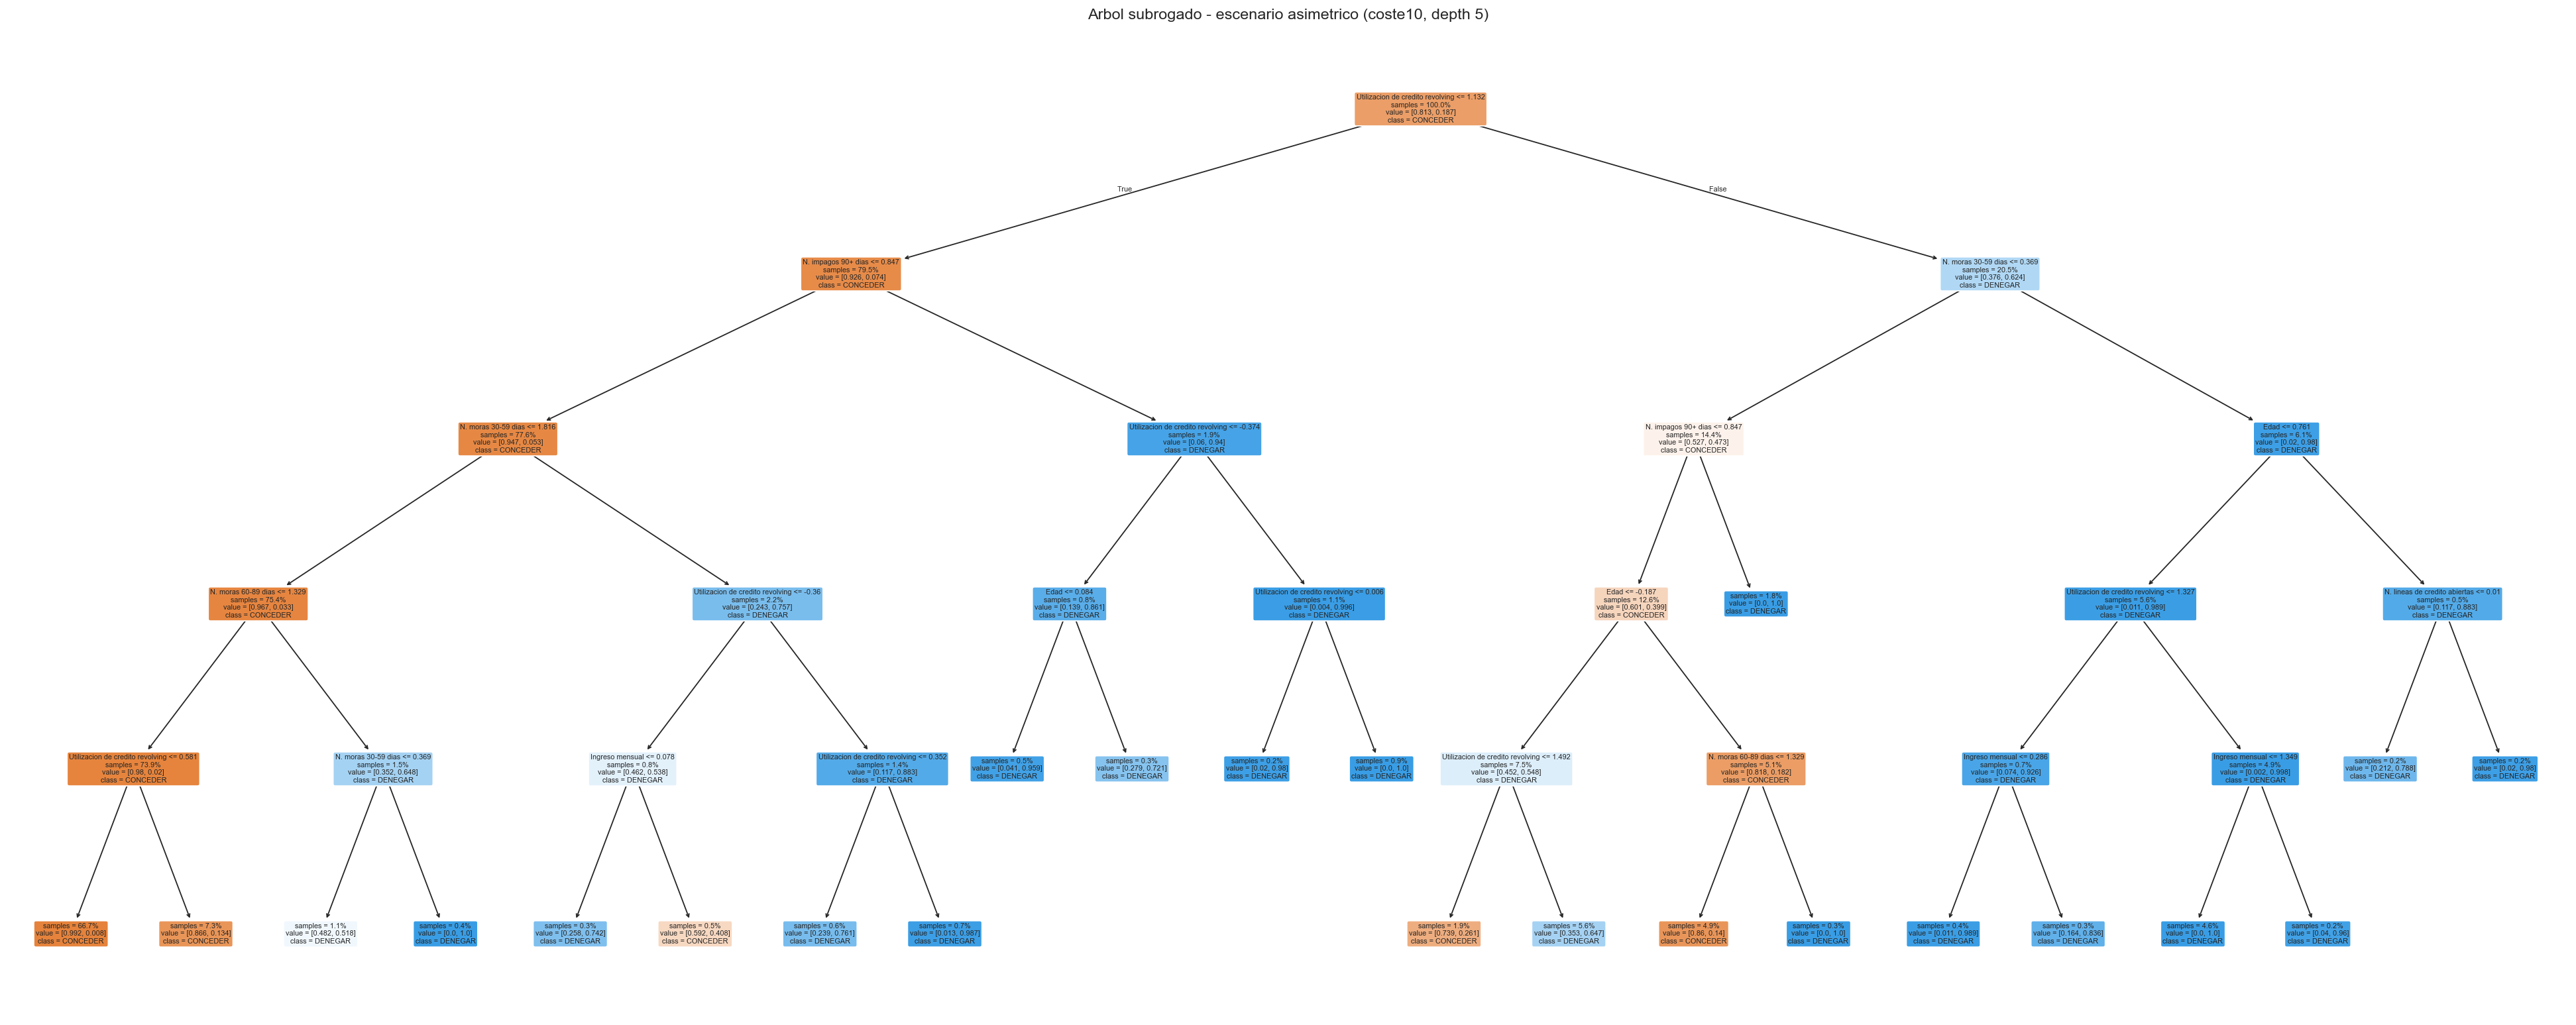

In [45]:
fig('arbol_subrogado_coste10.png')

**Fidelidad global vs clase rara, los 4 subrogados fijados.** Que mirar: la columna deny_subrogado frente a deny_caja_negra (deben parecerse, es el chequeo de sanidad) y la caida de fid_denegar del operativo al bolsillo en cada escenario.

In [46]:
cols = ['subrogado', 'n_hojas', 'deny_caja_negra', 'deny_subrogado', 'fidelidad_global', 'fid_denegar', 'f1_denegar']
print(tabla('sub_05_fidelidad.csv')[cols].round(4).to_string(index=False))

             subrogado  n_hojas  deny_caja_negra  deny_subrogado  fidelidad_global  fid_denegar  f1_denegar
 coste1 operativo (d5)       23           0.0238          0.0259            0.9879       0.7896      0.7562
  coste1 bolsillo (d3)        8           0.0238          0.0353            0.9809       0.8397      0.6758
coste10 operativo (d5)       23           0.1870          0.1876            0.9415       0.8454      0.8439
 coste10 bolsillo (d3)        8           0.1870          0.1196            0.9173       0.5988      0.7304


**Importancia de variables en cada subrogado.** Que mirar: la fila que encabeza cada columna -- es distinta entre imp_coste1 e imp_coste10, ahi esta el nucleo de las dos personalidades de riesgo.

In [47]:
imp = tabla('sub_05_importancia_variables.csv').round(4)
print(imp.sort_values('imp_coste1', ascending=False).to_string(index=False))

                        variable  imp_coste1  imp_coste10
             N. impagos 90+ dias      0.7155       0.1875
             N. moras 60-89 dias      0.1219       0.0685
             N. moras 30-59 dias      0.0734       0.2105
Utilizacion de credito revolving      0.0397       0.4914
   N. lineas de credito abiertas      0.0208       0.0004
                            Edad      0.0165       0.0392
                  Ratio de deuda      0.0089       0.0000
                 Ingreso mensual      0.0032       0.0024


**Reglas de denegacion destiladas** (ramas del arbol operativo de 23 hojas que terminan en DENEGAR, con umbrales ya en euros, anios y ratios reales):

- Coste1: 8 reglas cubren 543 de las denegaciones de test. La regla top (soporte 118, pureza 100%) deniega si N. impagos 90+ dias es 2 o mas, N. moras 60-89 dias es 2 o mas y la utilizacion de credito revolving supera 91%.
- Coste10: 18 reglas cubren 3940 de las denegaciones de test. La regla top (soporte 975, pureza 100%) deniega si la utilizacion de credito revolving supera 77%, N. moras 30-59 dias es 2 o mas, la edad es 63.5 anios o menos y el ingreso mensual es 12506.50 EUR o menos.
- Interaccion Edad x mora, visible dentro de las reglas de coste1: a igual perfil de impagos 90+ (2 o mas) y moras 60-89 (1 o menos) con moras 30-59 dias en 2 o mas, el corte de edad separa el riesgo -- Edad > 43.5 anios da pureza 75.0% (soporte 58) frente a Edad <= 43.5 anios con pureza 98.0% (soporte 53); esta interaccion Edad x mora se corrobora de forma independiente con el PDP 2D de la seccion 11 de este notebook.

**Hallazgos:**

- La fidelidad global engana bajo desbalanceo: en coste1 el arbol degenerado 'conceder siempre' llega a 0.9762 de fidelidad global con fid_denegar=0.0000 (no aprendio nada de cuando se deniega); el operativo real sube el global a 0.9879 Y ademas fid_denegar a 0.7896 (F1-denegar=0.7562) -- hay que mirar siempre la clase rara, nunca el global aislado.
- El peso optimo de la clase 'denegar' depende del escenario: 3 en coste1 (clase rara, 2.38% de denegaciones) frente a sin reponderar en coste10 (clase frecuente, 18.70%); en ambos casos el operativo reproduce casi exacta la tasa de denegacion real de la caja negra (2.59% vs 2.38% en coste1; 18.76% vs 18.70% en coste10), un chequeo de sanidad independiente del F1.
- Dos personalidades de riesgo: la variable mas importante se invierte entre escenarios. En coste1 domina N. impagos 90+ dias (importancia 0.7155) -- un modelo conservador que solo deniega ante mora ya consumada. En coste10 domina utilizacion de credito revolving (importancia 0.4914) -- un modelo preventivo que deniega ante la primera senal de estres; N. impagos 90+ dias cae al tercer puesto (0.1875). Mismo xgboost, misma pareja de arboles, logica de decision opuesta segun donde se fija el umbral de coste.
- El bolsillo (8 reglas) tiene F1 mas bajo en coste1 (0.6758) que en coste10 (0.7304), pero por cobertura el orden se invierte: cubre el 83.97% de las denegaciones reales en coste1 frente a solo el 59.88% en coste10. El bolsillo asimetrico es muy preciso (93.6% de precision) pero le falta profundidad -- 8 hojas son un techo estructural que en coste10 deja fuera a 4 de cada 10 denegaciones.
- La brecha operativo-bolsillo en F1 es mayor en coste10 (0.8439 vs 0.7304, -0.11) que en coste1 (0.7562 vs 0.6758, -0.08): con mas denegaciones que cubrir (18.70% vs 2.38%), 8 reglas se quedan cortas antes.

Nota de reproducibilidad: al recargar el xgboost guardado (.joblib) con una version de la libreria distinta a la del entrenamiento, el base_score interno se reconstruia mal e inflaba las probabilidades x5 (denegaria al 25%/85% en vez del 2.4%/18.7% real); se detecto y corrigio fijando la version exacta de xgboost en las dependencias antes de esta auditoria, garantizando que las cifras de arriba correspondan al modelo realmente entrenado.

## 9. Auditoria: analisis de contrafactuales

Se seleccionan 8 solicitudes denegadas (2 por clase real x 2 escenarios de coste: coste1 con umbral 0.4934, coste10 con umbral 0.0906), etiquetadas como borde_umbral (la mas cercana al umbral) o denegacion_fuerte (proba_impago mas alta). Para cada una se busca con DiCE un contrafactual accionable usando un modelo adaptador que traslada la frontera interna de DiCE (fijada en 0.5) al umbral de negocio real de cada escenario, de modo que la busqueda respeta la decision que realmente aplica el banco.

La busqueda se restringe a 4 variables accionables (utilizacion de credito revolving, ratio de deuda, ingresos mensuales y numero de lineas de credito abiertas) con limites de cambio realistas por solicitante: ingresos hasta +25%, revolving y DebtRatio hasta -30%, cierre de hasta dos lineas de credito. El resto de variables (edad, historial de impagos, personas dependientes...) queda fijo. Cada candidato pasa 6 comprobaciones (rango observado, ausencia de negativos, inmutables sin cambios, direccion favorable, conteos enteros y decision realmente invertida) antes de traducirse a una frase para el cliente.

Distincion importante segun la clase real del solicitante: si en realidad no habria impagado (falso positivo del modelo), el contrafactual es una explicacion literal que se le puede comunicar. Si el modelo acerto al denegar, el contrafactual tiene valor de auditoria interna del comportamiento del modelo y no debe presentarse como promesa de aprobacion.

**Resultado clave:** contrafactual generado en los 4 casos borde_umbral (4/4); en los 4 de denegacion_fuerte, ninguno (0/4). De los 4 generados, 3 son plausibles: 2/2 en coste1 y 1/2 en coste10.

In [48]:
# === Codigo real de la Seccion 09 (fuente: notebooks/06_contrafactuals.ipynb;
#     dice_ml (NO INSTALADO -> el codigo real de DiCE va en try/except ImportError)) ===
# Auditoria por contrafactuales: para un cliente DENEGADO, que habria bastado
# cambiar (variables accionables) para invertir la decision del modelo.
import joblib

RANDOM_STATE = 42
TARGET = "SeriousDlqin2yrs"
N_POR_CLASE = 2   # 2 casos por clase real y por escenario -> 8 casos

# --- Artefactos (no se reentrena nada; se reutilizan los .joblib/.parquet) ---
test    = pd.read_parquet(ROOT / "data" / "processed" / "test.parquet")
X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET].astype(int)
pipeline       = joblib.load(ROOT / "results" / "models" / "preprocessing_pipeline.joblib")
bundle_coste1  = joblib.load(ROOT / "results" / "models" / "modelo_coste1.joblib")
bundle_coste10 = joblib.load(ROOT / "results" / "models" / "modelo_coste10.joblib")

# ==========================================================================
# 1) SELECCION de 8 solicitudes denegadas: 2 por clase real x 2 escenarios.
#    Por par: 'borde_umbral' (proba mas cercana al umbral, cambio pequeno) y
#    'denegacion_fuerte' (proba mas alta). Umbrales de negocio: 0.4934 (coste1)
#    y 0.0906 (coste10). Decision dura con cu.aplicar_umbral (operador estricto).
# ==========================================================================
def predicciones_escenario(bundle, escenario):
    feats = list(bundle["features"])
    proba = bundle["modelo"].predict_proba(X_test.loc[:, feats])[:, 1]
    pred  = cu.aplicar_umbral(proba, bundle["umbral"])      # 1 = denegar, 0 = conceder
    return pd.DataFrame({
        "id_test": X_test.index.to_numpy(),
        "escenario": escenario,
        "clase_real": y_test.to_numpy(),
        "proba_impago": proba,
        "umbral": float(bundle["umbral"]),
        "decision_modelo": pred,
    })

def resumen_decisiones(df):
    return (df.assign(decision=np.where(df["decision_modelo"].eq(1), "denegar", "conceder"))
              .groupby(["escenario", "clase_real", "decision"], as_index=False)
              .size().rename(columns={"size": "n_casos_test"}))

def seleccionar_denegados(df_esc, clase_real, n=2):
    cand = df_esc[(df_esc["clase_real"].eq(clase_real))
                  & (df_esc["decision_modelo"].eq(1))].copy()
    cand["distancia_umbral"] = (cand["proba_impago"] - cand["umbral"]).abs()
    borde = cand.sort_values(["distancia_umbral", "id_test"]).iloc[0]        # el mas cercano
    resto = cand.drop(index=borde.name)
    if resto.empty:
        resto = cand
    fuerte = resto.sort_values(["proba_impago", "id_test"],
                               ascending=[False, True]).iloc[0]              # el mas denegado
    return [{**borde.to_dict(),  "tipo_caso": "borde_umbral"},
            {**fuerte.to_dict(), "tipo_caso": "denegacion_fuerte"}][:n]

filas, resumenes = [], []
for bundle, esc in [(bundle_coste1, "coste1"), (bundle_coste10, "coste10")]:
    pred = predicciones_escenario(bundle, esc)
    resumenes.append(resumen_decisiones(pred))
    for clase_real in (0, 1):
        filas.extend(seleccionar_denegados(pred, clase_real, N_POR_CLASE))

resumen_seleccion = pd.concat(resumenes, ignore_index=True)
casos_meta = pd.DataFrame(filas).reset_index(drop=True)
casos_meta["margen_sobre_umbral"] = casos_meta["proba_impago"] - casos_meta["umbral"]
# Traduccion de las 8 filas a unidades originales (variables accionables legibles).
orig8 = pipeline.inverse_transform(X_test.loc[casos_meta["id_test"]]).reset_index(drop=True)
casos_seleccionados = pd.concat([casos_meta, orig8], axis=1)

print("Decisiones del modelo por escenario/clase (fuente contrafactuals_resumen_seleccion.csv):")
print(resumen_seleccion.to_string(index=False))
print("\n8 casos seleccionados (2 por clase x 2 escenarios de coste):")
print(casos_seleccionados[["id_test", "escenario", "clase_real", "tipo_caso",
                           "proba_impago", "umbral"]].round(4).to_string(index=False))

# Cotejo: los 8 ids/proba reproducidos coinciden con la tabla canonica guardada.
_canon = pd.read_csv(ROOT / "results" / "tables" / "contrafactuals_casos_seleccionados.csv")
_m = casos_seleccionados.merge(
        _canon[["id_test", "escenario", "tipo_caso", "proba_impago"]],
        on=["id_test", "escenario", "tipo_caso"], suffixes=("", "_canon"))
print("\nCotejo seleccion vs tabla guardada:",
      "OK" if (len(_m) == 8 and np.allclose(_m["proba_impago"], _m["proba_impago_canon"], atol=1e-4))
      else "REVISAR", f"({len(_m)}/8 casos)")

# ==========================================================================
# 2) GENERACION de contrafactuales con DiCE. dice_ml NO esta instalado
#    en este entorno -> el codigo REAL de DiCE va DENTRO de try/except ImportError;
#    en el except se recupera la salida ya generada (contrafactuals_ejemplos.csv).
#    Idea clave: un adaptador traslada la frontera interna de DiCE (0.5) al umbral
#    de negocio real, de modo que el CF invierte la decision que aplica el banco.
# ==========================================================================
FEATURES_ACCIONABLES = ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio",
                        "MonthlyIncome", "NumberOfOpenCreditLinesAndLoans"]
FEATURES_INMUTABLES  = [c for c in X_test.columns if c not in FEATURES_ACCIONABLES]
# Limites de accionabilidad proporcionados al solicitante.
MAX_AUMENTO_INCOME, MAX_REDUCCION_REVOLVING = 0.25, 0.30
MAX_REDUCCION_DEBTRATIO, MAX_CIERRE_LINEAS  = 0.30, 4

try:
    import dice_ml
    from raiutils.exceptions import UserConfigValidationException

    X_test_original = pipeline.inverse_transform(X_test)
    rangos_orig = pd.DataFrame({"min_observado": X_test_original.min(),
                                "max_observado": X_test_original.max()})

    class ModeloDiCEConUmbral:
        # Transformacion monotona que situa q=0.5 justo cuando p=t (umbral real).
        def __init__(self, bundle):
            self.modelo = bundle["modelo"]; self.features = list(bundle["features"])
            self.umbral = float(bundle["umbral"])
        def predict_proba(self, X):
            if not isinstance(X, pd.DataFrame):
                X = pd.DataFrame(X, columns=self.features)
            p = self.modelo.predict_proba(X.loc[:, self.features])[:, 1]
            t = self.umbral
            q = np.where(p <= t, 0.5 * p / t, 0.5 + 0.5 * (p - t) / (1 - t))
            return np.column_stack([1 - q, q])

    referencia = X_test.copy(); referencia[TARGET] = y_test.to_numpy()
    datos_dice = dice_ml.Data(dataframe=referencia,
                              continuous_features=list(X_test.columns),
                              outcome_name=TARGET)

    def valor_original_a_procesado(feature, valor_original):
        # De unidades originales a la escala estandarizada del modelo (log1p + StandardScaler).
        idx = pipeline.COLUMNAS_FEATURES.index(feature)
        v = float(valor_original)
        if feature in pipeline.COLS_LOG:
            v = np.log1p(max(v, 0))
        if pipeline.escalar and pipeline.scaler_ is not None:
            v = (v - pipeline.scaler_.mean_[idx]) / pipeline.scaler_.scale_[idx]
        return float(v)

    def rangos_accionables_direccionales(query):
        # Rango permitido por variable: reducir revolving/debt hasta 30%, subir income
        # hasta 25%, cerrar hasta 4 lineas; sin salir del rango observado en test.
        o = pipeline.inverse_transform(query).iloc[0]
        rev_min  = max(o["RevolvingUtilizationOfUnsecuredLines"] * (1 - MAX_REDUCCION_REVOLVING),
                       rangos_orig.loc["RevolvingUtilizationOfUnsecuredLines", "min_observado"])
        debt_min = max(o["DebtRatio"] * (1 - MAX_REDUCCION_DEBTRATIO),
                       rangos_orig.loc["DebtRatio", "min_observado"])
        inc_max  = min(o["MonthlyIncome"] * (1 + MAX_AUMENTO_INCOME),
                       rangos_orig.loc["MonthlyIncome", "max_observado"])
        lin_min  = max(o["NumberOfOpenCreditLinesAndLoans"] - MAX_CIERRE_LINEAS,
                       rangos_orig.loc["NumberOfOpenCreditLinesAndLoans", "min_observado"], 0)
        q0 = query.iloc[0]
        return {
            "RevolvingUtilizationOfUnsecuredLines":
                [valor_original_a_procesado("RevolvingUtilizationOfUnsecuredLines", rev_min),
                 float(q0["RevolvingUtilizationOfUnsecuredLines"])],
            "DebtRatio":
                [valor_original_a_procesado("DebtRatio", debt_min), float(q0["DebtRatio"])],
            "MonthlyIncome":
                [float(q0["MonthlyIncome"]),
                 valor_original_a_procesado("MonthlyIncome", inc_max)],
            "NumberOfOpenCreditLinesAndLoans":
                [valor_original_a_procesado("NumberOfOpenCreditLinesAndLoans", lin_min),
                 float(q0["NumberOfOpenCreditLinesAndLoans"])],
        }

    def generar_cf_dice(caso, bundle, semilla):
        feats = list(bundle["features"]); idc = int(caso["id_test"])
        query = X_test.loc[[idc], feats].copy()
        modelo_dice = dice_ml.Model(model=ModeloDiCEConUmbral(bundle),
                                    backend="sklearn", model_type="classifier")
        explainer = dice_ml.Dice(datos_dice, modelo_dice, method="random")
        try:
            res = explainer.generate_counterfactuals(
                query_instances=query, total_CFs=1, desired_class=0,
                features_to_vary=FEATURES_ACCIONABLES,
                permitted_range=rangos_accionables_direccionales(query),
                sample_size=20_000, random_seed=semilla, verbose=False)
            cf_std = res.cf_examples_list[0].final_cfs_df.loc[:, feats].copy()
            proba_cf = float(bundle["modelo"].predict_proba(cf_std)[:, 1][0])
            if int(cu.aplicar_umbral([proba_cf], bundle["umbral"])[0]) != 0:
                raise RuntimeError("DiCE no invirtio la decision con el umbral de negocio.")
            o  = pipeline.inverse_transform(query).iloc[0]
            cf = pipeline.inverse_transform(cf_std).iloc[0]
            fila = {**caso.to_dict(), "estado_cf": "generado",
                    "proba_impago_cf": proba_cf, "decision_cf": 0}
            for f in feats:
                fila[f"delta__{f}"] = float(cf[f] - o[f])
            return fila
        except UserConfigValidationException:
            return {**caso.to_dict(), "estado_cf": "sin_cf_accionable",
                    "proba_impago_cf": np.nan, "decision_cf": np.nan}

    def es_plausible(fila):
        # Plausibilidad: inmutables sin cambios, direccion favorable, conteos enteros
        # y decision invertida bajo el umbral real.
        if fila["estado_cf"] != "generado":
            return False
        inmutables_ok = all(abs(fila.get(f"delta__{f}", 0.0)) <= 1e-6 for f in FEATURES_INMUTABLES)
        dir_ok = (fila["delta__RevolvingUtilizationOfUnsecuredLines"] <= 1e-6
                  and fila["delta__DebtRatio"] <= 1e-6
                  and fila["delta__NumberOfOpenCreditLinesAndLoans"] <= 1e-6
                  and fila["delta__MonthlyIncome"] >= -1e-6)
        conteos_ok = np.isclose(fila["delta__NumberOfOpenCreditLinesAndLoans"],
                                round(fila["delta__NumberOfOpenCreditLinesAndLoans"]), atol=1e-5)
        return bool(inmutables_ok and dir_ok and conteos_ok and fila["decision_cf"] == 0)

    bundles = {"coste1": bundle_coste1, "coste10": bundle_coste10}
    filas_cf = [generar_cf_dice(caso, bundles[caso["escenario"]], RANDOM_STATE + i)
                for i, (_, caso) in enumerate(casos_seleccionados.iterrows())]
    contrafactuals = pd.DataFrame(filas_cf)
    contrafactuals["cf_plausible"] = contrafactuals.apply(es_plausible, axis=1)
    print("\ndice_ml disponible: DiCE ejecutado en vivo sobre los 8 casos.")

except ImportError:
    contrafactuals = pd.read_csv(ROOT / "results" / "tables" / "contrafactuals_ejemplos.csv",
                                 encoding="utf-8-sig")
    print("\ndice_ml NO instalado en este entorno -> se recupera la salida real ya generada "
          "(results/tables/contrafactuals_ejemplos.csv). El codigo de arriba es EL QUE la produjo.")

# ==========================================================================
# 3) RESUMEN cuantitativo (coincide con results/tables/contrafactuals_ejemplos.csv).
#    Solo aparece contrafactual accionable cerca del umbral; en las denegaciones
#    fuertes DiCE no encuentra alternativa dentro de los limites.
# ==========================================================================
cf = contrafactuals.copy()
cf["generado"]  = cf["estado_cf"].eq("generado")
cf["plausible"] = cf["generado"] & cf["cf_plausible"].fillna(False).astype(bool)
print(f"\nCasos analizados: {len(cf)} | CF generados: {int(cf['generado'].sum())} "
      f"| CF plausibles: {int(cf['plausible'].sum())}")
print("\nPor escenario:")
print(cf.groupby("escenario").agg(n=("id_test", "size"), generados=("generado", "sum"),
      plausibles=("plausible", "sum"), proba_orig_media=("proba_impago", "mean"))
      .round(4).to_string())
print("\nPor tipo de caso (solo 'borde_umbral' obtiene CF; 'denegacion_fuerte' 0/4):")
print(cf.groupby("tipo_caso").agg(n=("id_test", "size"), generados=("generado", "sum"),
      plausibles=("plausible", "sum")).to_string())

# ==========================================================================
# 4) RESPUESTA A LA PREGUNTA CENTRAL: que decirle a un cliente denegado.
#    'uso_explicacion' separa el MISMO artefacto en dos lecturas:
#      - clase_real=0 (falso positivo): explicacion comunicable al solicitante.
#      - clase_real=1 (denegacion correcta): solo auditoria interna, no una promesa.
# ==========================================================================
cols_uso = ["id_test", "escenario", "clase_real", "tipo_caso",
            "estado_cf", "cf_plausible", "uso_explicacion"]
print("\nUso del contrafactual (mismo CF, dos interpretaciones):")
print(cf[cols_uso].to_string(index=False))

if "explicacion_cliente" in cf.columns:
    caso_ok  = cf[cf["id_test"].eq(52346)].iloc[0]   # coste1, borde, clase 0 -> CF plausible
    caso_sin = cf[cf["id_test"].eq(28495)].iloc[0]   # coste1, denegacion fuerte -> sin CF
    print("\n[Cliente CON contrafactual plausible] id_test=52346 (falso positivo):")
    print(" ", caso_ok["explicacion_cliente"])
    print("\n[Cliente SIN contrafactual accionable] id_test=28495 (falso positivo):")
    print(" ", caso_sin["explicacion_cliente"])


Decisiones del modelo por escenario/clase (fuente contrafactuals_resumen_seleccion.csv):
escenario  clase_real decision  n_casos_test
   coste1           0 conceder         19383
   coste1           0  denegar           213
   coste1           1 conceder          1118
   coste1           1  denegar           286
  coste10           0 conceder         16678
  coste10           0  denegar          2918
  coste10           1 conceder           396
  coste10           1  denegar          1008

8 casos seleccionados (2 por clase x 2 escenarios de coste):
 id_test escenario  clase_real         tipo_caso  proba_impago  umbral
   52346    coste1           0      borde_umbral        0.4935  0.4934
   28495    coste1           0 denegacion_fuerte        0.8333  0.4934
   10358    coste1           1      borde_umbral        0.4936  0.4934
   79585    coste1           1 denegacion_fuerte        0.9169  0.4934
   19744   coste10           0      borde_umbral        0.0906  0.0906
   28495   coste10

**Que mirar:** la figura solo representa los 3 casos con contrafactual generado y plausible (2 puntos en el panel coste1, 1 en coste10); no incluye los 4 casos sin contrafactual ni el caso generado pero descartado por implausible.

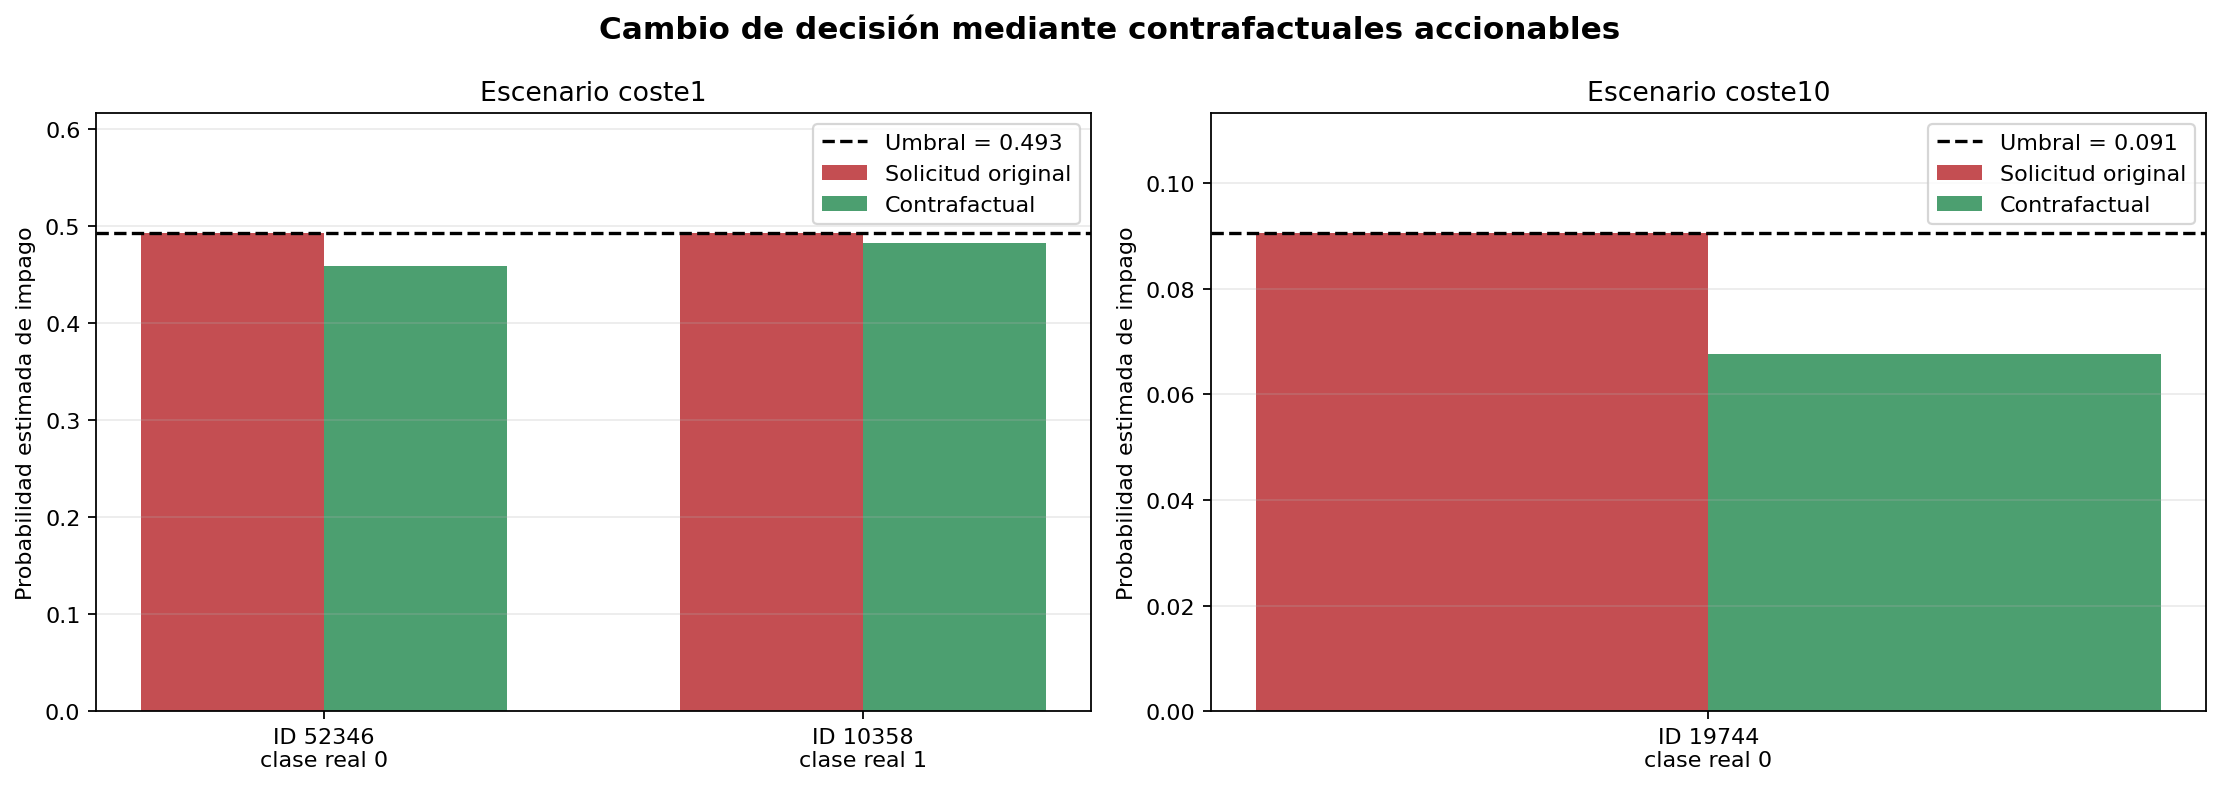

In [49]:
fig('contrafactuals_probabilidad_original_vs_cf.png')

In [50]:
cols = ['id_test', 'escenario', 'clase_real', 'tipo_caso', 'estado_cf', 'cf_plausible', 'uso_explicacion']
df_cf = tabla('contrafactuals_ejemplos.csv')
print(df_cf[cols].to_string(index=False))

 id_test escenario  clase_real         tipo_caso         estado_cf  cf_plausible                       uso_explicacion
   52346    coste1           0      borde_umbral          generado          True    explicacion_cliente_falso_positivo
   28495    coste1           0 denegacion_fuerte sin_cf_accionable         False    explicacion_cliente_falso_positivo
   10358    coste1           1      borde_umbral          generado          True auditoria_interna_denegacion_correcta
   79585    coste1           1 denegacion_fuerte sin_cf_accionable         False auditoria_interna_denegacion_correcta
   19744   coste10           0      borde_umbral          generado          True    explicacion_cliente_falso_positivo
   28495   coste10           0 denegacion_fuerte sin_cf_accionable         False    explicacion_cliente_falso_positivo
   14183   coste10           1      borde_umbral          generado         False auditoria_interna_denegacion_correcta
   79585   coste10           1 denegacion_fuerte

**Que mirar:** `uso_explicacion` distingue los dos usos posibles del mismo contrafactual: `explicacion_cliente_falso_positivo` (clase_real=0, se le puede comunicar al solicitante) frente a `auditoria_interna_denegacion_correcta` (clase_real=1, solo sirve para auditar el modelo, no como promesa).

In [51]:
resumen = df_cf.groupby('escenario').agg(
    proba_impago_media=('proba_impago', 'mean'),
    generados=('estado_cf', lambda s: (s == 'generado').sum()),
    plausibles=('cf_plausible', 'sum'),
).round(4)
print(resumen)

           proba_impago_media  generados  plausibles
escenario                                           
coste1                 0.6843          2           2
coste10                0.4829          2           1


**Que mirar:** proba_impago_media resume que tan lejos del umbral estan en promedio los 4 casos de cada escenario (0.6843 en coste1 vs 0.4829 en coste10, casos mas cerca del umbral en terminos relativos); generados/plausibles confirma el 4/4 vs 0/4 y el 3 de 4 plausibles por escenario (2/2 y 1/2).

In [52]:
caso_ok = df_cf[df_cf['id_test'] == 52346].iloc[0]
caso_sin = df_cf[df_cf['id_test'] == 28495].iloc[0]
print('--- Con contrafactual plausible: que se le dice al cliente ---')
print(f"id_test=52346, coste1, borde_umbral, clase_real=0 (falso positivo)")
print(caso_ok['explicacion_cliente'])
print()
print('--- Sin contrafactual accionable: que se le dice al cliente ---')
print(f"id_test=28495, coste1, denegacion_fuerte, clase_real=0 (falso positivo)")
print(caso_sin['explicacion_cliente'])

--- Con contrafactual plausible: que se le dice al cliente ---
id_test=52346, coste1, borde_umbral, clase_real=0 (falso positivo)
La solicitud fue denegada porque el riesgo estimado por el modelo era del 49.4%, por encima del límite de 49.3% aplicado en este escenario. Según la simulación, habría bastado con reducir la utilización de sus líneas de crédito de 110.3% a 109.3% y aumentar sus ingresos mensuales aproximadamente de 4.720 € a 5.863 €. Con esos cambios, el riesgo estimado habría descendido al 45.9% y la decisión del modelo habría sido conceder el crédito. Esta explicación describe el comportamiento del modelo y no constituye una garantía de aprobación futura.

--- Sin contrafactual accionable: que se le dice al cliente ---
id_test=28495, coste1, denegacion_fuerte, clase_real=0 (falso positivo)
La solicitud fue denegada porque el nivel de riesgo estimado superaba el límite utilizado en este escenario. No se encontró una combinación razonable de cambios en los factores económico

**Respuesta a la pregunta central (que decirle a un cliente denegado):** cuando hay contrafactual plausible (caso 52346), se le explican los cambios concretos que habrian revertido la decision (bajar revolving de 110.3% a 109.3% y subir ingresos de 4.720 EUR a 5.863 EUR, riesgo final 45.9%), siempre aclarando que es una lectura del comportamiento del modelo y no una garantia de aprobacion futura. Cuando no lo hay (caso 28495, proba_impago=0.833 muy por encima del umbral 0.493), se le dice con honestidad que no se hallo una alternativa razonable variando solo las 4 variables accionables dentro de los limites establecidos, sin afirmar que la aprobacion sea imposible en el futuro.

**Otros ejemplos que ilustran matices del metodo:**
1 Caso 10358 (coste1, borde_umbral, clase_real=1, correctamente denegado): riesgo 49.4% vs limite 49.3%; subiendo solo los ingresos de 2.697 EUR a 3.120 EUR (una sola variable) el riesgo baja a 48.3% y se revierte la decision. Al ser clase_real=1, este contrafactual es auditoria interna, no una recomendacion para el cliente.
2 Caso 19744 (coste10, borde_umbral, clase_real=0): riesgo 9.1% vs limite 9.1%; bajando revolving de 100.0% a 70.7% el riesgo cae a 6.8%. Ilustra el escenario coste10, mas conservador (umbral 0.0906).
3 Caso 14183 (coste10, borde_umbral, clase_real=1): DiCE encuentra tecnicamente una alternativa (DebtRatio 1.283 a 0.908 y lineas de credito de 12 a 8, riesgo 9.1% a 6.5%) pero se descarta por implausible: el valor interno del contrafactual para el numero de lineas es fraccionario, no un entero valido. El texto de cliente ya redondeado (12 a 8) se genera igualmente porque el codigo condiciona el texto a que exista un contrafactual generado, no a que sea plausible; por eso este caso no deberia usarse como explicacion real pese a tener un texto aparentemente correcto.

**Hallazgos:**

1 Solo hay contrafactual accionable en casos borde_umbral (4/4 generados); en denegacion_fuerte, 0/4. La distancia al umbral condiciona por completo si existe una explicacion accionable, no la clase real del solicitante.
2 De los 4 generados, 3 son plausibles: 2/2 en coste1 y 1/2 en coste10. El unico descartado (id_test=14183, coste10) falla por conteo no entero en NumberOfOpenCreditLinesAndLoans.
3 Los limites de accionabilidad usados por DiCE son concretos: ingresos hasta +25%, revolving y DebtRatio hasta -30%, cierre de hasta dos lineas de credito; el resto de variables (edad, impagos previos, personas dependientes) permanece fijo.
4 La proba_impago media de los 8 casos seleccionados es 0.6843 en coste1 y 0.4829 en coste10: en ambos escenarios se mezclan casos muy cerca del umbral (borde_umbral) con otros muy por encima (denegacion_fuerte).
5 Caso 52346 (coste1, plausible, clase_real=0): riesgo estimado 49.4% vs limite 49.3%; bajando revolving de 110.3% a 109.3% y subiendo ingresos de 4.720 EUR a 5.863 EUR, el riesgo cae a 45.9% y se revierte la decision.
6 Caso 28495 (denegacion_fuerte en ambos escenarios, clase_real=0): proba_impago=0.833 muy por encima de los dos umbrales; la explicacion reconoce con honestidad que no se hallo alternativa valida bajo las restricciones, sin afirmar que la aprobacion sea imposible. Caso 79585 (denegacion_fuerte, clase_real=1): proba_impago=0.917, tampoco hay contrafactual en ninguno de los dos escenarios.
7 La distincion `uso_explicacion` (explicacion_cliente_falso_positivo vs auditoria_interna_denegacion_correcta) marca si el contrafactual se puede comunicar como explicacion al cliente o si solo sirve para auditar internamente el modelo: con clase_real=1 (correctamente denegado) nunca deberia presentarse como promesa de aprobacion, aunque el contrafactual exista y sea plausible.

## 10. Auditoria: analisis SHAP global y local (+ cotejo con LIME)

Se aplica TreeExplainer de la libreria SHAP -- el explicador exacto y rapido pensado para modelos de arboles como el XGBoost elegido en este proyecto -- para calcular la contribucion de cada variable a la puntuacion de riesgo sobre las 21.000 observaciones de test. Se hace por separado para el escenario simetrico (modelo_coste1) y el asimetrico (modelo_coste10), aunque ambos comparten el mismo XGBoost entrenado y solo difieren en el umbral que convierte esa puntuacion en decision. Nota tecnica: los valores SHAP de un XGBoost son aditivos en escala log-odds (margen del modelo), no en probabilidad directa; util para no confundir las magnitudes del waterfall con probabilidades al leerlas junto a los umbrales de decision.

Con esos valores se construye un resumen global (importancia media absoluta por variable) y explicaciones locales tipo waterfall para casos individuales denegados, incluido uno de borde (justo por encima del umbral). Ademas, de forma independiente, se coteja la fiabilidad de SHAP frente a LIME: sobre 6 clientes denegados (3 por escenario, seleccionados aparte de los casos usados en las figuras locales y en la auditoria de contrafactuales de la seccion 6) se reejecuta LIME seis veces por caso para medir cuanto varia el peso que asigna a cada variable, se contrasta con la varianza nula de SHAP -- que al ser exacto da siempre el mismo resultado -- y se mide el acuerdo entre los rankings de variables de ambos metodos con el coeficiente de correlacion de Spearman en valor absoluto.

In [53]:
# === Codigo real de la Seccion 10 (fuente: notebooks/07_shap.ipynb (y el cotejo
#     LIME-vs-SHAP de notebooks/08_otras_tecnicas.ipynb); shap (INSTALADO), src/xai_utils.py) ===
import joblib
import shap
from scipy.stats import spearmanr
import src.xai_utils as xu   # funciones puras; NO importa lime a nivel de modulo

RANDOM_STATE = 42
TARGET = "SeriousDlqin2yrs"

# --- Carga autocontenida de artefactos ya entrenados (no se reentrena nada) ---
bundle1 = joblib.load(ROOT / "results" / "models" / "modelo_coste1.joblib")
bundle10 = joblib.load(ROOT / "results" / "models" / "modelo_coste10.joblib")
test = pd.read_parquet(ROOT / "data" / "processed" / "test.parquet")
train = pd.read_parquet(ROOT / "data" / "processed" / "train.parquet")

FEATURES = list(bundle1["features"])          # 12 columnas, orden canonico del contrato
X_test = test[FEATURES].copy()
y_test = test[TARGET].to_numpy(dtype="int64")
X_train = train[FEATURES].copy()
y_train = train[TARGET].to_numpy(dtype="int64")

modelo1 = bundle1["modelo"]                    # wrapper ModeloBoosted (esc. simetrico)
modelo10 = bundle10["modelo"]                  # wrapper ModeloBoosted (esc. asimetrico)
est1 = modelo1.estimador_                       # XGBClassifier nativo -> TreeExplainer
est10 = modelo10.estimador_

# --- Umbral de decision por escenario: argmin empirico del coste sobre las probas
#     OUT-OF-FOLD de train (mismo umbral que decide en test; NO se recalibra en test,
#     anti-fuga). Reutiliza el oof_proba guardado en el bundle en vez de reentrenar CV. ---
oof = np.asarray(bundle1["supervisado"]["oof_proba"], dtype="float64")
umbral_c1, _ = cu.umbral_optimo(y_train, oof, C1_FP, C1_FN)
umbral_c10, _ = cu.umbral_optimo(y_train, oof, C2_FP, C2_FN)
print(f"Umbral optimo (argmin coste sobre OOF train)  coste1={umbral_c1:.4f}  coste10={umbral_c10:.4f}")
print(f"Umbral guardado en el bundle                  coste1={bundle1['umbral']:.4f}  coste10={bundle10['umbral']:.4f}")

# --- Invariante: el MISMO XGBoost puntua en ambos escenarios; solo cambia el
#     umbral aguas abajo. Por eso SHAP sera identico en coste1 y coste10. ---
proba1 = np.asarray(modelo1.predict_proba(X_test))[:, 1].astype("float64")
proba10 = np.asarray(modelo10.predict_proba(X_test))[:, 1].astype("float64")
print(f"max|proba_c1 - proba_c10| = {np.max(np.abs(proba1 - proba10)):.2e}  (mismo estimador)")

# --- SHAP GLOBAL: TreeExplainer sobre el XGBClassifier nativo, TEST completo (21000 filas).
#     TreeExplainer es exacto y rapido para arboles; salida en escala margen (log-odds),
#     de ahi que las magnitudes locales no sean probabilidades. (~25 s en test completo;
#     se usa test completo a proposito para que mean_abs_shap cuadre con la figura/tabla.) ---
explainer1 = shap.TreeExplainer(est1)
shap_vals1 = np.asarray(explainer1(X_test).values)          # (21000, 12), escala margen
resumen = (pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_vals1).mean(axis=0),
    "mean_shap": shap_vals1.mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False, ignore_index=True))
resumen["ranking"] = np.arange(1, len(resumen) + 1)
print("\nRanking global de importancia SHAP (mean_abs_shap sobre test completo):")
print(resumen[["ranking", "feature", "mean_abs_shap", "mean_shap"]].head(6).round(4).to_string(index=False))
dominancia = resumen.loc[0, "mean_abs_shap"] / resumen.loc[1, "mean_abs_shap"]
print(f"La 1a variable ({resumen.loc[0, 'feature']}) domina: {dominancia:.2f}x la 2a")

# --- El ranking global es IDENTICO en coste10 (mismo estimador): se verifica SHAP en una
#     muestra (n=500, random_state=42) para no repetir el pase completo de 25 s. ---
idx_chk = X_test.sample(500, random_state=RANDOM_STATE).index
pos_chk = X_test.index.get_indexer(idx_chk)
sv1_chk = shap_vals1[pos_chk]
sv10_chk = np.asarray(shap.TreeExplainer(est10)(X_test.loc[idx_chk]).values)
print(f"max|SHAP_c1 - SHAP_c10| (muestra n=500) = {np.max(np.abs(sv1_chk - sv10_chk)):.2e}  -> ranking identico")

# --- Cotejo contra la tabla canonica guardada (shap_values_global.csv) ---
glob_csv = pd.read_csv(TAB / "shap_values_global.csv").query("escenario == 'coste1'")
mabs_csv = glob_csv.set_index("feature")["mean_abs_shap"]
dif_csv = np.max(np.abs(resumen.set_index("feature")["mean_abs_shap"] - mabs_csv))
print(f"max|mean_abs_shap calculado - CSV guardado| = {dif_csv:.2e}")

# --- SHAP LOCAL: casos individuales denegados (el waterfall esta en la figura; aqui los
#     numeros). Rojo = SHAP>0 empuja a IMPAGO (denegar); azul = SHAP<0 empuja a CONCEDER.
#     proba_impago/umbral/margen se toman de la tabla canonica de casos (contrafactuals_
#     ejemplos.csv), la misma de la que salieron las figuras waterfall del notebook 07. ---
casos_cf = pd.read_csv(TAB / "contrafactuals_ejemplos.csv").query("escenario == 'coste1'")
for idc in (52346, 28495):
    ref = casos_cf[casos_cf["id_test"] == idc].iloc[0]
    pos = X_test.index.get_loc(idc)
    sv = shap_vals1[pos]
    orden = np.argsort(np.abs(sv))[::-1]
    proba = float(ref["proba_impago"]); umbral_ref = float(ref["umbral"])
    margen = proba - umbral_ref
    print(f"\nCaso id={idc} ({ref['tipo_caso']}, clase real={int(ref['clase_real'])}): "
          f"proba_impago={proba:.6f}  umbral={umbral_ref:.6f}  margen={margen:+.6f}")
    top = pd.DataFrame({
        "feature": [FEATURES[j] for j in orden[:4]],
        "shap_margen": [sv[j] for j in orden[:4]],
        "empuja_a": ["impago (rojo)" if sv[j] > 0 else "conceder (azul)" for j in orden[:4]],
    })
    print(top.round(4).to_string(index=False))

# --- COTEJO LIME vs SHAP sobre 6 casos denegados (3 por escenario). LIME NO esta instalado
#     en este entorno: el codigo REAL va en el try; el except carga el cotejo ya calculado
#     (results/tables/otras_08_lime_vs_shap*.csv) para que el notebook CORRA igualmente. ---
resumen_cotejo = pd.read_csv(TAB / "otras_08_lime_vs_shap_resumen.csv")
casos_cotejo = [(r["escenario"], int(r["idx_caso"])) for _, r in resumen_cotejo.iterrows()]

try:
    from lime.lime_tabular import LimeTabularExplainer  # fuerza ImportError si lime falta
    filas = []
    for esc, i in casos_cotejo:
        modelo = modelo1 if esc == "coste1" else modelo10
        x = X_test.iloc[i].values                        # idx_caso es posicional (iloc)
        # LIME reejecutado K=6 veces -> peso_medio/peso_std por variable (inestabilidad)
        _, tab_lime = xu.lime_inestabilidad(modelo, x, X_train.values, FEATURES,
                                            k_reejecuciones=6, semilla_base=RANDOM_STATE)
        tab_lime = tab_lime.set_index("variable")
        sv_local = shap_vals1[i]                          # SHAP local (determinista)
        for j, f in enumerate(FEATURES):
            filas.append({"escenario": esc, "idx_caso": i, "variable": f,
                          "lime_peso_medio": float(tab_lime.loc[f, "peso_medio"]),
                          "lime_peso_std": float(tab_lime.loc[f, "peso_std"]),
                          "shap_local": float(sv_local[j]), "shap_std": 0.0})
    cotejo = pd.DataFrame(filas)
    print("\n[LIME instalado] cotejo LIME vs SHAP recalculado en vivo.")
except ImportError:
    cotejo = pd.read_csv(TAB / "otras_08_lime_vs_shap.csv")
    print("\n[lime NO instalado] se carga el cotejo guardado: results/tables/otras_08_lime_vs_shap.csv")

# --- Metricas del cotejo (validas venga de LIME en vivo o del CSV). El SHAP local se
#     RECALCULA aqui desde shap_vals1 (mi TreeExplainer) y se cruza con el guardado. ---
filas_res = []
for esc, i in casos_cotejo:
    sub = cotejo[(cotejo["escenario"] == esc) & (cotejo["idx_caso"] == i)]
    shap_mine = np.array([shap_vals1[i][FEATURES.index(v)] for v in sub["variable"]])
    dif_shap = np.max(np.abs(shap_mine - sub["shap_local"].to_numpy()))
    rho = spearmanr(np.abs(sub["lime_peso_medio"].to_numpy()), np.abs(shap_mine)).correlation
    filas_res.append({"escenario": esc, "idx_caso": i,
                      "lime_std_media": float(sub["lime_peso_std"].mean()),
                      "lime_std_max": float(sub["lime_peso_std"].max()),
                      "shap_std": float(sub["shap_std"].max()),
                      "spearman_abs": float(rho),
                      "dif_shap_vs_guardado": float(dif_shap)})
res_calc = pd.DataFrame(filas_res)
print(res_calc.round(4).to_string(index=False))
print(f"\nSHAP determinista: shap_std maximo en los 6 casos = {res_calc['shap_std'].max():.4f}")
print(f"LIME inestable: lime_std_media media = {res_calc['lime_std_media'].mean():.4f}  "
      f"(hasta {res_calc['lime_std_max'].max():.4f} entre reejecuciones)")
print(f"Acuerdo de ranking LIME-SHAP (Spearman |.|): medio = {res_calc['spearman_abs'].mean():.4f}  "
      f"rango [{res_calc['spearman_abs'].min():.4f}, {res_calc['spearman_abs'].max():.4f}]")
print(f"SHAP local recalculado == guardado: max dif = {res_calc['dif_shap_vs_guardado'].max():.2e}")
print(f"Spearman recalculado == resumen guardado: max dif = "
      f"{np.max(np.abs(res_calc['spearman_abs'].to_numpy() - resumen_cotejo['spearman_abs_lime_shap'].to_numpy())):.2e}")
print(f"El top-1 de LIME coincide con el de SHAP en "
      f"{int(resumen_cotejo['top1_coincide'].sum())}/{len(resumen_cotejo)} casos "
      f"(LIME senala 'es_centinela_pastdue' como la mas inestable, casi irrelevante para SHAP)")


Umbral optimo (argmin coste sobre OOF train)  coste1=0.4934  coste10=0.0906
Umbral guardado en el bundle                  coste1=0.4934  coste10=0.0906


max|proba_c1 - proba_c10| = 0.00e+00  (mismo estimador)



Ranking global de importancia SHAP (mean_abs_shap sobre test completo):
 ranking                              feature  mean_abs_shap  mean_shap
       1 RevolvingUtilizationOfUnsecuredLines         0.7873    -0.3577
       2 NumberOfTime30-59DaysPastDueNotWorse         0.3486    -0.1224
       3              NumberOfTimes90DaysLate         0.3278    -0.1645
       4                                  age         0.2273    -0.0654
       5 NumberOfTime60-89DaysPastDueNotWorse         0.1735    -0.0603
       6      NumberOfOpenCreditLinesAndLoans         0.1592    -0.0158
La 1a variable (RevolvingUtilizationOfUnsecuredLines) domina: 2.26x la 2a


max|SHAP_c1 - SHAP_c10| (muestra n=500) = 0.00e+00  -> ranking identico
max|mean_abs_shap calculado - CSV guardado| = 4.12e-09

Caso id=52346 (borde_umbral, clase real=0): proba_impago=0.493506  umbral=0.493394  margen=+0.000112
                             feature  shap_margen        empuja_a
RevolvingUtilizationOfUnsecuredLines       1.5003   impago (rojo)
NumberOfTime30-59DaysPastDueNotWorse       1.1110   impago (rojo)
             NumberOfTimes90DaysLate      -0.2165 conceder (azul)
                           DebtRatio       0.1596   impago (rojo)

Caso id=28495 (denegacion_fuerte, clase real=0): proba_impago=0.833349  umbral=0.493394  margen=+0.339955
                             feature  shap_margen      empuja_a
             NumberOfTimes90DaysLate       1.4493 impago (rojo)
NumberOfTime60-89DaysPastDueNotWorse       1.3332 impago (rojo)
RevolvingUtilizationOfUnsecuredLines       0.7190 impago (rojo)
NumberOfTime30-59DaysPastDueNotWorse       0.6692 impago (rojo)

[lime NO inst

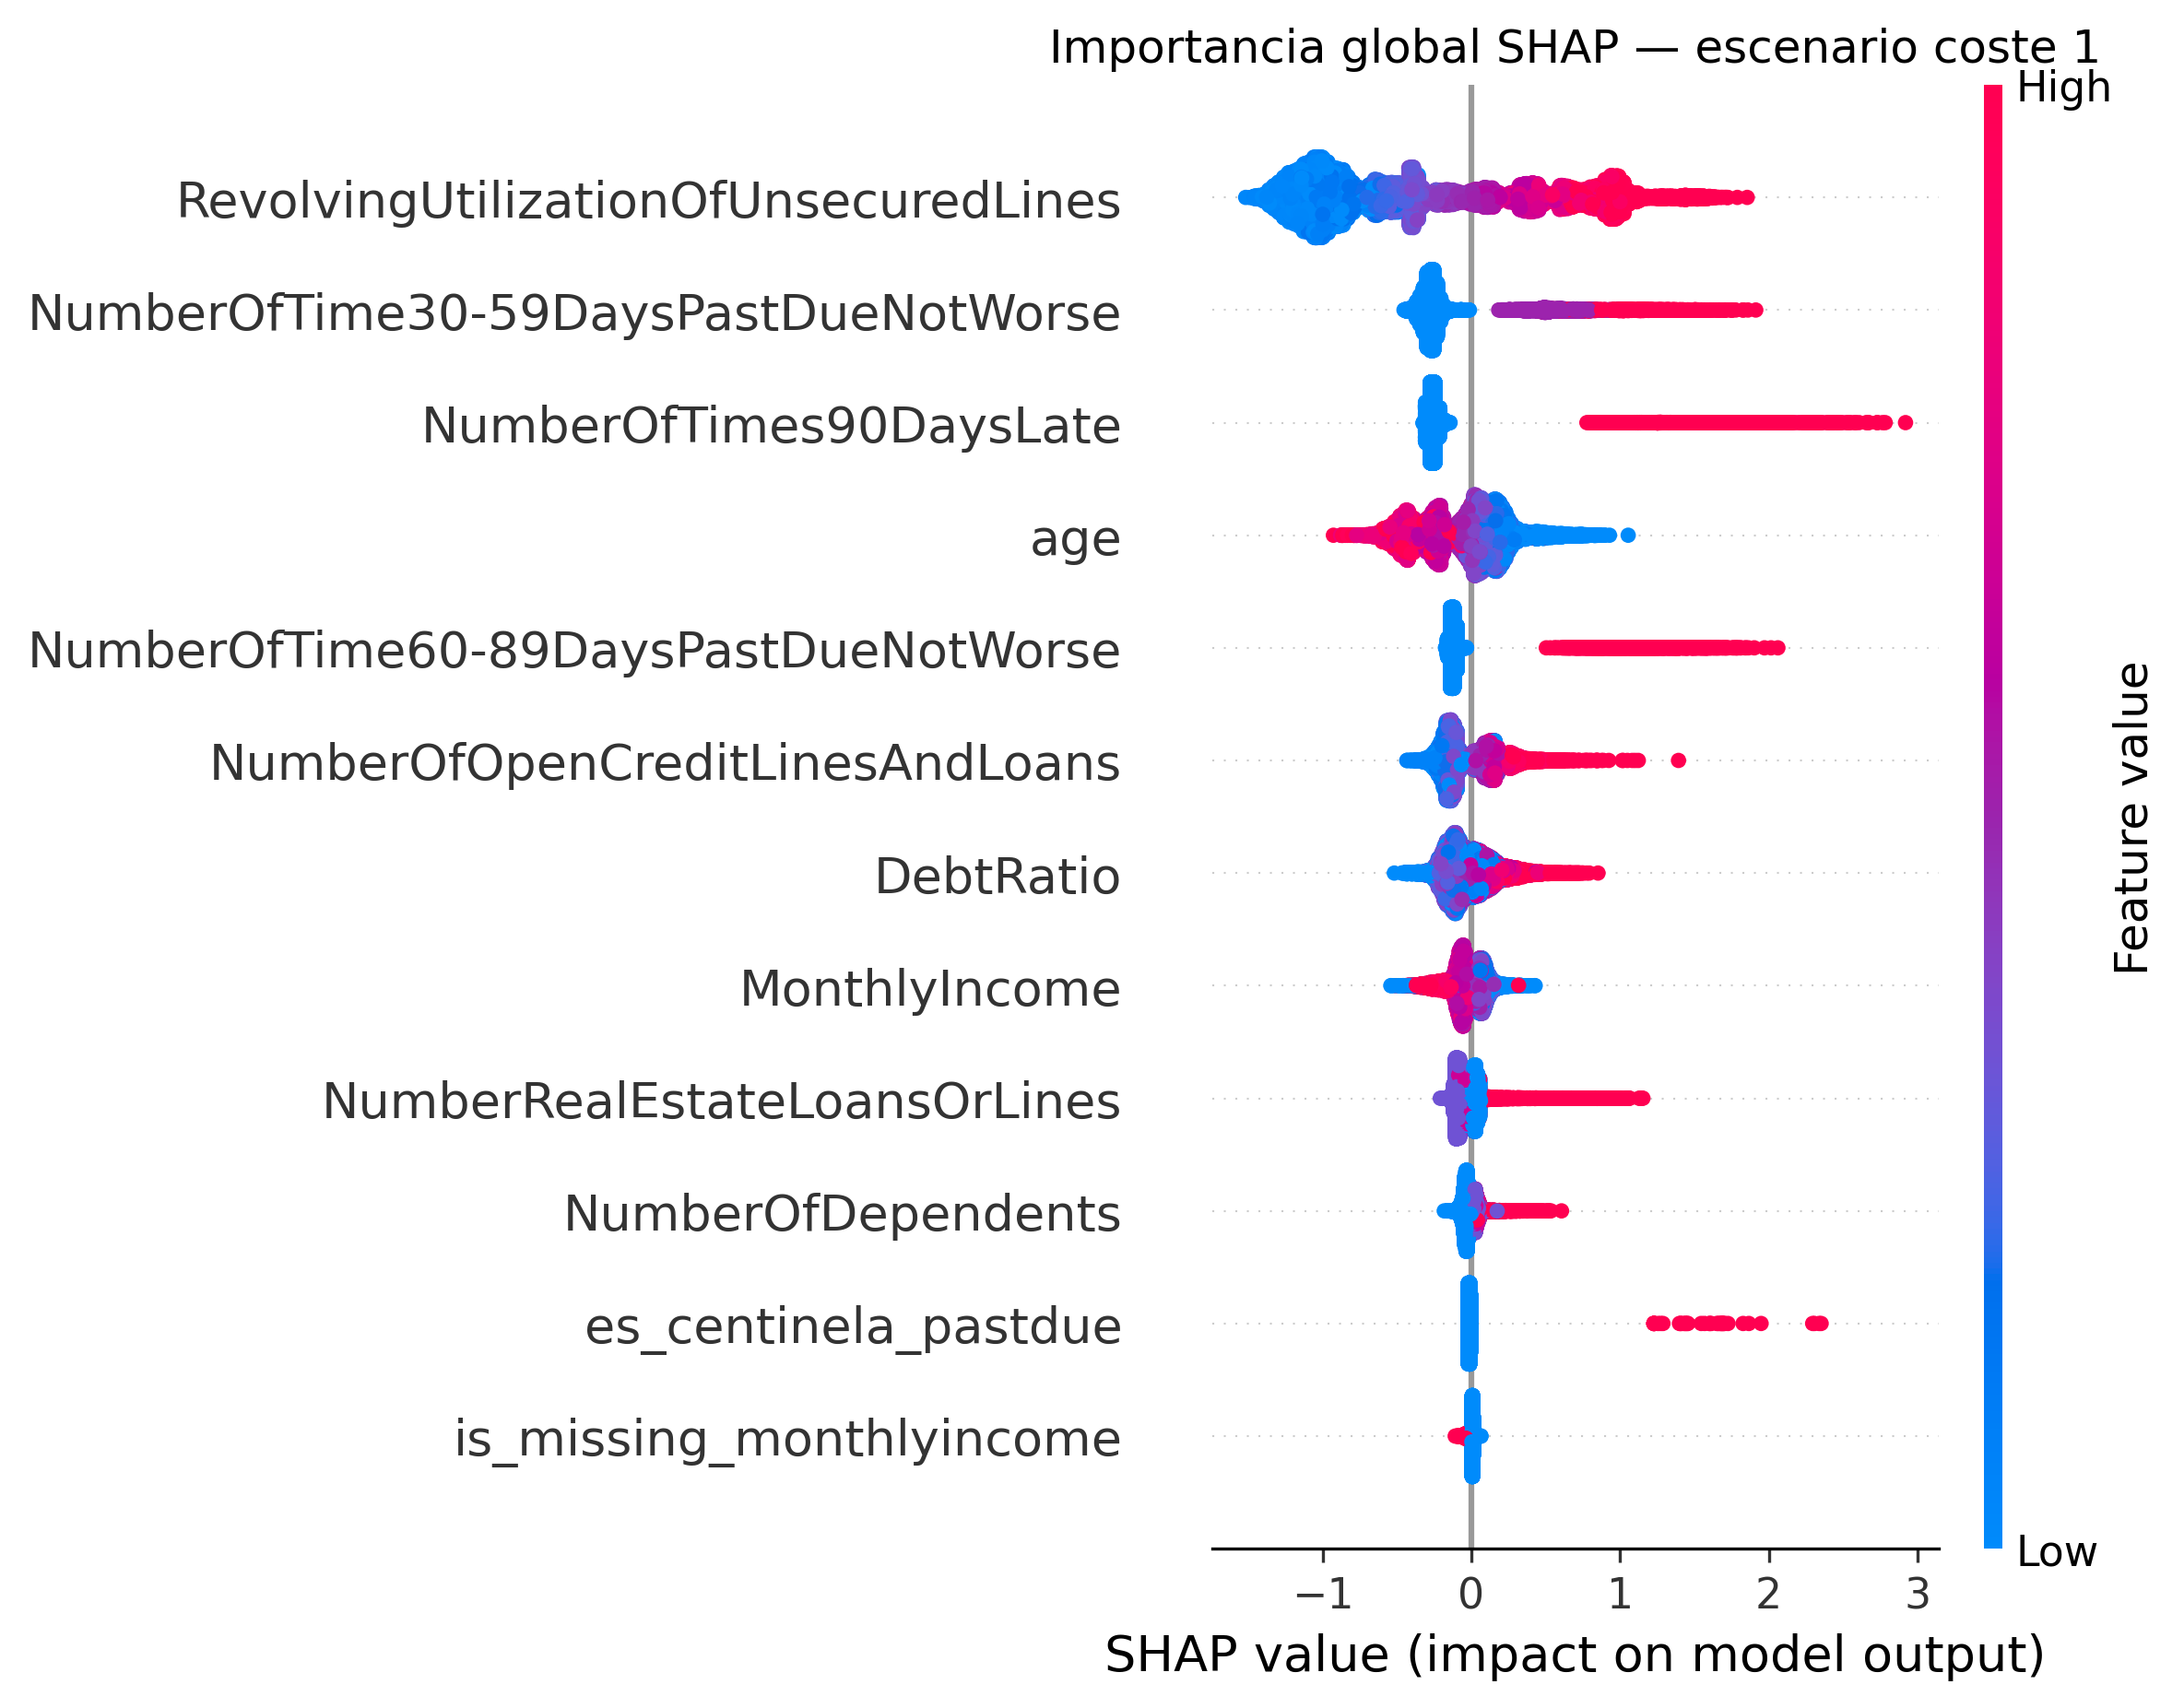

In [54]:
fig('shap_summary_coste1.png')

**Que mirar:** el orden de las variables (de arriba abajo = mas a menos importante) y el color (rojo=valor alto de la variable, azul=valor bajo) para ver el sentido del efecto. RevolvingUtilizationOfUnsecuredLines (uso de credito revolving) domina con mean_abs_shap=0.7873, mas del doble -- 2.26x, no un matiz menor -- que la siguiente, NumberOfTime30-59DaysPastDueNotWorse (0.3486); le siguen NumberOfTimes90DaysLate (0.3278) y age (0.2273).

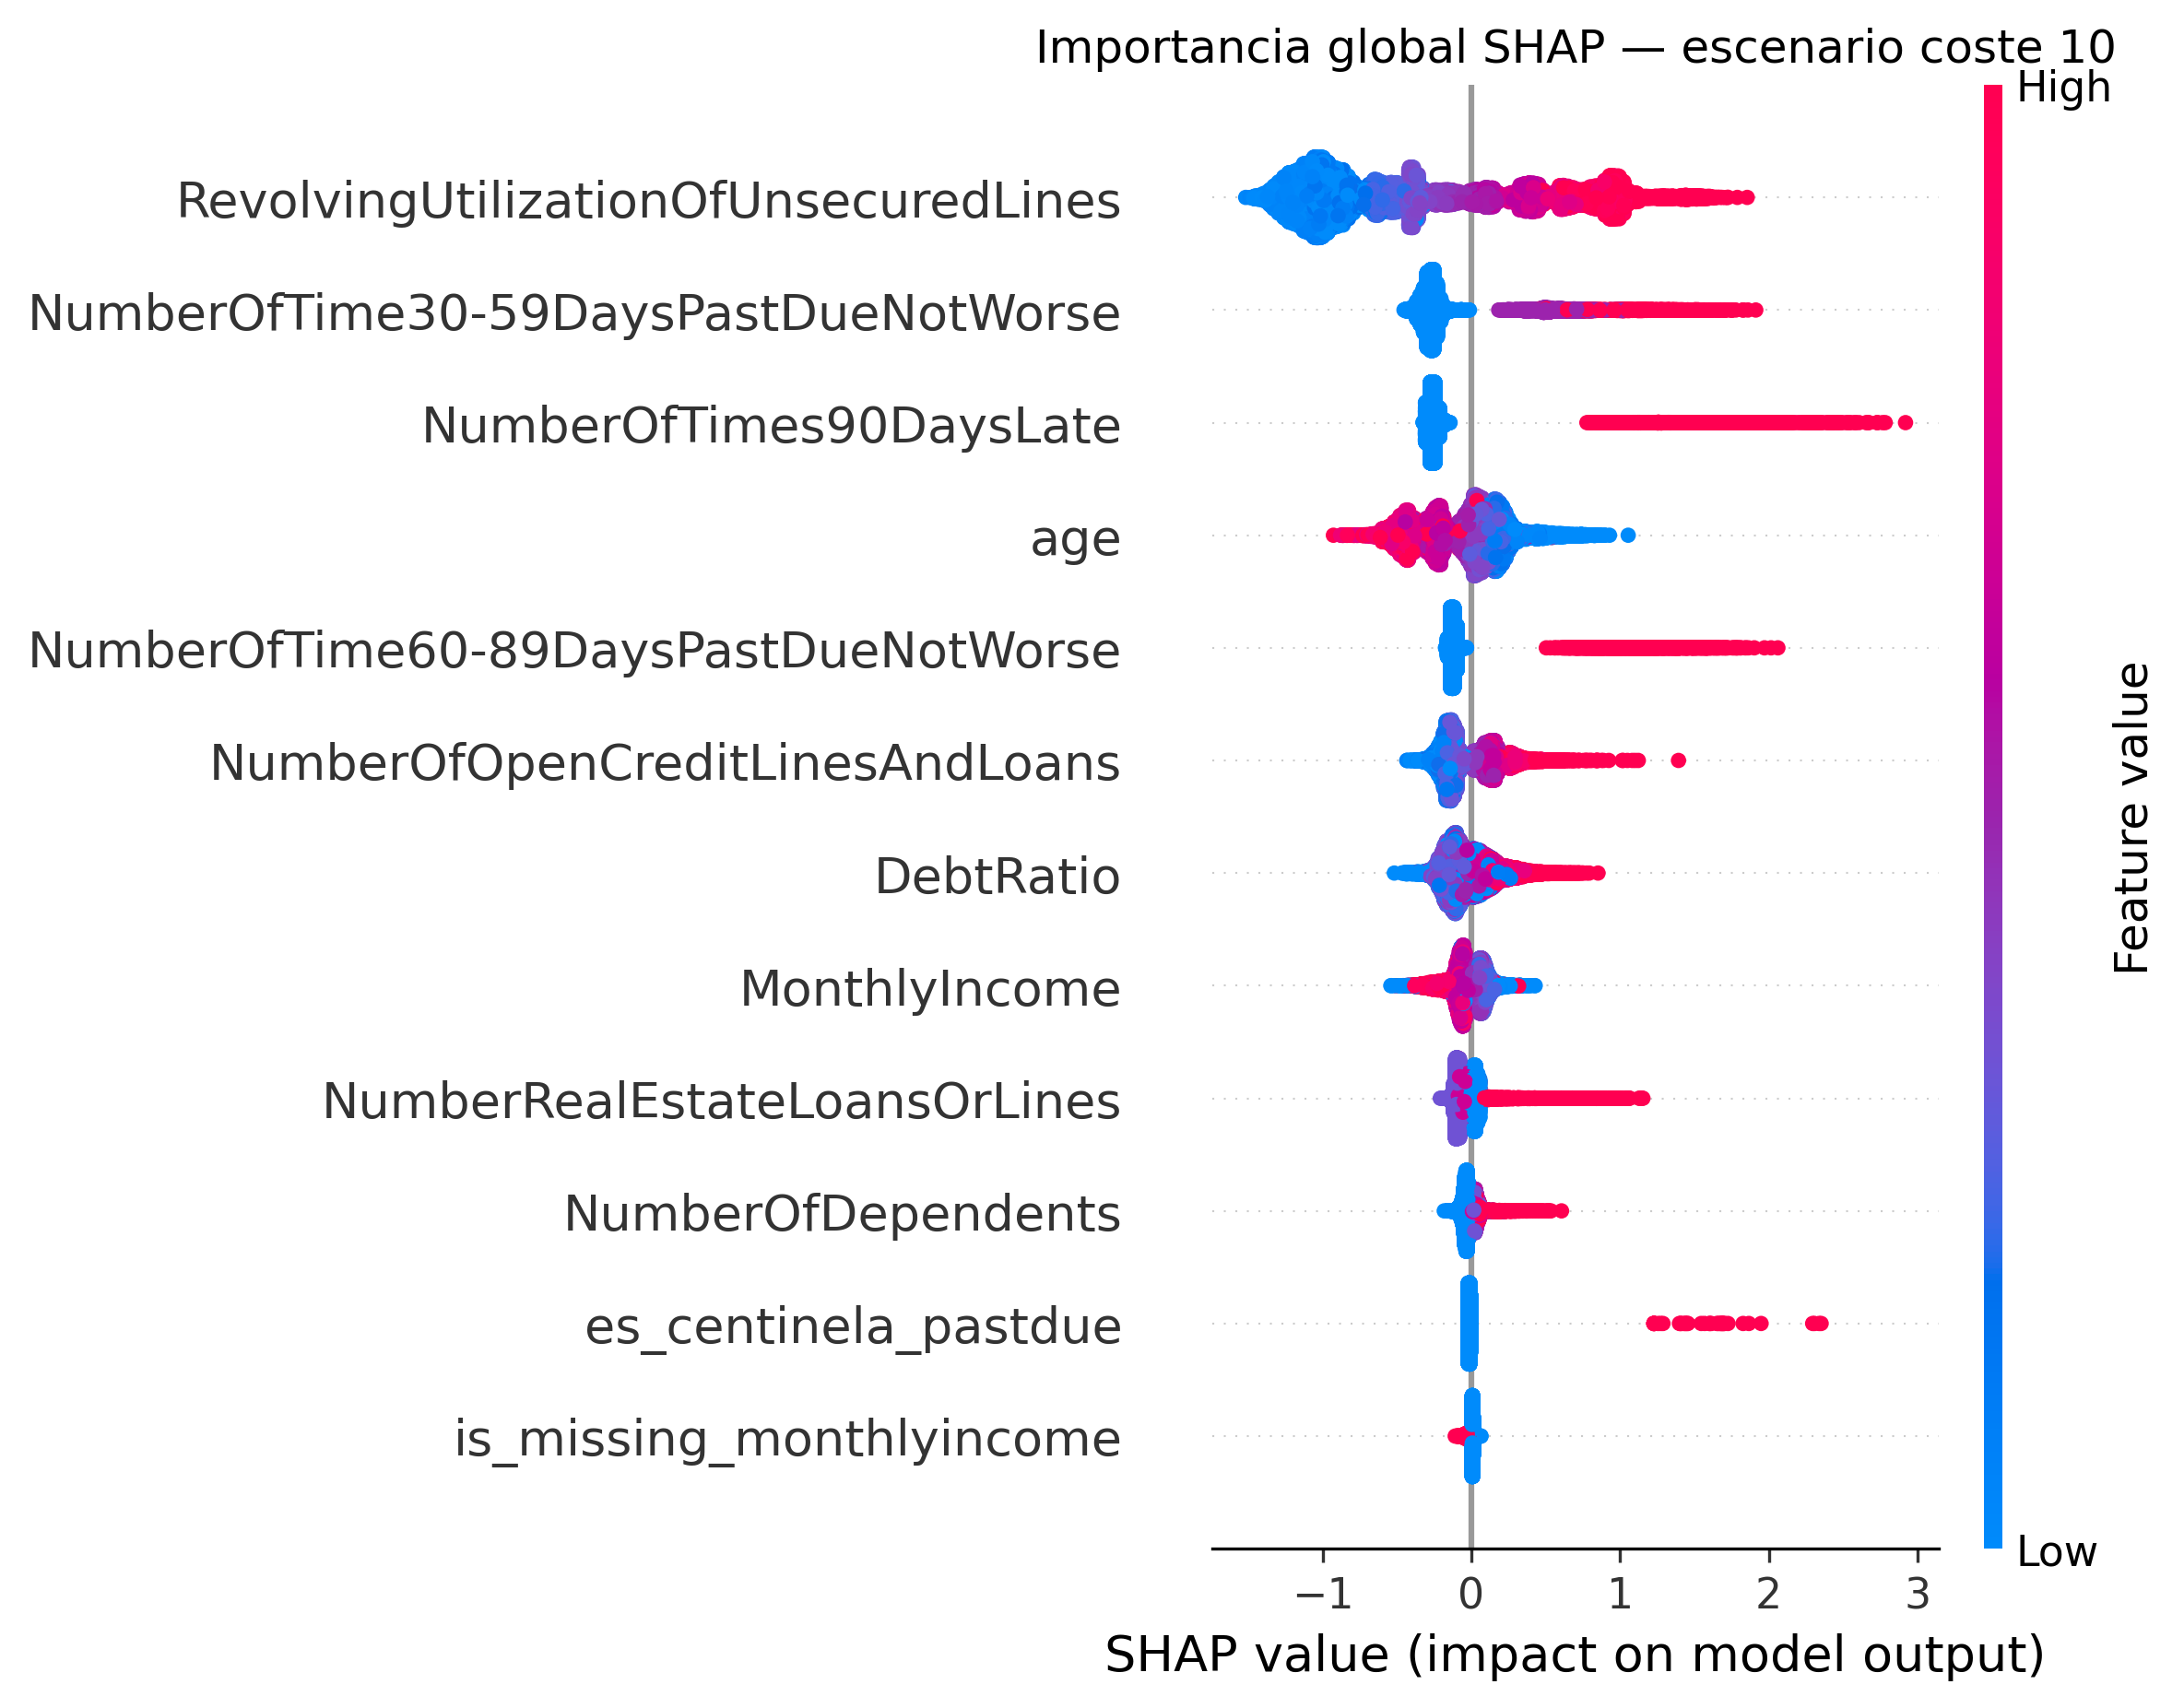

In [55]:
fig('shap_summary_coste10.png')

**Que mirar:** comparar este grafico con el anterior -- son identicos. coste1 y coste10 comparten exactamente el mismo ranking y los mismos valores SHAP (diferencia maxima=0) porque es el mismo XGBoost; solo cambia el umbral de decision aguas abajo (0.4934 en coste1 vs 0.0906 en coste10, elegido segun el coste de cada escenario).

In [56]:
cols = ['escenario', 'feature', 'mean_abs_shap', 'ranking']
print(tabla('shap_values_global.csv')[cols].query("escenario == 'coste1'").head(6).round(4).to_string(index=False))

escenario                              feature  mean_abs_shap  ranking
   coste1 RevolvingUtilizationOfUnsecuredLines         0.7873        1
   coste1 NumberOfTime30-59DaysPastDueNotWorse         0.3486        2
   coste1              NumberOfTimes90DaysLate         0.3278        3
   coste1                                  age         0.2273        4
   coste1 NumberOfTime60-89DaysPastDueNotWorse         0.1735        5
   coste1      NumberOfOpenCreditLinesAndLoans         0.1592        6


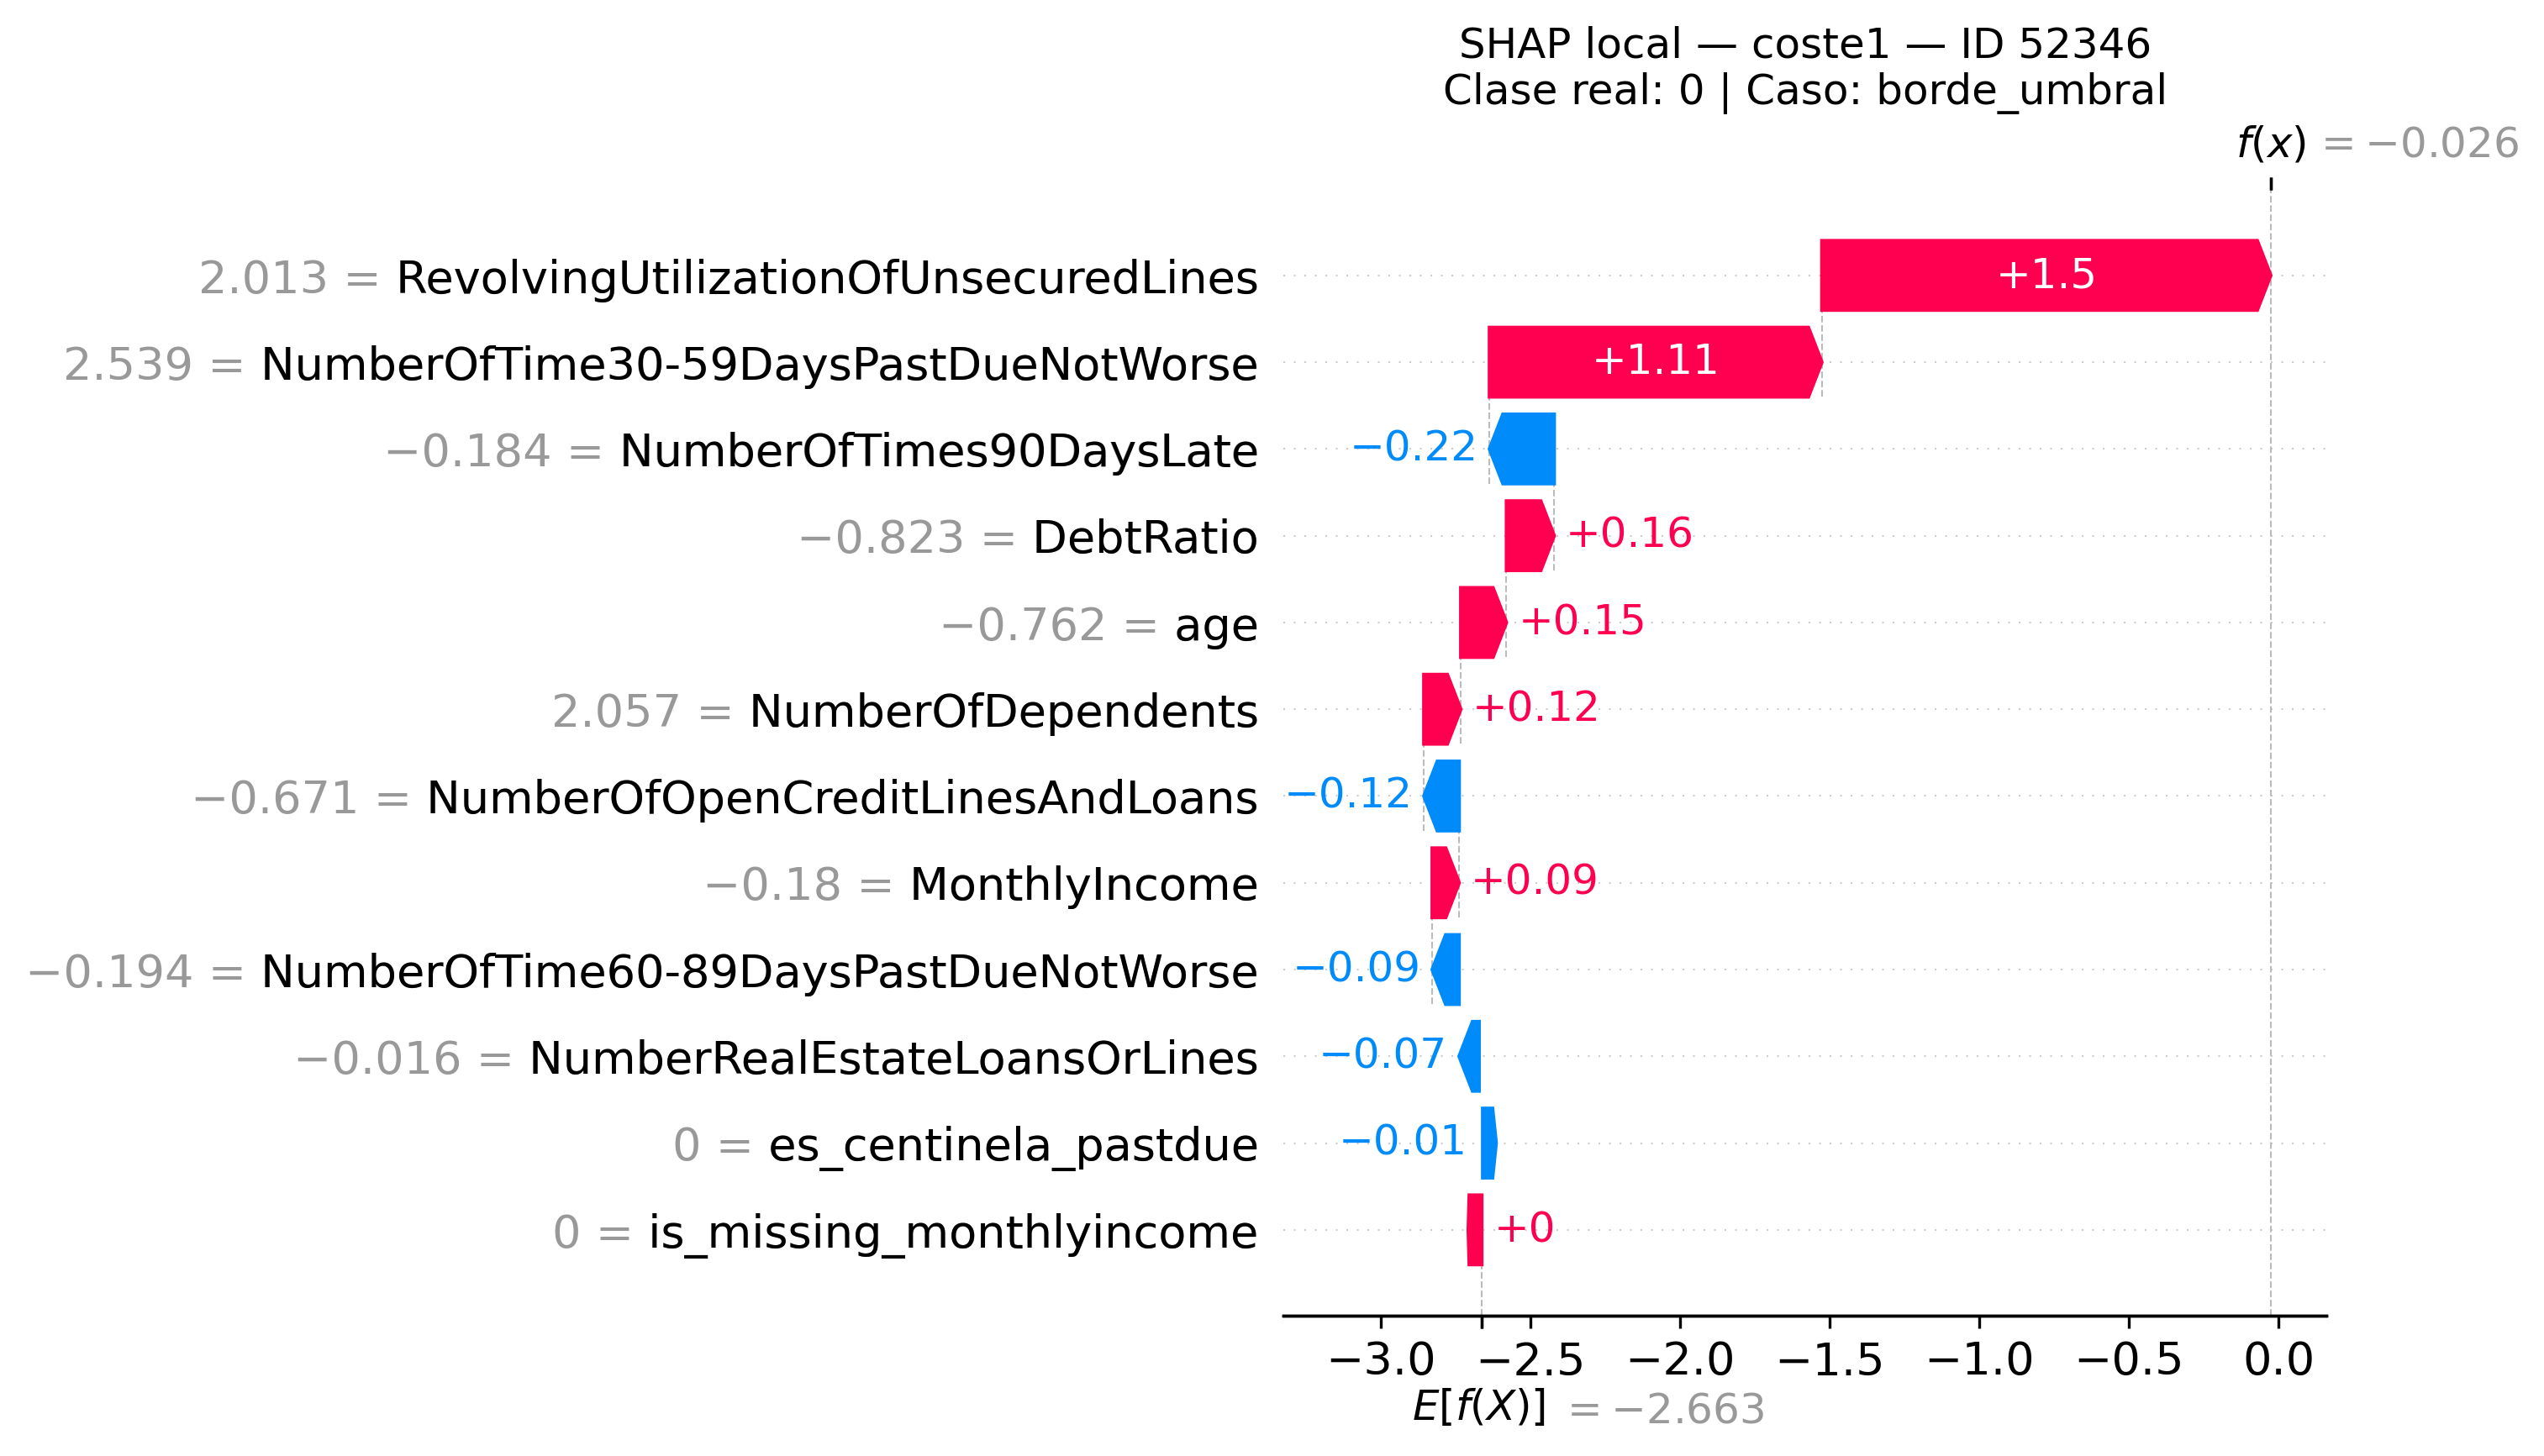

In [57]:
fig('shap_local_coste1_id_52346.png')

**Que mirar:** las barras rojas empujan el score hacia impago, las azules hacia el pago. Caso de borde id_test=52346 (coste1, clase real 0): proba_impago=0.493506 frente a umbral=0.493394, margen de solo +0.000112 -- una denegacion muy ajustada, casi en el limite exacto de la decision.

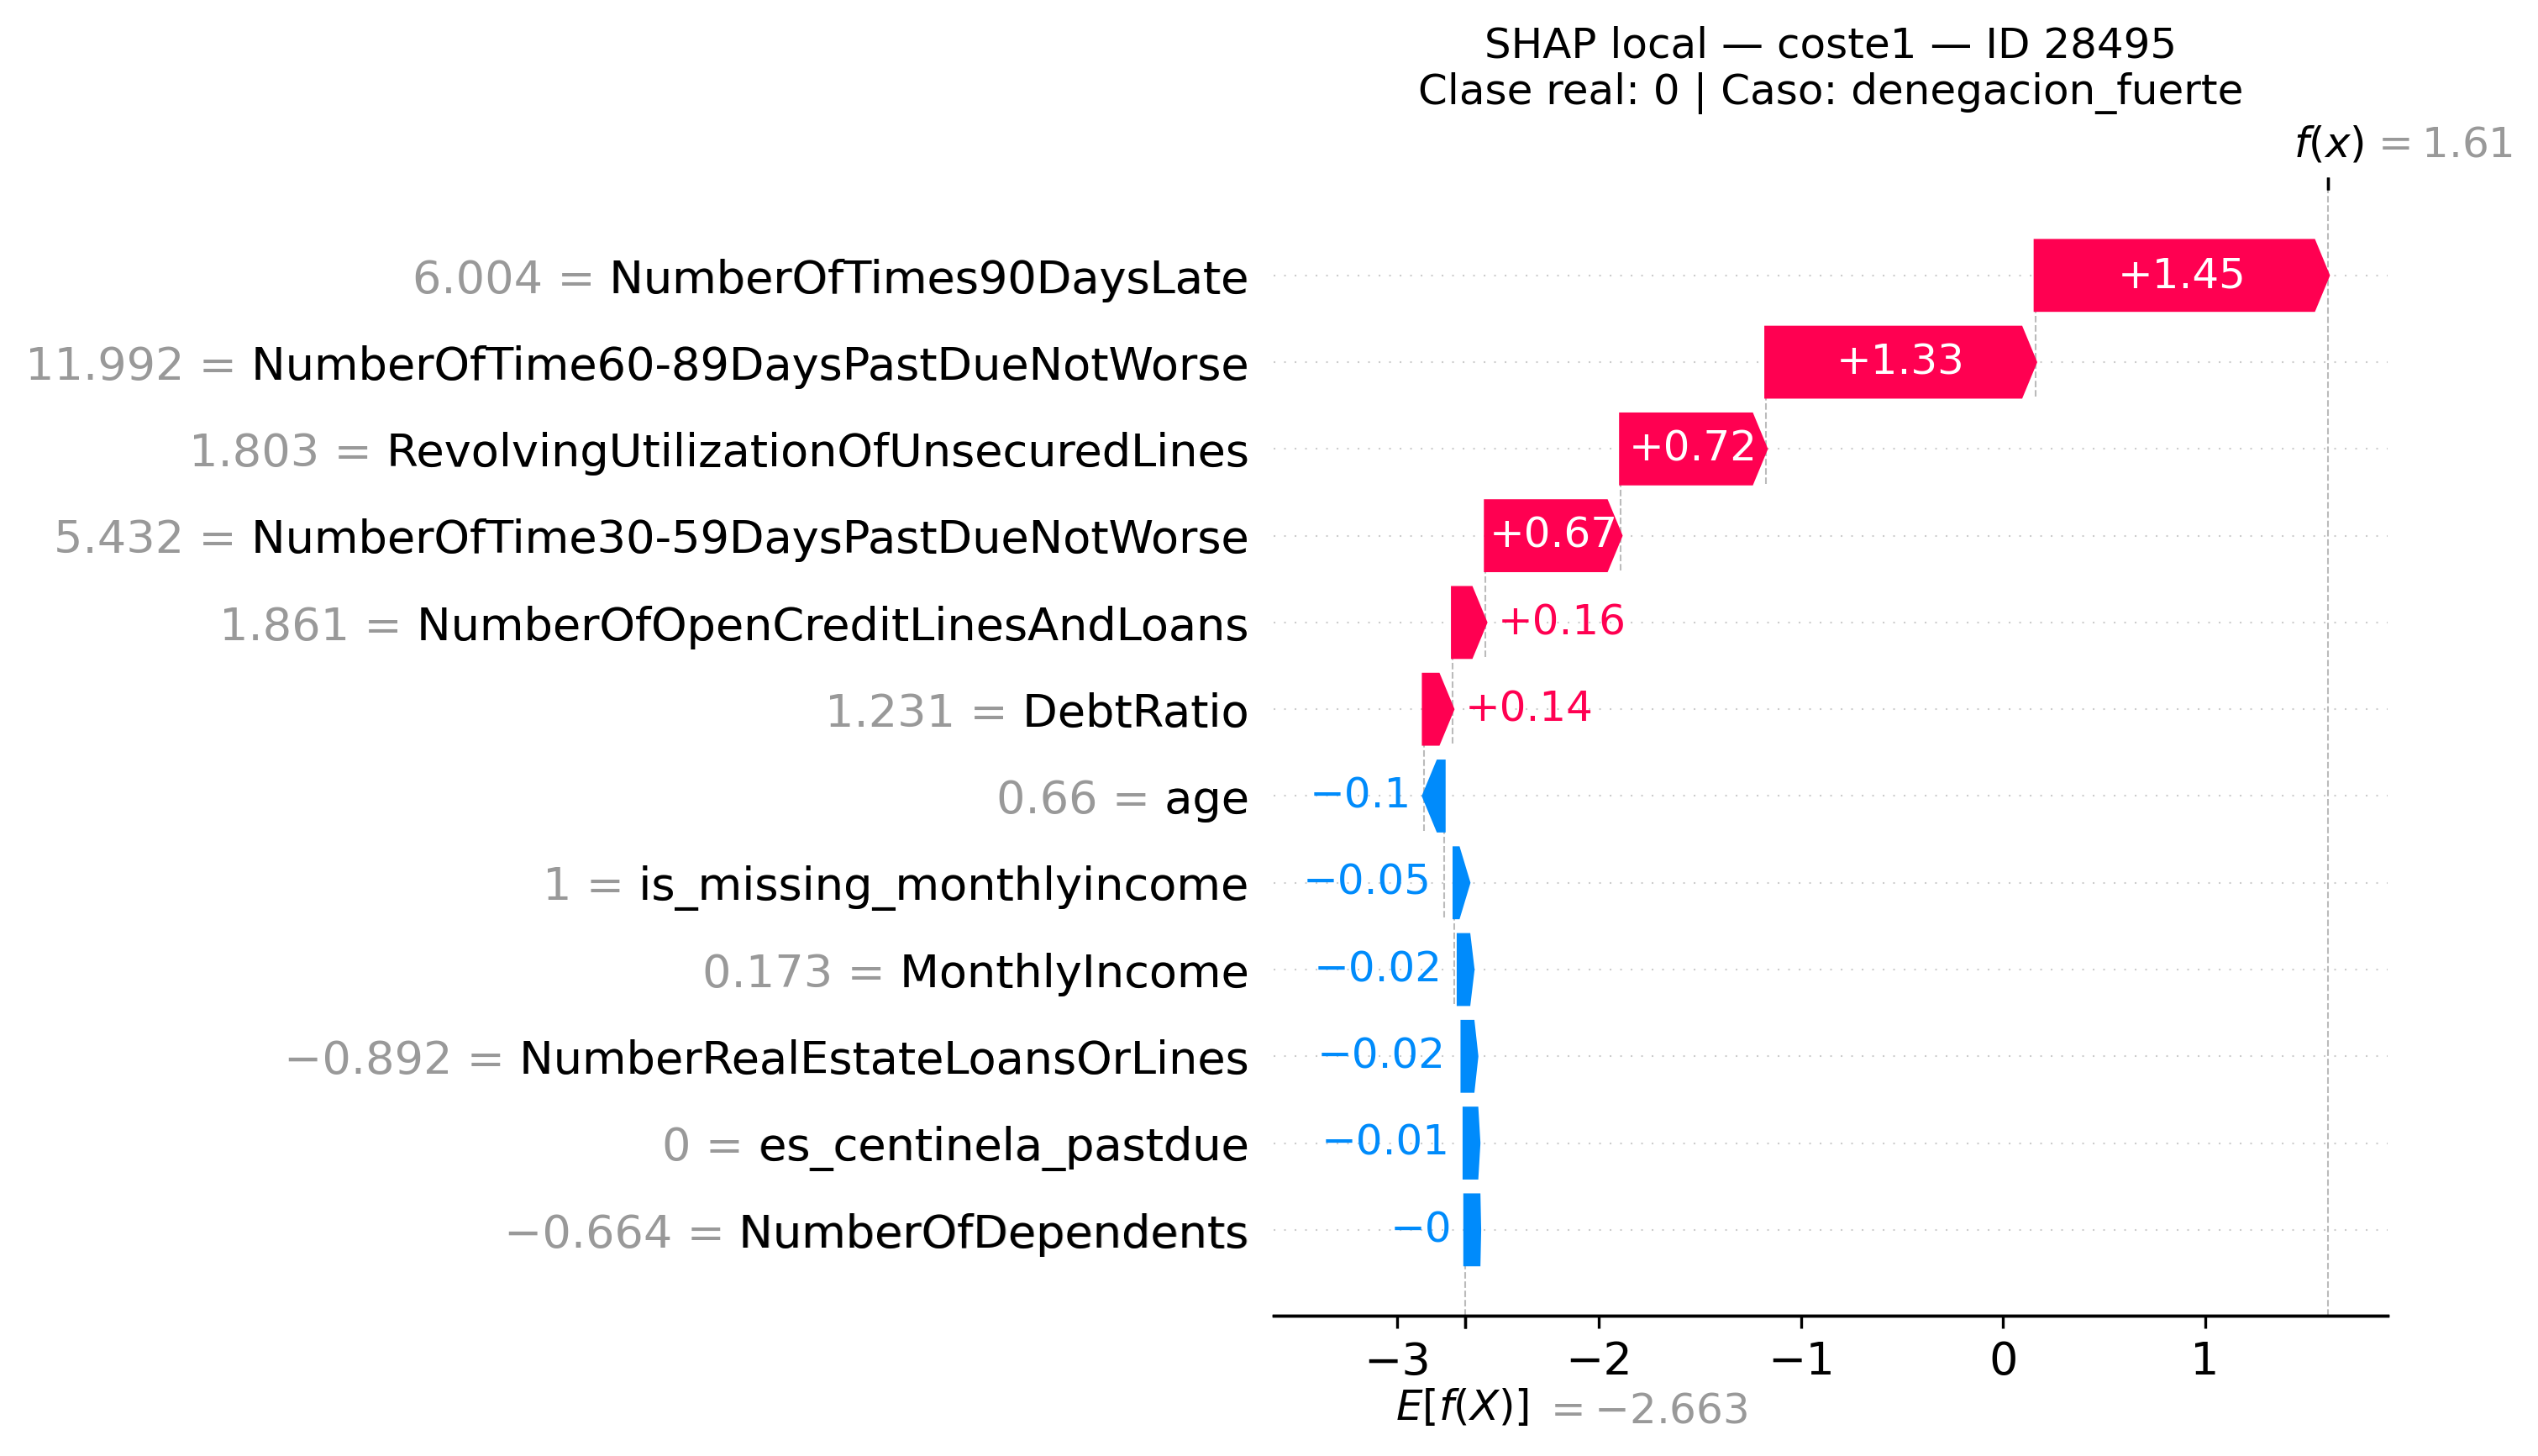

In [58]:
fig('shap_local_coste1_id_28495.png')

**Que mirar:** este id_test=28495 es un caso fuerte presente en ambos escenarios de coste (junto con el id 79585); su explicacion SHAP es identica en coste1 y coste10 (diferencia maxima=0.0), evidencia instancia a instancia adicional de que el modelo base no cambia entre escenarios.

**Cotejo LIME vs SHAP** (LIME se detalla en la seccion 11; aqui solo se contrasta su estabilidad/determinismo frente a SHAP) sobre 6 casos denegados seleccionados aparte, reejecutando LIME 6 veces por caso:

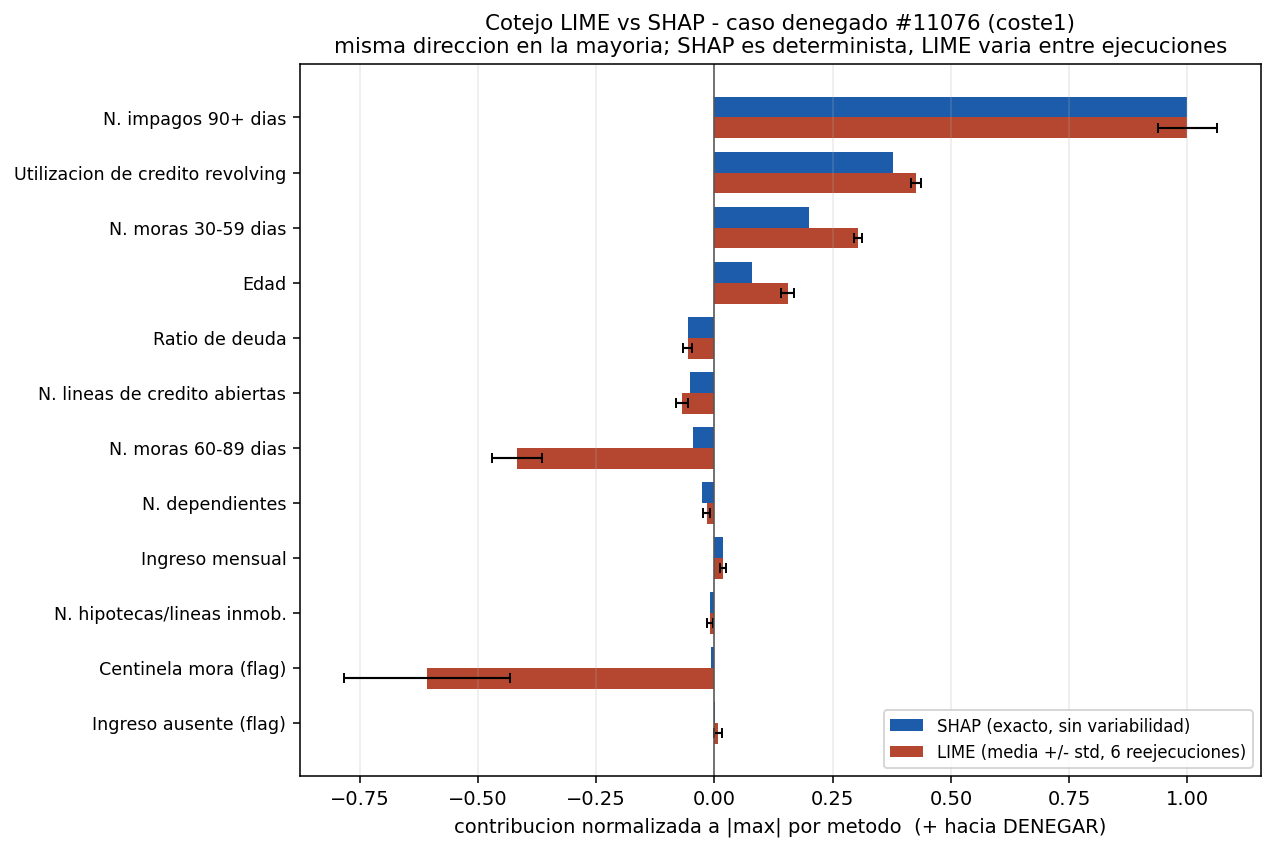

In [59]:
fig('otras_08_lime_vs_shap.png')

**Que mirar:** dispersion de los pesos de LIME entre reejecuciones (paneles con barras de error) frente a la linea plana de SHAP (sin varianza).

In [60]:
cols = ['escenario', 'idx_caso', 'lime_std_media', 'shap_std', 'spearman_abs_lime_shap', 'top1_coincide']
print(tabla('otras_08_lime_vs_shap_resumen.csv')[cols].round(4).to_string(index=False))

escenario  idx_caso  lime_std_media  shap_std  spearman_abs_lime_shap  top1_coincide
   coste1      3665          0.0057       0.0                  0.5175           True
   coste1     11076          0.0055       0.0                  0.6014           True
   coste1     19825          0.0056       0.0                  0.3147          False
  coste10       976          0.0057       0.0                  0.5524          False
  coste10     14834          0.0055       0.0                  0.5245          False
  coste10     17133          0.0058       0.0                  0.4266          False


**Hallazgos:**

1 RevolvingUtilizationOfUnsecuredLines domina la importancia global con mean_abs_shap=0.7873, mas del doble (2.26x) que la siguiente variable, NumberOfTime30-59DaysPastDueNotWorse (0.3486); le siguen NumberOfTimes90DaysLate (0.3278) y age (0.2273).
2 coste1 y coste10 comparten exactamente el mismo ranking y los mismos valores SHAP (diferencia=0) porque es el mismo XGBoost; solo cambia el umbral de decision (0.4934 vs 0.0906), confirmado tambien a nivel de instancia: los ids 28495 y 79585 aparecen en ambos escenarios con SHAP identico (diferencia maxima=0.0).
3 SHAP es exacto y determinista (shap_std=0.0 en los 6 casos evaluados) mientras LIME fluctua entre reejecuciones (lime_std_media~0.0056, hasta 0.0357 en coste10 idx_caso 976); el acuerdo de ranking entre ambos metodos es solo moderado (Spearman medio~0.49, rango 0.31-0.60) y el top1 coincide en apenas 2 de 6 casos.
4 LIME senala 'Centinela mora (flag)' (es_centinela_pastdue) como la variable mas inestable en los 6 casos, justo la que SHAP considera casi irrelevante (mean_abs_shap=0.0146, rank 11 de 12): SHAP es la referencia mas fiable para auditar decisiones individuales.
5 El caso de borde id_test=52346 se decide por un margen minimo (+0.000112 sobre el umbral): una denegacion tan ajustada refuerza por que interesa auditar tambien con contrafactuales (seccion 6) ademas de con SHAP.

## 11. Otras tecnicas de explicabilidad consideradas

El enunciado invita a incluir *"otras tecnicas que los estudiantes consideren oportunas"*. Se aplican
cuatro tecnicas de explicabilidad agnosticas al modelo (operan sobre predict_proba, sin asumir
estructura de arbol), ejecutadas de forma independiente del arbol subrogado (seccion 8) y de SHAP
(seccion 10), sobre los dos modelos de coste ya entrenados -- el escenario simetrico y el asimetrico
comparten el mismo XGBoost y solo difieren en el umbral que convierte la puntuacion en decision:

1 **Importancia por permutacion**: para cada variable se mide cuanto empeora el coste esperado de
  negocio al barajarla al azar (10 repeticiones, muestra de 3000 filas), y se contrasta a 3 bandas
  contra la importancia nativa de XGBoost (ganancia de impureza por split del arbol) y contra la
  importancia del arbol subrogado que imita las decisiones del modelo (seccion 8).

2 **PDP + ICE** sobre el XGBoost nativo (muestra de 2000 filas), incluido un **PDP 2D** de la
  interaccion Edad x N. de moras de 30-59 dias, con ambos ejes ya traducidos a anios y unidades
  reales via el pipeline de preprocesado.

3 **LIME reejecutado 6 veces** sobre los mismos 3 casos denegados por escenario, midiendo cuanto
  varia el peso que asigna a cada variable entre reejecuciones (inestabilidad), usando los indices
  internos de LIME en vez de parsear el texto de sus explicaciones. El cotejo cuantitativo frente a
  SHAP esta en la seccion 10; aqui solo se mide la inestabilidad de LIME por si sola.

4 **Subgrupos por tramo de edad** (los mismos 6 tramos decadales usados en el preprocesado): una
  mini-auditoria de sesgo, motivada por la clasificacion de "alto riesgo" que el reglamento europeo
  de IA otorga a los sistemas de scoring crediticio. El dataset no trae un atributo protegido
  explicito; la edad es el proxy mas cercano disponible, asi que esto es una auditoria descriptiva,
  no un analisis de fairness formal (no se calculan metricas tipo equalized odds).

Limitaciones declaradas: PDP/ICE y la permutacion se calculan sobre muestras de 2000-3000 filas (no
todo el test), el PDP 2D usa una rejilla de 15x15 puntos, y LIME solo se reejecuta sobre 3 casos por
escenario -- suficiente para ilustrar el problema, no para generalizar.

In [61]:
# === Codigo real de la Seccion 11 (fuente: notebooks/08_otras_tecnicas.ipynb;
#     src/xai_utils.py (importancia_permutacion, tabla_importancia_3bandas, pdp_2d,
#     lime_inestabilidad, subgrupos_por_edad)) ===
# Otras tecnicas de explicabilidad (agnosticas al modelo) sobre la MISMA caja negra
# (XGBoost) auditada en 06/07: importancia por permutacion contrastada a 3 bandas,
# PDP 2D de interaccion, ICE de Revolving, inestabilidad de LIME y subgrupos por edad.
# No se reentrena nada: se cargan los bundles ya entrenados y se reusan sus umbrales.
import joblib
import src.xai_utils as xu

RANDOM_STATE = 42
TARGET = cu.TARGET

# --- Carga autocontenida de artefactos (mismo patron que 05/08: joblib.load, sin src.modeling) ---
bundle1 = joblib.load(ROOT/"results"/"models"/"modelo_coste1.joblib")
bundle10 = joblib.load(ROOT/"results"/"models"/"modelo_coste10.joblib")
pipeline = joblib.load(ROOT/"results"/"models"/"preprocessing_pipeline.joblib")
train = pd.read_parquet(ROOT/"data"/"processed"/"train.parquet")
test = pd.read_parquet(ROOT/"data"/"processed"/"test.parquet")

FEATURES = list(bundle1["features"])                # 12 columnas, orden canonico del contrato
X_train = train[FEATURES].copy()
X_test = test[FEATURES].copy()
y_real = test[TARGET].to_numpy(dtype=int)
modelo_c1 = bundle1["modelo"]                       # wrapper ModeloBoosted (estimador_ = XGBClassifier)
modelo_c10 = bundle10["modelo"]
umbral_c1 = float(bundle1["umbral"])                # ~0.4934 (simetrico)
umbral_c10 = float(bundle10["umbral"])              # ~0.0906 (asimetrico)

# --- Un solo scoring, dos umbrales (mismo hallazgo que la seccion del subrogado) ---
proba_c1 = np.asarray(modelo_c1.predict_proba(X_test))[:, 1].astype("float64")
proba_c10 = np.asarray(modelo_c10.predict_proba(X_test))[:, 1].astype("float64")
dif_scoring = float(np.max(np.abs(proba_c1 - proba_c10)))
pred_c1 = cu.aplicar_umbral(proba_c1, umbral_c1)
pred_c10 = cu.aplicar_umbral(proba_c10, umbral_c10)
print(f"Mismo scoring en ambos escenarios (un unico estimador): max|dif| = {dif_scoring:.2e}")
print(f"test: {X_test.shape} | umbral c1={umbral_c1:.4f} deniega {pred_c1.mean()*100:.2f}% | "
      f"umbral c10={umbral_c10:.4f} deniega {pred_c10.mean()*100:.2f}%")

# ---------------------------------------------------------------------------- #
# 1) IMPORTANCIA POR PERMUTACION a 3 bandas (agnostica, XAI.pdf p.166)          #
#    scoring = coste esperado de negocio (negado), no AUC. Submuestra de 3000   #
#    filas por velocidad; n_repeats=10, semilla 42 -> reproduce el CSV. #
# ---------------------------------------------------------------------------- #
y_real_s = pd.Series(y_real, index=X_test.index)
perm_c1 = xu.importancia_permutacion(modelo_c1, X_test, y_real_s, bundle1["C_FP"], bundle1["C_FN"],
                                     n_repeats=10, random_state=RANDOM_STATE, muestra=3000)
perm_c10 = xu.importancia_permutacion(modelo_c10, X_test, y_real_s, bundle10["C_FP"], bundle10["C_FN"],
                                      n_repeats=10, random_state=RANDOM_STATE, muestra=3000)
nativa_c1 = xu.importancia_nativa_xgboost(modelo_c1.estimador_, FEATURES)
nativa_c10 = xu.importancia_nativa_xgboost(modelo_c10.estimador_, FEATURES)
sub_importancia = pd.read_csv(TAB/"sub_05_importancia_variables.csv")     # subrogado de 05 (nombres legibles)

tabla3_c1 = xu.tabla_importancia_3bandas(perm_c1, nativa_c1, sub_importancia, "imp_coste1")
tabla3_c10 = xu.tabla_importancia_3bandas(perm_c10, nativa_c10, sub_importancia, "imp_coste10")
for t in (tabla3_c1, tabla3_c10):
    t["nombre_legible"] = t["variable"].map(xu.NOMBRE_LEGIBLE).fillna(t["variable"])

cols_show = ["nombre_legible", "importancia_permutacion_media",
             "importancia_xgboost_nativa", "importancia_subrogado_05"]
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print("\nCONTRASTE A 3 BANDAS - coste1 (simetrico) [n=3000]")
    print(tabla3_c1[cols_show].to_string(index=False))
    print("\nCONTRASTE A 3 BANDAS - coste10 (asimetrico) [n=3000]")
    print(tabla3_c10[cols_show].to_string(index=False))

# Lectura: la banda 'coste de negocio' reordena drivers segun el escenario. En coste1 los
# contadores de mora cortos mandan; en coste10 (FN 10x) Revolving y 90+ dias suben. Las 3
# bandas coinciden en el nucleo de drivers pero NO en el ranking fino -> ninguna es 'la verdad'.
print("\nTop-3 por permutacion (coste de negocio):")
print(f"  coste1 : {tabla3_c1['nombre_legible'].head(3).tolist()}")
print(f"  coste10: {tabla3_c10['nombre_legible'].head(3).tolist()}")

# ---------------------------------------------------------------------------- #
# 2) PDP 2D de INTERACCION Edad x N. moras 30-59 (corrobora 'dos personalidades' de 05).      #
#    NO se redibuja la figura canonica (otras_08_pdp2d_interaccion.png): se cuantifica         #
#    la no-aditividad imprimiendo como cambia el efecto de la edad segun el nivel de mora.      #
# ---------------------------------------------------------------------------- #
N_MUESTRA_PDP = 2000                                        # muestra para PDP/ICE
X_muestra = X_test.sample(N_MUESTRA_PDP, random_state=RANDOM_STATE)
par = ("age", "NumberOfTime30-59DaysPastDueNotWorse")
r2d = xu.pdp_2d(modelo_c10.estimador_, X_muestra, par, grid_resolution=15)   # escenario coste10
eje_edad = xu.columna_a_original(pipeline, par[0], r2d["grid_values"][0])     # ambos ejes vienen estandarizados
eje_moras = xu.columna_a_original(pipeline, par[1], r2d["grid_values"][1])
Z = np.asarray(r2d["average"][0])                           # shape (edad, moras) -> P(denegar) media
# Efecto de la edad = amplitud (max-min sobre edad) a cada nivel de mora: si varia, hay interaccion.
efecto_edad_por_mora = Z.max(axis=0) - Z.min(axis=0)
j_lo, j_hi = int(np.argmin(eje_moras)), int(np.argmax(eje_moras))
print("\nPDP 2D (coste10) Edad x N.moras 30-59:")
print(f"  P(denegar) en la rejilla: min={Z.min():.3f}  max={Z.max():.3f}")
print(f"  amplitud del efecto EDAD con moras={eje_moras[j_lo]:.1f} -> {efecto_edad_por_mora[j_lo]:.3f}")
print(f"  amplitud del efecto EDAD con moras={eje_moras[j_hi]:.1f} -> {efecto_edad_por_mora[j_hi]:.3f}")
print(f"  ratio de amplitud (alta/baja mora) = {efecto_edad_por_mora[j_hi]/max(efecto_edad_por_mora[j_lo],1e-9):.2f}x"
      "  -> superficie NO aditiva = interaccion real")

# ---------------------------------------------------------------------------- #
# 3) ICE de Revolving (heterogeneidad individual, XAI.pdf p.158).                #
#    NO se redibuja la figura canonica (otras_08_ice_revolving.png): se resume   #
#    numericamente la dispersion de las curvas individuales frente al PDP medio.  #
# ---------------------------------------------------------------------------- #
feat_ice = "RevolvingUtilizationOfUnsecuredLines"
X_ice = X_muestra.sample(150, random_state=RANDOM_STATE)
r_ice = xu.pdp_1d(modelo_c1.estimador_, X_ice, feat_ice, grid_resolution=25, kind="both")
grid_ice = xu.columna_a_original(pipeline, feat_ice, r_ice["grid_values"][0])
ice = np.asarray(r_ice["individual"][0])                    # (n_curvas, grid)
media = np.asarray(r_ice["average"][0])                     # (grid,)
print(f"\nICE {feat_ice} (coste1, n={len(X_ice)} curvas):")
print(f"  PDP medio: sube de P(denegar)={media[0]:.3f} (util~{grid_ice[0]:.2f}) "
      f"a {media[-1]:.3f} (util~{grid_ice[-1]:.2f})")
print(f"  dispersion entre individuos en el extremo alto: std={ice[:, -1].std():.3f}, "
      f"rango=[{ice[:, -1].min():.3f}, {ice[:, -1].max():.3f}]  -> efecto heterogeneo, no plano")

# ---------------------------------------------------------------------------- #
# 4) INESTABILIDAD de LIME (contraste critico frente a SHAP, XAI.pdf pp.185-199). #
#    lime NO esta instalado en este entorno -> el codigo REAL va en el try y el   #
#    except carga el CSV guardado (otras_08_lime_local.csv) para que el nb corra.  #
# ---------------------------------------------------------------------------- #
K_REEJECUCIONES = 6
lime_en_vivo = False
try:
    import lime  # noqa: F401  (solo para forzar el ImportError si no esta)
    # --- Codigo real: casos denegados autocontenidos + K reejecuciones por caso ---
    N_CASOS_LIME = 3
    rng = np.random.RandomState(RANDOM_STATE)
    casos_c1 = rng.choice(np.where(pred_c1 == 1)[0], size=N_CASOS_LIME, replace=False)
    casos_c10 = rng.choice(np.where(pred_c10 == 1)[0], size=N_CASOS_LIME, replace=False)
    filas_inest = []
    for nombre_esc, modelo, casos in (("coste1", modelo_c1, casos_c1),
                                      ("coste10", modelo_c10, casos_c10)):
        for i_caso in casos:
            x = X_test.iloc[int(i_caso)].values
            _, tab = xu.lime_inestabilidad(modelo, x, X_train.values, FEATURES,
                                           k_reejecuciones=K_REEJECUCIONES, semilla_base=RANDOM_STATE)
            tab.insert(0, "escenario", nombre_esc); tab.insert(1, "idx_caso", int(i_caso))
            filas_inest.append(tab)
    tabla_lime = pd.concat(filas_inest, ignore_index=True)
    tabla_lime["nombre_legible"] = tabla_lime["variable"].map(xu.NOMBRE_LEGIBLE).fillna(tabla_lime["variable"])
    lime_en_vivo = True
    print("\n[LIME] ejecutado en vivo (lime instalado).")
except ImportError:
    tabla_lime = pd.read_csv(TAB/"otras_08_lime_local.csv")
    print("\n[LIME] lime NO instalado -> se carga results/tables/otras_08_lime_local.csv "
          "(resultado real guardado; el codigo real queda en el try de arriba).")

# NO se redibuja la figura canonica (otras_08_lime_inestabilidad.png): se listan las
# combinaciones (caso, variable) mas INESTABLES (mayor peso_std entre las 6 reejecuciones).
print(f"  K reejecuciones por caso = {int(tabla_lime['k_reejecuciones'].iloc[0])} | "
      f"casos = {tabla_lime['idx_caso'].nunique()} | filas = {len(tabla_lime)}")
top_inest = tabla_lime.sort_values("peso_std", ascending=False).head(5)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(top_inest[["escenario", "idx_caso", "nombre_legible", "peso_medio", "peso_std"]].to_string(index=False))
print(f"  peso_std maximo = {tabla_lime['peso_std'].max():.4f}  "
      "-> misma variable, mismo caso, distinta explicacion segun la semilla = LIME inestable")

# ---------------------------------------------------------------------------- #
# 5) SUBGRUPOS por tramo de EDAD (mini-auditoria de sesgo): tasa de denegacion   #
#    vs tasa de impago REAL, ambos escenarios. Edad traducida a escala real.     #
#    NO se redibuja la figura canonica (otras_08_subgrupos_edad.png).            #
# ---------------------------------------------------------------------------- #
edad_original = xu.columna_a_original(pipeline, "age", X_test["age"].values)
subg_c1 = xu.subgrupos_por_edad(edad_original, y_real, pred_c1, bundle1["C_FP"], bundle1["C_FN"])
subg_c10 = xu.subgrupos_por_edad(edad_original, y_real, pred_c10, bundle10["C_FP"], bundle10["C_FN"])
subg_c1.insert(0, "escenario", "coste1"); subg_c10.insert(0, "escenario", "coste10")
tabla_subg = pd.concat([subg_c1, subg_c10], ignore_index=True)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print("\nSUBGRUPOS POR TRAMO DE EDAD - ambos escenarios")
    print(tabla_subg[["escenario", "tramo_edad", "n", "tasa_denegacion",
                      "tasa_impago_real", "fp_rate", "fn_rate"]].to_string(index=False))
# Lectura de sesgo: en coste10 la denegacion a <=30 (0.372) es ~7x la de >70 (0.052), pero su
# impago real solo es ~5x -> el trato por edad NO es del todo proporcional al riesgo real.
r_deny = subg_c10.set_index("tramo_edad").loc["<=30", "tasa_denegacion"] / subg_c10.set_index("tramo_edad").loc[">70", "tasa_denegacion"]
r_riesgo = subg_c1.set_index("tramo_edad").loc["<=30", "tasa_impago_real"] / subg_c1.set_index("tramo_edad").loc[">70", "tasa_impago_real"]
print(f"  coste10: ratio denegacion (<=30 / >70) = {r_deny:.1f}x  vs  ratio impago real = {r_riesgo:.1f}x")

# ---------------------------------------------------------------------------- #
# COTEJO con los CSV canonicos de la seccion (deben coincidir a ~1e-6)           #
# ---------------------------------------------------------------------------- #
def _maxdif(df_a, df_b, key, col):
    m = df_a[[key, col]].merge(df_b[[key, col]], on=key, suffixes=("_calc", "_csv"))
    return float((m[col + "_calc"] - m[col + "_csv"]).abs().max())

csv_p1 = pd.read_csv(TAB/"otras_08_permutacion_importancia_coste1.csv")
csv_p10 = pd.read_csv(TAB/"otras_08_permutacion_importancia_coste10.csv")
csv_sg = pd.read_csv(TAB/"otras_08_subgrupos_edad.csv")
d_p1 = _maxdif(tabla3_c1, csv_p1, "variable", "importancia_permutacion_media")
d_p10 = _maxdif(tabla3_c10, csv_p10, "variable", "importancia_permutacion_media")
d_sg = float((tabla_subg.sort_values(["escenario", "tramo_edad"]).reset_index(drop=True)["tasa_denegacion"].values
              - csv_sg.sort_values(["escenario", "tramo_edad"]).reset_index(drop=True)["tasa_denegacion"].values).__abs__().max())
print("\n[COTEJO vs CSV canonicos]")
print(f"  permutacion coste1  max|dif| = {d_p1:.2e}")
print(f"  permutacion coste10 max|dif| = {d_p10:.2e}")
print(f"  subgrupos tasa_denegacion max|dif| = {d_sg:.2e}")
assert d_p1 < 1e-6 and d_p10 < 1e-6 and d_sg < 1e-6, "los numeros NO cuadran con los CSV canonicos"
print("  OK: los numeros reproducen las tablas/figuras de la seccion.")


Mismo scoring en ambos escenarios (un unico estimador): max|dif| = 0.00e+00
test: (21000, 12) | umbral c1=0.4934 deniega 2.38% | umbral c10=0.0906 deniega 18.70%



CONTRASTE A 3 BANDAS - coste1 (simetrico) [n=3000]
                  nombre_legible  importancia_permutacion_media  importancia_xgboost_nativa  importancia_subrogado_05
             N. moras 30-59 dias                         0.0022                      0.1298                    0.0734
             N. impagos 90+ dias                         0.0020                      0.3301                    0.7155
Utilizacion de credito revolving                         0.0014                      0.1922                    0.0397
             N. moras 60-89 dias                         0.0012                      0.1493                    0.1219
                 Ingreso mensual                         0.0009                      0.0138                    0.0032
                  Ratio de deuda                         0.0008                      0.0184                    0.0089
   N. lineas de credito abiertas                         0.0008                      0.0219                    0.0208
    


PDP 2D (coste10) Edad x N.moras 30-59:
  P(denegar) en la rejilla: min=0.034  max=0.258
  amplitud del efecto EDAD con moras=-0.0 -> 0.045
  amplitud del efecto EDAD con moras=8.0 -> 0.089
  ratio de amplitud (alta/baja mora) = 1.98x  -> superficie NO aditiva = interaccion real

ICE RevolvingUtilizationOfUnsecuredLines (coste1, n=150 curvas):
  PDP medio: sube de P(denegar)=0.041 (util~0.00) a 0.138 (util~0.99)
  dispersion entre individuos en el extremo alto: std=0.145, rango=[0.025, 0.854]  -> efecto heterogeneo, no plano

[LIME] lime NO instalado -> se carga results/tables/otras_08_lime_local.csv (resultado real guardado; el codigo real queda en el try de arriba).
  K reejecuciones por caso = 6 | casos = 6 | filas = 72
escenario  idx_caso        nombre_legible  peso_medio  peso_std
  coste10       976 Centinela mora (flag)     -0.1067    0.0357
  coste10     17133 Centinela mora (flag)     -0.1045    0.0335
   coste1     19825 Centinela mora (flag)     -0.1084    0.0327
   coste1  


SUBGRUPOS POR TRAMO DE EDAD - ambos escenarios
escenario tramo_edad    n  tasa_denegacion  tasa_impago_real  fp_rate  fn_rate
   coste1       <=30 1562           0.0397            0.1056   0.0193   0.7879
   coste1      31-40 3431           0.0426            0.0895   0.0221   0.7492
   coste1      41-50 4951           0.0329            0.0844   0.0141   0.7632
   coste1      51-60 4896           0.0178            0.0674   0.0077   0.8424
   coste1      61-70 3734           0.0075            0.0356   0.0036   0.8872
   coste1        >70 2426           0.0054            0.0210   0.0021   0.8431
  coste10       <=30 1562           0.3720            0.1056   0.3157   0.1515
  coste10      31-40 3431           0.2874            0.0895   0.2398   0.2280
  coste10      41-50 4951           0.2371            0.0844   0.1902   0.2536
  coste10      51-60 4896           0.1544            0.0674   0.1180   0.3424
  coste10      61-70 3734           0.0809            0.0356   0.0628   0.4286
  co

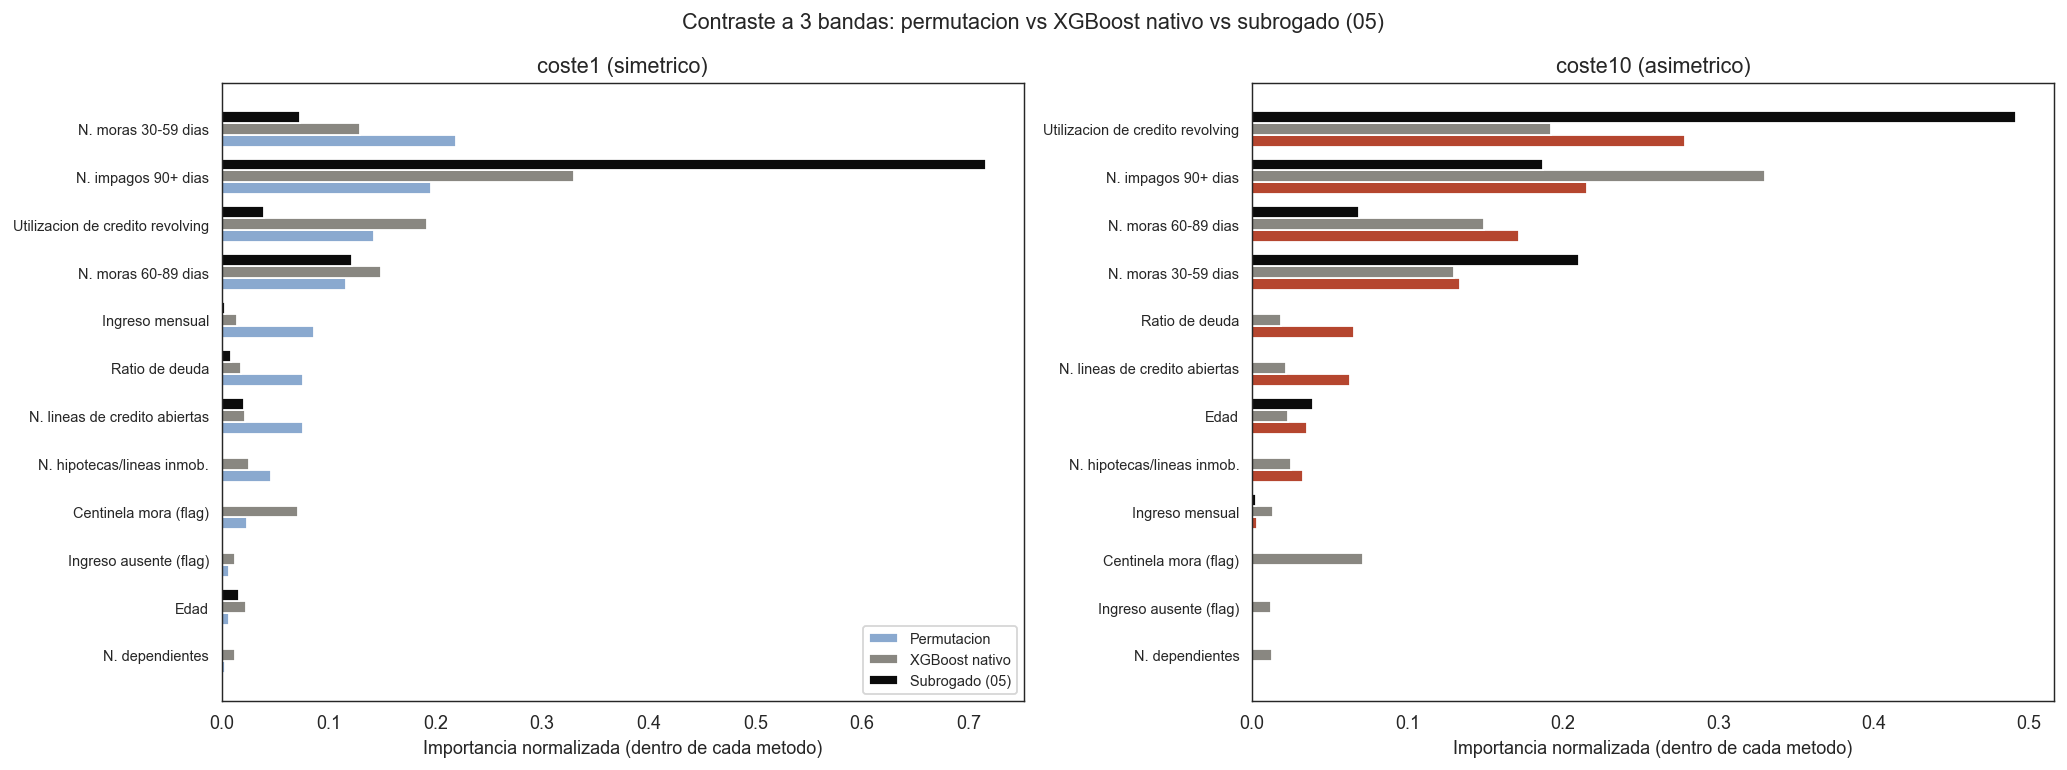

In [62]:
fig("otras_08_permutacion_3bandas.png", w=760)

**Que mirar:** las 3 barras (permutacion, XGBoost nativo, subrogado) para la
misma variable, panel coste1 arriba y coste10 abajo. En coste1, XGBoost nativo y subrogado destacan
con claridad `N. impagos 90+ dias` (0.3301 nativo, 0.7155 subrogado) mientras la permutacion queda
casi plana (valores 0.0000-0.0022): el escenario es casi trivial (el modelo apenas mejora sobre
conceder a todos), asi que romper cualquier variable apenas mueve un coste esperado que ya es minimo,
aunque la jerarquia interna de variables siga intacta. En coste10, permutacion y subrogado SI
coinciden en `Utilizacion de credito revolving` (0.0782 permutacion, 0.4914 subrogado), pero XGBoost
nativo sigue puntuando mas alto `N. impagos 90+ dias` (0.3301, identico a coste1) porque su
importancia mide ganancia de impureza sobre todos los splits del arbol, no esta condicionada al
umbral de decision vigente: una cosa es que discrimina mejor en general, otra que pesa mas en las
decisiones actuales.

In [63]:
# Importancia a 3 bandas: permutacion (coste de negocio) vs XGBoost nativo vs arbol subrogado
imp1 = tabla("otras_08_permutacion_importancia_coste1.csv")
imp10 = tabla("otras_08_permutacion_importancia_coste10.csv")
cols_imp = ["nombre_legible", "importancia_permutacion_media",
            "importancia_xgboost_nativa", "importancia_subrogado_05"]
print("Coste1 (simetrico) - top 5 por XGBoost nativo (permutacion nace casi plana aqui)")
print(imp1.sort_values("importancia_xgboost_nativa", ascending=False)[cols_imp].head(5).round(4).to_string(index=False))
print()
print("Coste10 (asimetrico) - top 5 por permutacion (coincide con el subrogado)")
print(imp10.sort_values("importancia_permutacion_media", ascending=False)[cols_imp].head(5).round(4).to_string(index=False))

Coste1 (simetrico) - top 5 por XGBoost nativo (permutacion nace casi plana aqui)
                  nombre_legible  importancia_permutacion_media  importancia_xgboost_nativa  importancia_subrogado_05
             N. impagos 90+ dias                         0.0020                      0.3301                    0.7155
Utilizacion de credito revolving                         0.0014                      0.1922                    0.0397
             N. moras 60-89 dias                         0.0012                      0.1493                    0.1219
             N. moras 30-59 dias                         0.0022                      0.1298                    0.0734
           Centinela mora (flag)                         0.0002                      0.0715                       NaN

Coste10 (asimetrico) - top 5 por permutacion (coincide con el subrogado)
                  nombre_legible  importancia_permutacion_media  importancia_xgboost_nativa  importancia_subrogado_05
Utilizacion de cred

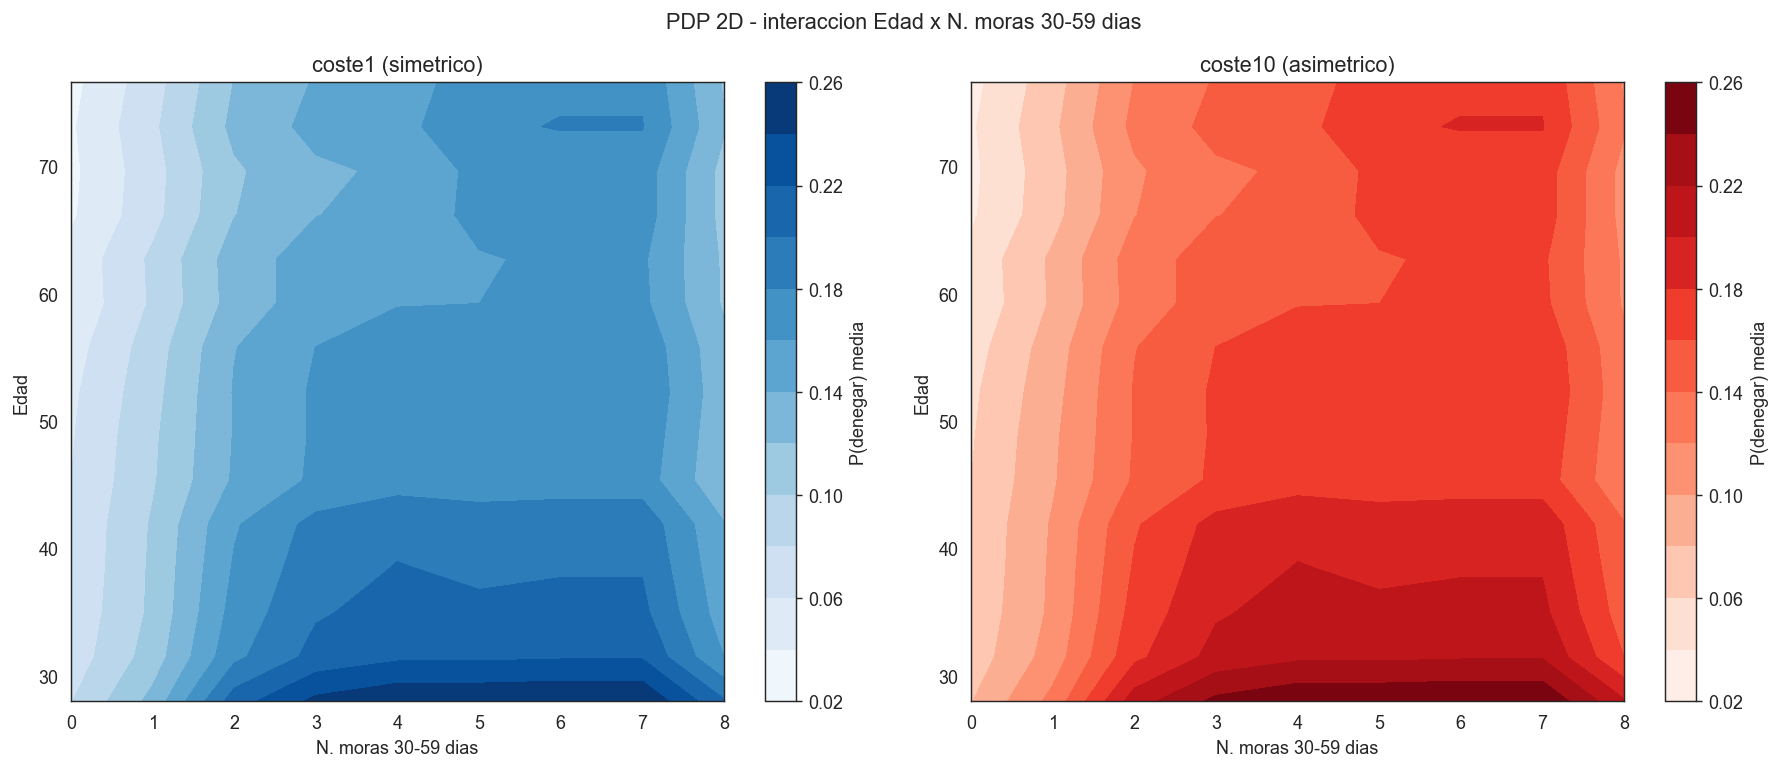

In [64]:
fig("otras_08_pdp2d_interaccion.png", w=720)

**Que mirar:** el gradiente de color a lo largo del eje edad, comparando la fila
sin moras con la fila de 8 moras (maximo del grid). El rango de `P(denegar)` explicado solo por la
edad es 0.0448 sin historial de mora frente a 0.0888 con 8 moras -- practicamente el doble (~2x) --
confirmando, con un metodo agnostico independiente del arbol subrogado, la interaccion Edad x mora
que la seccion 8 ya mostraba dentro de las reglas del subrogado. Matiz importante: la superficie de
probabilidad es IDENTICA entre los dos escenarios de coste (es el mismo XGBoost); lo unico que
cambia entre coste1 y coste10 es DONDE corta cada umbral esa misma geometria. Esto refina, no
contradice, el relato de "dos personalidades de riesgo": la personalidad distinta esta en el
umbral, no en el modelo.

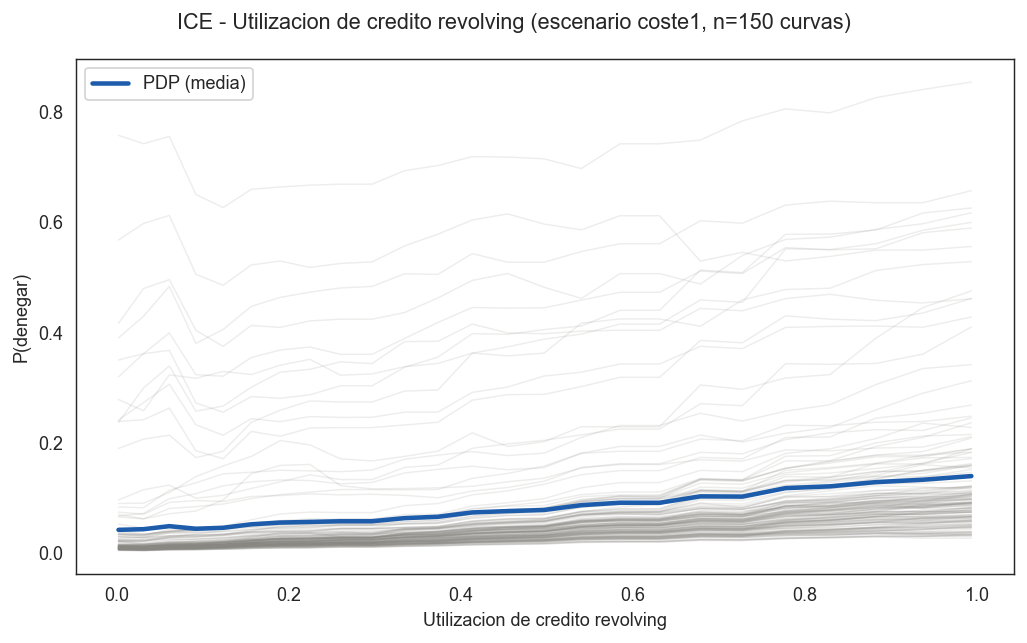

In [65]:
fig("otras_08_ice_revolving.png", w=720)

**Que mirar:** cada linea fina es un cliente (curva ICE, prediccion individual al
variar solo `Utilizacion de credito revolving`), la linea gruesa es el promedio (el PDP). La
mayoria de curvas sube de forma monotona con la utilizacion, pero el punto en el que empiezan a
subir difiere bastante entre clientes -- la variable que domina la importancia en las decisiones
del escenario asimetrico (ver panel anterior) no actua igual para todos los perfiles de riesgo.

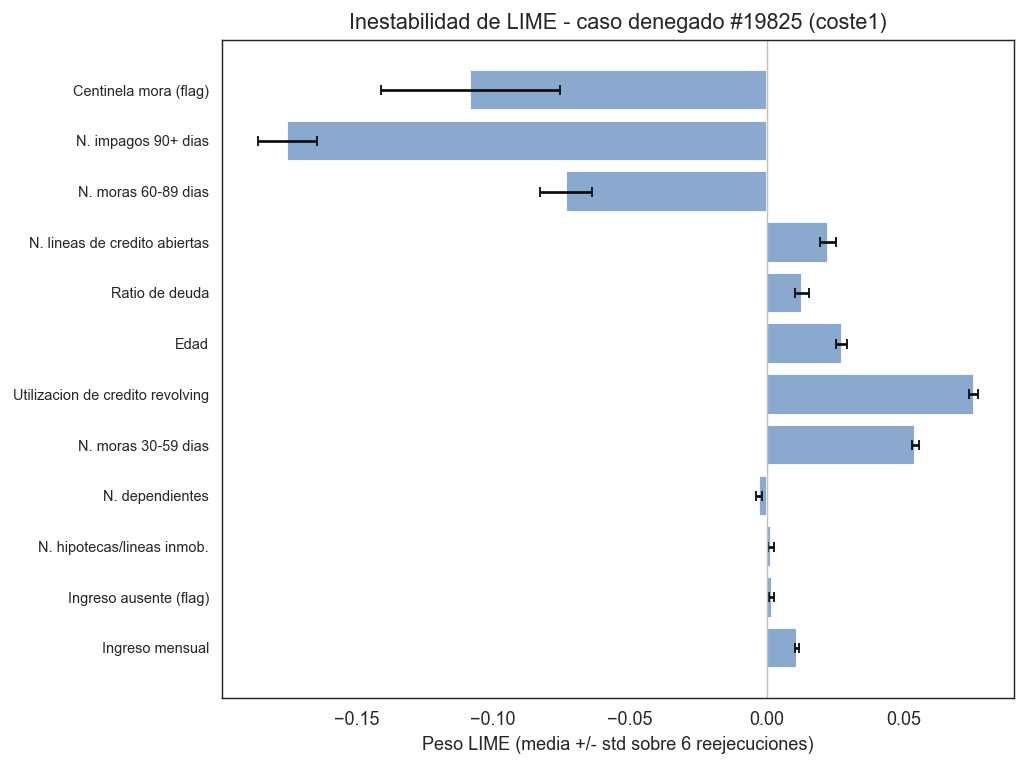

In [66]:
fig("otras_08_lime_inestabilidad.png", w=720)

**Que mirar:** la dispersion (barras de error) del peso que LIME asigna a cada
variable entre sus 6 reejecuciones sobre el mismo caso. `es_centinela_pastdue` (variable centinela
de historial de mora) tiene, con diferencia, la mayor dispersion: peso_std medio 0.0322 (maximo
0.0357), ~3x mas inestable que la siguiente variable en el ranking de inestabilidad,
`N. impagos 90+ dias` (std 0.0106). En 9 de las 72 combinaciones caso-variable evaluadas el peso
cambia de signo entre reejecuciones, siempre concentrado en variables de relleno del ranking
(Ingreso ausente, Ratio de deuda, N. hipotecas/lineas inmobiliarias) y nunca en las de mayor peso
(impagos, utilizacion), que mantienen el signo estable en todas las reejecuciones.

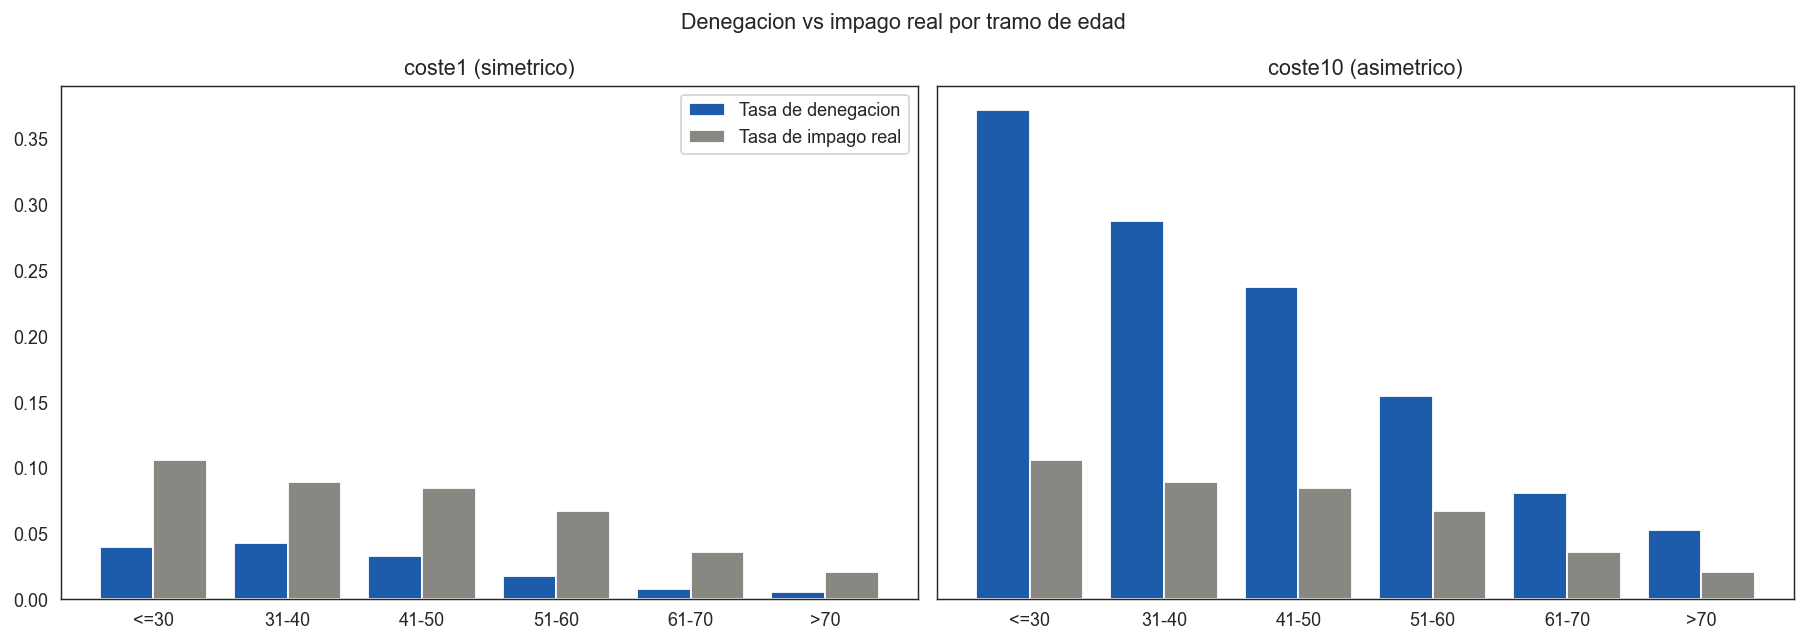

In [67]:
fig("otras_08_subgrupos_edad.png", w=720)

**Que mirar:** compara, tramo a tramo, la barra de tasa de denegacion con la
de tasa de impago real. Bajo coste asimetrico el ratio denegacion/impago-real es 3.52x en los
<=30 anios, decrece hasta un minimo de 2.27x en 61-70 anios y repunta a 2.49x en los mayores de
70 -- entre ~2.3x y ~2.5x en los tramos de mas edad, nunca tan bajo como el minimo sugiere a
primera vista. La denegacion sigue la DIRECCION del riesgo real (baja con la edad) pero no su
MAGNITUD, sobre todo en los jovenes.

In [68]:
# Subgrupos por tramo de edad: denegacion vs impago real, ambos escenarios
print("Subgrupos por tramo de edad (denegacion vs impago real)")
print(tabla("otras_08_subgrupos_edad.csv").round(4).to_string(index=False))

Subgrupos por tramo de edad (denegacion vs impago real)
escenario tramo_edad    n  tasa_denegacion  tasa_impago_real  fp_rate  fn_rate  coste_medio
   coste1       <=30 1562           0.0397            0.1056   0.0193   0.7879       0.1005
   coste1      31-40 3431           0.0426            0.0895   0.0221   0.7492       0.0871
   coste1      41-50 4951           0.0329            0.0844   0.0141   0.7632       0.0774
   coste1      51-60 4896           0.0178            0.0674   0.0077   0.8424       0.0639
   coste1      61-70 3734           0.0075            0.0356   0.0036   0.8872       0.0351
   coste1        >70 2426           0.0054            0.0210   0.0021   0.8431       0.0198
  coste10       <=30 1562           0.3720            0.1056   0.3157   0.1515       0.4424
  coste10      31-40 3431           0.2874            0.0895   0.2398   0.2280       0.4223
  coste10      41-50 4951           0.2371            0.0844   0.1902   0.2536       0.3882
  coste10      51-60 489

**Hallazgos:**

1 **Importancia a 3 bandas, ninguna cuenta toda la historia.** En coste1 (simetrico, escenario casi
  trivial) la permutacion escalada al coste de negocio da valores casi planos (0.0000-0.0022) porque
  romper cualquier variable apenas mueve un coste esperado que ya es minimo, aunque la jerarquia
  interna de variables siga intacta; XGBoost nativo y el subrogado SI coinciden con claridad en que
  `N. impagos 90+ dias` domina (0.3301 nativo, 0.7155 subrogado). En coste10 (asimetrico), permutacion
  y subrogado coinciden en `Utilizacion de credito revolving` como la variable que mas pesa en las
  DECISIONES (0.0782 permutacion, 0.4914 subrogado), pero XGBoost nativo sigue senalando
  `N. impagos 90+ dias` (0.3301, sin cambios respecto a coste1) porque su importancia mide ganancia
  de impureza sobre todas las predicciones del arbol, no esta condicionada al umbral vigente: una
  cosa es que discrimina mejor globalmente, otra que pesa mas en la decision actual.

2 **El PDP 2D confirma, con un metodo agnostico independiente del subrogado, que el efecto de la
  edad sobre `P(denegar)` es ~2x mayor con historial de mora** (rango 0.0448 sin moras vs 0.0888 con
  8 moras). Matiz que enriquece el relato de la seccion 8: la superficie de probabilidad del PDP es
  IDENTICA entre ambos escenarios de coste (mismo estimador XGBoost); lo unico que cambia es donde
  corta cada umbral esa misma geometria -- la "personalidad" distinta esta en el umbral, no en el
  modelo.

3 **LIME reejecutado 6 veces sobre el mismo caso produce pesos distintos.** `es_centinela_pastdue`
  es, con diferencia, la variable mas inestable (peso_std medio 0.0322, maximo 0.0357, ~3x la
  siguiente mas inestable, `N. impagos 90+ dias` con std 0.0106); en 9 de 72 combinaciones
  caso-variable el peso cambia de signo entre ejecuciones, siempre en variables de relleno del
  ranking (Ingreso ausente, Ratio de deuda, N. hipotecas/lineas inmobiliarias), nunca en las de mayor
  peso. Confirma empiricamente la advertencia del profesor sobre LIME y justifica preferir SHAP
  (determinista via TreeExplainer, sin varianza entre ejecuciones) como metodo principal de auditoria
  local (seccion 10).

4 **Los subgrupos por tramo de edad siguen la DIRECCION del riesgo real pero no su MAGNITUD.** Bajo
  coste asimetrico el ratio denegacion/impago-real es 3.52x en <=30 anios, decrece hasta 2.27x en
  61-70 y repunta a 2.49x en >70 (entre ~2.3x y ~2.5x en los tramos de mas edad). Bajo coste
  simetrico el mismo patron es mucho mas debil y no monotono (ratios entre 0.21x y 0.48x), coherente
  con que ese escenario es casi trivial y su senal de subgrupo es mas ruidosa.

5 **Lectura honesta (no sobrevender el hallazgo de subgrupos):** el patron NO demuestra
  discriminacion causal -- la edad puede actuar como proxy de variables no observadas (antiguedad
  crediticia, estabilidad laboral) que el dataset no recoge -- y es precisamente mas fuerte en el
  escenario donde el modelo si aporta valor real de negocio (coste10). Es una mini-auditoria de sesgo
  descriptiva, no un analisis de fairness formal: el dataset no tiene un atributo protegido explicito
  (la edad es el proxy mas cercano) y no se calculan metricas estandar de equidad (equalized odds y
  similares). Limitaciones a tener en cuenta al leer las 4 tecnicas: PDP/ICE y permutacion se
  calculan sobre muestras de 2000-3000 filas, el PDP 2D usa una rejilla de 15x15 puntos, y LIME solo
  se reejecuta sobre 3 casos por escenario.

## 12. Decisiones de diseno

Cada decision tecnica relevante del proyecto se documento con las alternativas comparadas y la evidencia numerica que las decidio. Este apartado resume las 15 decisiones cerradas mas importantes, agrupadas por bloque: paradigma de modelado, arquitectura de umbrales, familia de modelo, preprocesado (imputacion, outliers, duplicados), validacion anti-fuga, coste del escenario 2, complejidad del arbol subrogado y auditoria XAI (contrafactuales, SHAP local, tecnicas del notebook 08). Cada fila de la tabla se entiende por si sola, con el numero de evidencia al lado; el ID es solo una referencia secundaria.

| ID | Decision | Eleccion final |
|---|---|---|
| D-0.1 | Supervisado vs Multiarmed Bandit | Supervisado XGBoost (coste_test asimetrico 0.3275 vs LinUCB CV ~0.359) |
| D-0.2 | 1 modelo+2 umbrales vs 2 modelos por escenario | 1 modelo XGBoost, 2 umbrales (OOF identicas byte a byte, max\|dif\|=0) |
| D-0.3 | Familia de modelo (lineal / red / arboles / bandit) | XGBoost gana en ambos escenarios (gap vs logit 0.033 en asimetrico, 0.0006 en simetrico) |
| D-1.1 | Imputacion de nulos (MonthlyIncome, NumberOfDependents) | Mediana por tramo de edad + flag MNAR (income); 0 sin flag (dependents) |
| D-1.2 | Outliers y cola de DebtRatio | Recalcular con income imputado, no winsorizar a ciegas (KS cola vs sana baja de 0.9284 a 0.1671; detalle del numerador corrupto abajo) |
| D-1.4 | Division train/test | Split 80/20 estratificado (84000/21000) ANTES de aprender parametros (evita fuga) |
| D-1.6 | Filas duplicadas | Se conservan (331 train, 101 produccion); sin ID no se puede probar que sean error |
| D-2.1 | Protocolo de validacion (umbral y familia) | CV 5 folds sobre OOF; test reservado solo para el reporte final |
| D-3.1 | Umbral analitico vs empirico | Empirico: 0.4934 (simetrico, analitico 0.5) / 0.0906 (asimetrico, analitico 1/11=0.0909) |
| D-3.2 | Coste del escenario 2 | Asimetrico C_FN=10*C_FP (errata confirmada por el profesor); 7279 cambios de decision en produccion |
| D-5.1 | Complejidad del arbol subrogado | max_depth=5 (auditoria, 23 hojas) y max_depth=3 (bolsillo, 8 hojas) |
| D-6.1 | Herramienta de contrafactuales | DiCE (metodo random) con adaptador al umbral de negocio real |
| D-6.2 | Numero de casos contrafactuales | 8 casos (2 por clase real x 2 escenarios); 2 CF plausibles en coste1, 1 en coste10 |
| D-7.1 | Instancias y explainer para SHAP local | Mismos 8 casos de la fila anterior; TreeExplainer |
| D-8.1 | Tecnicas XAI adicionales (notebook 08) | Permutacion + PDP/ICE + LIME + subgrupos por tramo de edad |

### Hallazgo central del preprocesado: el numerador corrupto de DebtRatio

La variable DebtRatio (deuda mensual entre ingreso mensual) tenia una cola anomala por encima del percentil 97.5. En el 100% de esas filas el ingreso (income) no era utilizable (missing o degenerado), asi que la formula del ratio se quedaba con el numerador crudo (deuda total en unidades absolutas) en vez de dividir por un ingreso valido. Recalcular DebtRatio despues de imputar el ingreso, en vez de winsorizar la cola a ciegas, es la aportacion analitica principal del preprocesado.

| Metrica | Antes de recalcular | Despues de recalcular |
|---|---|---|
| Mediana del valor en la cola (DebtRatio>p97.5) | 1152 (numerador crudo, no un ratio) | 0.29 (ratio normal, igual que filas sanas) |
| KS entre la cola y la distribucion sana | 0.9284 | 0.1671 |
| AUC univariante DebtRatio -> target | 0.5212 | 0.5531 |

### Colapso de la multicolinealidad al tratar los centinelas 96/98 como ausentes

Las tres columnas de dias de retraso en el pago (PastDue 30-59, 60-89 y 90+) usaban los codigos 96 y 98 como valores centinela, no como conteos reales. Tratarlos como missing en vez de como numeros literales colapsa la multicolinealidad entre las tres variables.

| Columna | VIF antes (centinela como numero) | VIF despues (centinela como missing) |
|---|---|---|
| PastDue 30-59 | 40.9 | ~1.18 |
| PastDue 60-89 | 71.7 | ~1.15 |
| PastDue 90+ | 89.6 | ~1.17 |

VIF maximo del conjunto completo de variables tras el cambio: 1.91 (todas por debajo del umbral de alerta habitual de 5).

**Hallazgos:**

- El ganador (XGBoost) lo es por capacidad de modelo, no por paradigma: a igual familia lineal el bandit LinUCB iguala/bate ligeramente a la regresion logistica (coste CV asimetrico ~0.359 vs ~0.351), pero XGBoost bate a ambas con coste_test 0.3275 asimetrico / 0.0634 simetrico.
- Un unico modelo con dos umbrales basta para los dos escenarios: el mismo XGBoost se reutiliza sin reentrenar (probabilidades OOF identicas byte a byte, diferencia maxima = 0), solo cambia el umbral de decision de 0.4934 (simetrico) a 0.0906 (asimetrico). El modelo que gana por familia tampoco cambia bajo la asimetria, asi que ese mismo XGBoost sirve tambien como modelo unico de produccion en los dos escenarios.
- El escenario 2 es asimetrico (coste de falso negativo = 10 veces el de falso positivo, errata del enunciado confirmada por el profesor) y el impacto es material: 7279 solicitantes del split de produccion cambian de decision respecto a asumir coste simetrico.
- El recalculo de DebtRatio es la aportacion analitica central del preprocesado (ver tabla arriba): el 100% de la cola anomala correspondia a ingreso no utilizable, la mediana del numerador crudo era 1152 frente a 0.29 en filas sanas, el KS baja de 0.9284 a 0.1671 y el AUC univariante mejora de 0.5212 a 0.5531.
- Tratar los centinelas 96/98 de las columnas de retraso de pago como ausentes colapsa la multicolinealidad: el VIF de las tres columnas cae de 40.9/71.7/89.6 a ~1.18/1.15/1.17 (maximo global 1.91).
- El arbol subrogado revela dos personalidades de riesgo segun el escenario: el F1 de la clase denegar sube de 0.756 (simetrico) a 0.844 (asimetrico); SHAP en cambio es identico entre escenarios porque comparten el mismo XGBoost, solo cambia el umbral que traduce score en decision.
- Las tecnicas XAI adicionales del notebook 08 usan distintas cantidades de filas por coste computacional: 2000 filas para PDP/ICE, 3000 filas con 10 repeticiones para importancia por permutacion y 6 reejecuciones por caso para medir inestabilidad de LIME.

## 13. Reflexion final

El mismo XGBoost, sin reentrenar y con las mismas predicciones OOF byte a byte, cambia de politica de riesgo -no de modelo- al mover el umbral de decision de 0.4934 a 0.0906. El AUC de test es identico en los dos escenarios (0.870109), la confirmacion cuantitativa de que se trata del mismo estimador re-umbralizado y no de un modelo distinto. Esa opacidad extra frente a un modelo lineal solo se justifica cuando el coste de negocio es asimetrico: el gap de rendimiento frente a una regresion logistica crece unas 27 veces (de 0.000631 a 0.016988). La auditoria multi-tecnica (subrogado, DiCE, SHAP/LIME, subgrupos) muestra ademas que tanto la fiabilidad de la explicacion como lo que se le puede decir a un cliente denegado dependen del par umbral-tecnica usado, no solo de la precision del modelo. Esta seccion no ejecuta analisis nuevo: relee criticamente los notebooks 02 a 12 y reorganiza sus hallazgos numericos alrededor de las 4 preguntas del enunciado.

**1. Cambio de comportamiento optimo**

- Umbral optimo: 0.4934 (simetrico) -> 0.0906 (asimetrico); ambos casi identicos a sus umbrales analiticos (0.5 y 1/11=0.0909) -- senal de buena calibracion del modelo.
- Denegacion en test: 2.38% -> 18.70%; en produccion: 2.36% -> 18.53% (x7.9). Coste medio en test: 0.0634 -> 0.3275.
- Mejora vs 'conceder a todos': 5.20% -> 51.01%. El PDP en 2D (superficie de probabilidad conjunta de dos variables, ver seccion 11) es identico en ambos escenarios porque es el mismo estimador; solo cambia por donde corta cada umbral esa misma geometria.
- 7279 solicitantes pasan de concedido a denegado en produccion entre escenario 1 y 2; 0 solicitantes se mueven en sentido inverso -- el desplazamiento del umbral es estrictamente mas restrictivo, nunca libera credito que antes se denegaba.

**2. Trade-off rendimiento vs explicabilidad**

- Escenario simetrico: XGBoost apenas mejora a un modelo lineal (gap de validacion cruzada logistica-XGBoost de solo 0.000631) y la mejora frente a conceder-todo es marginal (5.20%) -- el propio notebook de modelado describe este escenario como 'casi degenerado', con una curva de coste muy plana alrededor del optimo.
- Escenario asimetrico: el gap crece a 0.016988 (~27x mayor) y la mejora sube a 51.01% -- aqui el modelo aporta valor real de negocio y es donde pagar el coste de opacidad de XGBoost frente a un modelo lineal se justifica.
- Esa opacidad se audita con 4 tecnicas independientes (arbol subrogado, contrafactuales DiCE, SHAP/LIME, subgrupos por edad); ninguna es suficiente por si sola, cada una cubre una pregunta distinta (aproximacion global, accionabilidad individual, atribucion local, equidad).

**3. Lecciones de la auditoria: fiabilidad y calidad de explicacion**

- El arbol subrogado tiene 'dos personalidades': en el escenario simetrico domina el numero de impagos a 90+ dias con importancia 0.7155; en el asimetrico domina la utilizacion de revolving con 0.4914 -- el arbol mira variables distintas segun el umbral.
- Fidelidad del subrogado en la clase 'denegar': el arbol degenerado (una unica regla trivial) tiene fid_denegar=0% en LOS DOS escenarios, es decir, no sirve como explicacion en ninguno de los dos. El arbol operativo (con profundidad real) sube esa fidelidad a 78.96% (F1=0.7562) en el escenario simetrico y a 84.54% (F1=0.8439) en el asimetrico -- mejor precisamente en el escenario donde mas importa, porque es donde el modelo aporta valor.
- DiCE solo genera contrafactuales en 4 de 8 casos analizados (0 de 4 en denegaciones fuertes) y solo 3 de esos 8 son plausibles -- poco accionable justo donde mas se necesitaria explicar al cliente por que se le deniega.
- Distincion clave para lo que se le dice al cliente (ver seccion 9): si el caso denegado es en realidad un falso positivo (no habria impagado), el contrafactual de DiCE es una explicacion literal y accionable ('si su variable X hubiera sido Y, se le habria concedido'). Si el caso denegado es un acierto del modelo (clase real impago), el contrafactual -cuando existe- tiene valor de auditoria interna del comportamiento del modelo, pero no deberia comunicarse al cliente como garantia de que cambiar esa variable le aprobaria el credito.
- SHAP es determinista (desviacion estandar 0 entre reejecuciones) y sirve de referencia; LIME es inestable (desviacion estandar media 0.0056, maxima 0.0357) y cambia de signo en algunas combinaciones caso-variable, siempre en las variables de menor peso -- las variables dominantes (impagos, utilizacion) mantienen signo estable en ambas tecnicas. El ranking de importancia coincide solo con Spearman ~0.49 entre SHAP y LIME, y el top-1 coincide en apenas 2 de 6 casos.
- Sesgo por edad bajo el escenario asimetrico: los solicitantes de 30 anios o menos son denegados a una tasa 3.52 veces su tasa real de impago, frente a 2.27x-2.49x en los grupos de mayor edad. Esto no prueba discriminacion causal: la edad puede actuar de variable proxy de factores no observados (antiguedad crediticia, estabilidad laboral), advertencia que hace explicita el propio notebook de auditoria y que conviene no perder al leer esta cifra.

**4. Limitaciones y lineas de mejora**

- El coste en produccion no se puede verificar (las etiquetas reales de impago no estan disponibles); solo la tasa de denegacion es medible directamente, y ya muestra el mismo salto que en test (2.36% -> 18.53%).
- La recalibracion del DebtRatio (variable de endeudamiento, ver seccion 3) introduce un acoplamiento debil pero real con la edad: la correlacion de Spearman pasa de +0.0289 a -0.0981 tras la recalibracion (Pearson -0.0059, practicamente nulo) -- declarado explicitamente como un 'coste honesto' de la transformacion en el propio preprocesado.
- Esa recalibracion se verifico por separado como libre de fuga de informacion entre train y test: la media de la variable escalada es ~6.83e-16 en train (por construccion del escalador), 0.021086 en test y 0.014083 en produccion, una diferencia de ~14 ordenes de magnitud que confirma que el escalador se ajusto solo con datos de entrenamiento. Es una verificacion INDEPENDIENTE del acoplamiento con la edad del punto anterior, no la misma evidencia repetida dos veces.
- Limitacion de ingenieria detectada al reproducir resultados: cargar el modelo guardado (.joblib) con una version de XGBoost distinta a la usada en el entrenamiento reconstruye mal un parametro interno (base_score) e infla las probabilidades predichas por un factor ~5 (la denegacion pasaria de 2.4%/18.7% a cifras cercanas a 25%/85%); se corrigio fijando la version exacta de la libreria en el fichero de dependencias del proyecto.
- Proximos pasos: monitorizar el umbral 0.0906 cuando lleguen etiquetas reales de produccion; ampliar la auditoria de subgrupos a otros atributos protegidos ademas de la edad; relajar las restricciones de accionabilidad de DiCE para que tambien proponga alternativas en denegaciones fuertes; y sustituir o estabilizar LIME dada su inestabilidad frente a SHAP.